In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
%config InlineBackend.figure_format = 'retina'

In [32]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
from kspecdr.inst.isoplane import (
    convert_isoplane_header,
    add_fiber_table,
    write_isoplane_converted_image,
)
from kspecdr.io.image import ImageFile
from kspecdr.preproc.make_im import make_im
from kspecdr.preproc.preproc import reduce_bias, reduce_dark, combine_image
from kspecdr.tlm.make_tlm import read_instrument_data, make_tlm
from kspecdr.extract.make_ex import make_ex
from kspecdr.extract.reduce_arc import reduce_arcs, reduce_arc
from kspecdr.reduce_fflat import reduce_fflat
from scipy.signal import find_peaks_cwt, find_peaks
from matplotlib.lines import Line2D
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

WD = Path.home() / "Research/kspec/kspecdr"
RESOURCES = WD / "resources"
TESTDIR = RESOURCES / "comm" / "20260125"
CALDIR = TESTDIR / "calib"
CALCONVDIR = CALDIR / "converted"
CONVDIR = TESTDIR / "converted"
PROCDIR = TESTDIR / "processed"
ASSIGNDIR = RESOURCES / "comm" / "assign"

CALCONVDIR.mkdir(exist_ok=True)
CONVDIR.mkdir(exist_ok=True)
PROCDIR.mkdir(exist_ok=True)

mdark_path = RESOURCES / "comm" / "20260130" / "calib" / "mdark_2400s.fits"
# mdark_path = RESOURCES / "comm" / "20260205" / "calib" / "mdark_cut.fits"

In [33]:
logging.getLogger("kspecdr").setLevel(logging.WARNING)
bias_files = list(CALDIR.glob("Bias*.fits"))
bias_files_converted = [CALCONVDIR / f.name.replace("Bias", "cBias") for f in bias_files]

for bfpath, bfpath_converted in zip(bias_files, bias_files_converted):
    write_isoplane_converted_image(bfpath, bfpath_converted, "BIAS", n_fibers=14)

mbias_path = CALDIR / "mbias.fits"
mbias_file = reduce_bias(bias_files_converted, output_file=mbias_path.as_posix())

In [34]:
flat_files = list(CALDIR.glob("Flat*.fits"))
flat_files_converted = [CALCONVDIR / f.name.replace("Flat", "cFlat") for f in flat_files]

for fpath, fpath_converted in zip(flat_files, flat_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFFLAT", n_fibers=14)

for fpath in flat_files_converted:
    make_im(
        fpath.as_posix(),
        cosmic_ray_method="LACOSMIC",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
        use_dark=True,
        dark_filename=mdark_path.as_posix(),
    )

In [35]:
spec_sets = []
for fpath in flat_files_converted:
    im_path = CALCONVDIR / (fpath.stem + "_im.fits")
    spec_set = fpath.stem[6:13]
    spec_sets.append(spec_set)

    fpath_tlm = CALDIR / ("tlm_" + spec_set + ".fits")
    fpath_ex = CALCONVDIR / (fpath.stem + "_ex.fits")
    args = {
        "IMAGE_FILENAME": im_path.as_posix(),
        "TLMAP_FILENAME": fpath_tlm.as_posix(),
        "EXTRAC_FILENAME": fpath_ex.as_posix(),
    }

    make_tlm(args)
    
    make_ex(args)

Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1701.19pixel/s]


In [36]:
arc_files = list(CALDIR.glob("Arc*.fits"))
arc_files_converted = [CALCONVDIR / f.name.replace("Arc", "cArc") for f in arc_files]

for fpath, fpath_converted in zip(arc_files, arc_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFARC", n_fibers=14)

    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="LACOSMIC",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
        use_dark=True,
        dark_filename=mdark_path.as_posix(),
    )

    # hardcoded for now - no 600_680 flat frame
    spec_set = fpath.stem[4:11]
    if spec_set in ["600_430", "600_680"]:
        spec_set = "300_490"

    fpath_im = CALCONVDIR / (fpath_converted.stem + "_im.fits")
    fpath_ex = CALCONVDIR / (fpath_converted.stem + "_ex.fits")
    tlm_path = CALDIR / ("tlm_" + spec_set + ".fits")
    make_ex(
        {
            "IMAGE_FILENAME": fpath_im.as_posix(),
            "EXTRAC_FILENAME": fpath_ex.as_posix(),
            "TLMAP_FILENAME": tlm_path.as_posix(),
        }
    )

Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1789.49pixel/s]
2026-03-10 23:13:21,441 | kspecdr.extract.make_ex | WARNING | TLM header mismatch with IM header; recomputing WAVELA from IM.
Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1848.73pixel/s]
2026-03-10 23:13:22,687 | kspecdr.extract.make_ex | WARNING | TLM header mismatch with IM header; recomputing WAVELA from IM.
Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1852.62pixel/s]
2026-03-10 23:13:25,187 | kspecdr.extract.make_ex | WARNING | TLM header mismatch with IM header; recomputing WAVELA from IM.
Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1853.52pixel/s]
2026-03-10 23:13:26,405 | kspecdr.extract.make_ex | WARNING | TLM header mismatch with IM header; recomputing WAVELA from IM.
Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1475.76pixel/s]


In [37]:
fpath_converted

PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_600_680_120s 2026 January 25.fits')

(14, 1340)
Filename: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/tlm_300_490.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (1340, 14)   float64   
  1  WAVELA        1 ImageHDU         8   (1340, 14)   float64   


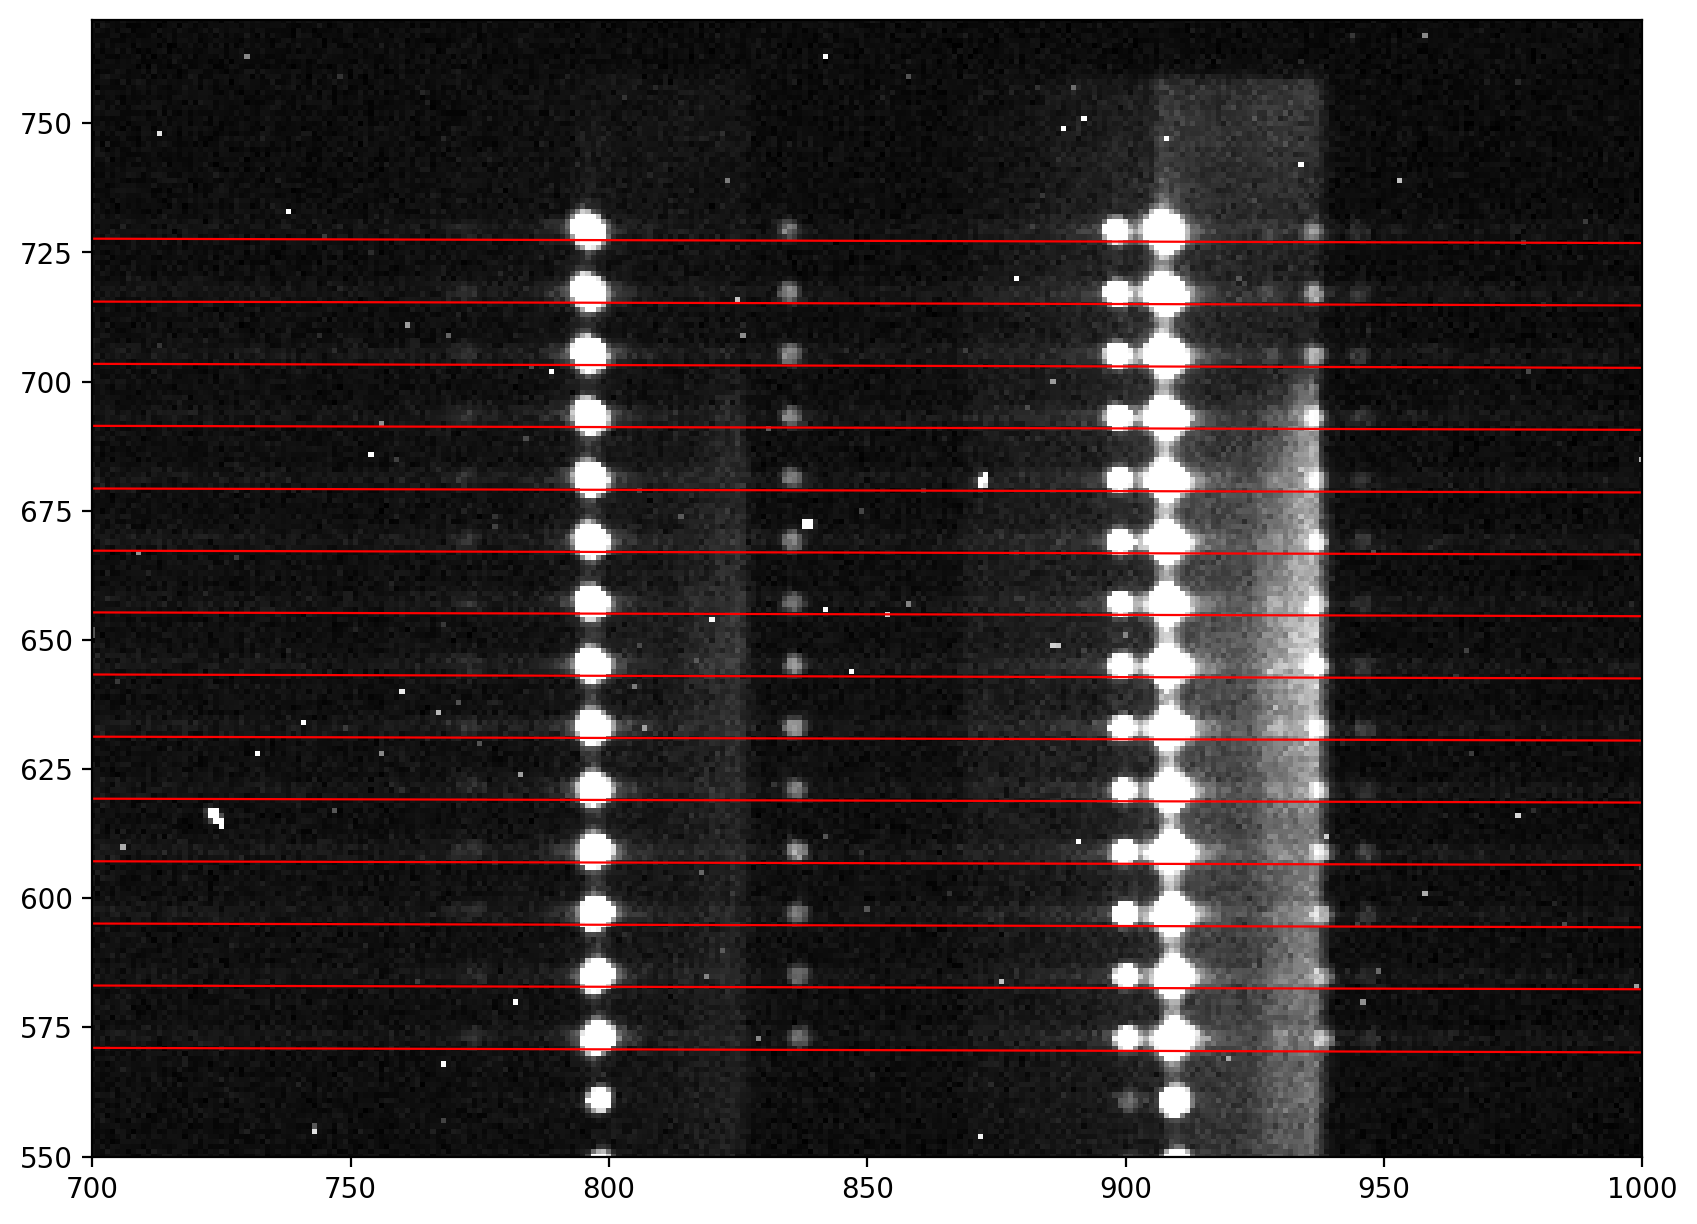

In [38]:
fpath_tlm = CALDIR / ("tlm_300_490.fits")
# img_path = CALCONVDIR / "cArc_300_490_240s 2026 January 25.fits"
img_path = CALCONVDIR / "cArc_600_680_300s 2026 January 25.fits"

hdul = fits.open(fpath_tlm)
tlm_data = hdul[0].data
print(tlm_data.shape)
hdul.info()

img_data = fits.getdata(img_path)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
vmin, vmax = np.nanpercentile(img_data, [1, 99])
ax.imshow(img_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
for tl in tlm_data:
    ax.plot(np.arange(tl.shape[0]), tl, c="r", lw=0.8)

ax.set_ylim(550, 770)
ax.set_xlim(700, 1000)
# ax.set_ylim(1000, 1200)

tlm_data_flat = tlm_data.copy()

In [39]:
logging.getLogger("kspecdr").setLevel(logging.INFO)
rwpath_150620 = CALCONVDIR / "cArc_150_620_240s 2026 January 25.fits"
impath_150620 = CALCONVDIR / (rwpath_150620.stem + "_im.fits")
expath_150620 = CALCONVDIR / (rwpath_150620.stem + "_ex.fits")
rdpath_150620 = CALCONVDIR / (rwpath_150620.stem + "_red.fits")

tlm_150 = CALDIR / "tlm_150_620.fits"

args_150620 = {
    "RAW_FILENAME": rwpath_150620.as_posix(),
    "IMAGE_FILENAME": impath_150620.as_posix(),
    "TLMAP_FILENAME": tlm_150.as_posix(),
    "EXTRAC_FILENAME": expath_150620.as_posix(),
    "OUTPUT_FILENAME": rdpath_150620.as_posix(),
    "USE_GENCAL": True,
    "ARCDIR": WD / "data" / "arc_tables",
    "LAMPNAME": "HgArNeKrCd",
    "USE_BLENDS": True,
    }


reduce_arc(args_150620, get_diagnostic=True, diagnostic_dir=CALDIR / "diagnostic")

2026-03-10 23:13:27,942 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits (mode: UPDATE)
2026-03-10 23:13:27,943 | kspecdr.extract.reduce_arc | INFO | Using Generic/TAIPAN Calibration Method
2026-03-10 23:13:27,947 | kspecdr.wavecal.arc_io | INFO | Reading arc file /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-03-10 23:13:27,954 | kspecdr.wavecal.arc_io | INFO | Read 90 arc lines from /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-03-10 23:13:27,956 | kspecdr.wavecal.calibrate | INFO | Reference fibre: 7
2026-03-10 23:13:27,957 | kspecdr.wavecal.calibrate | INFO | Unique lines: 84
2026-03-10 23:13:27,960 | kspecdr.wavecal.calibrate | INFO | use_blends=True: blend masking skipped; all 84 lines passed to cross-correlation and peak fitting.
2026-03-10 23:13:27,962 | kspecdr.wavecal.calibrate | INFO | Sigma: 1.43 pix. Noise: Mean=3

In [40]:
diagnostic_dir = CALDIR / "diagnostic"

wavecalid = Table.read(diagnostic_dir / "identified_arcs.dat", format="ascii.fixed_width_two_line")
# coeffs = wavecalid["coeffs"]
x_pts = wavecalid["x_pts"]
y_pts = wavecalid["y_pts"]
residuals = wavecalid["residuals"]
outliers = wavecalid["outliers"].data == "True"

wavecalcoeff = Table.read(diagnostic_dir / "global_fit_coefficients.dat", format="ascii.fixed_width_two_line")
coeffs = wavecalcoeff["coeffs"]

calispec = Table.read(diagnostic_dir / "CALIBRATED_SPECTRA.dat", format="ascii",
                     names=["wave", "flux"])
tempspec = Table.read(diagnostic_dir / "TEMPLATE_SPECTRA.dat", format="ascii.csv",
                     names=["wave", "flux"], delimiter=" ", data_start=0)

resoltab = Table.read(diagnostic_dir / "resolution_per_line.dat", format="ascii.fixed_width_two_line")

<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_78211/531871195.py:37: SyntaxWarning: invalid escape sequence '\A'
  ax.text(0.05, 0.95, f"RMS: {rms:.2f} $\AA$", transform=ax.transAxes, ha="left", va="top")
2026-03-10 23:13:31,891 | kspecdr.wavecal.arc_io | INFO | Reading arc file /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-03-10 23:13:31,892 | kspecdr.wavecal.arc_io | INFO | Read 90 arc lines from /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc


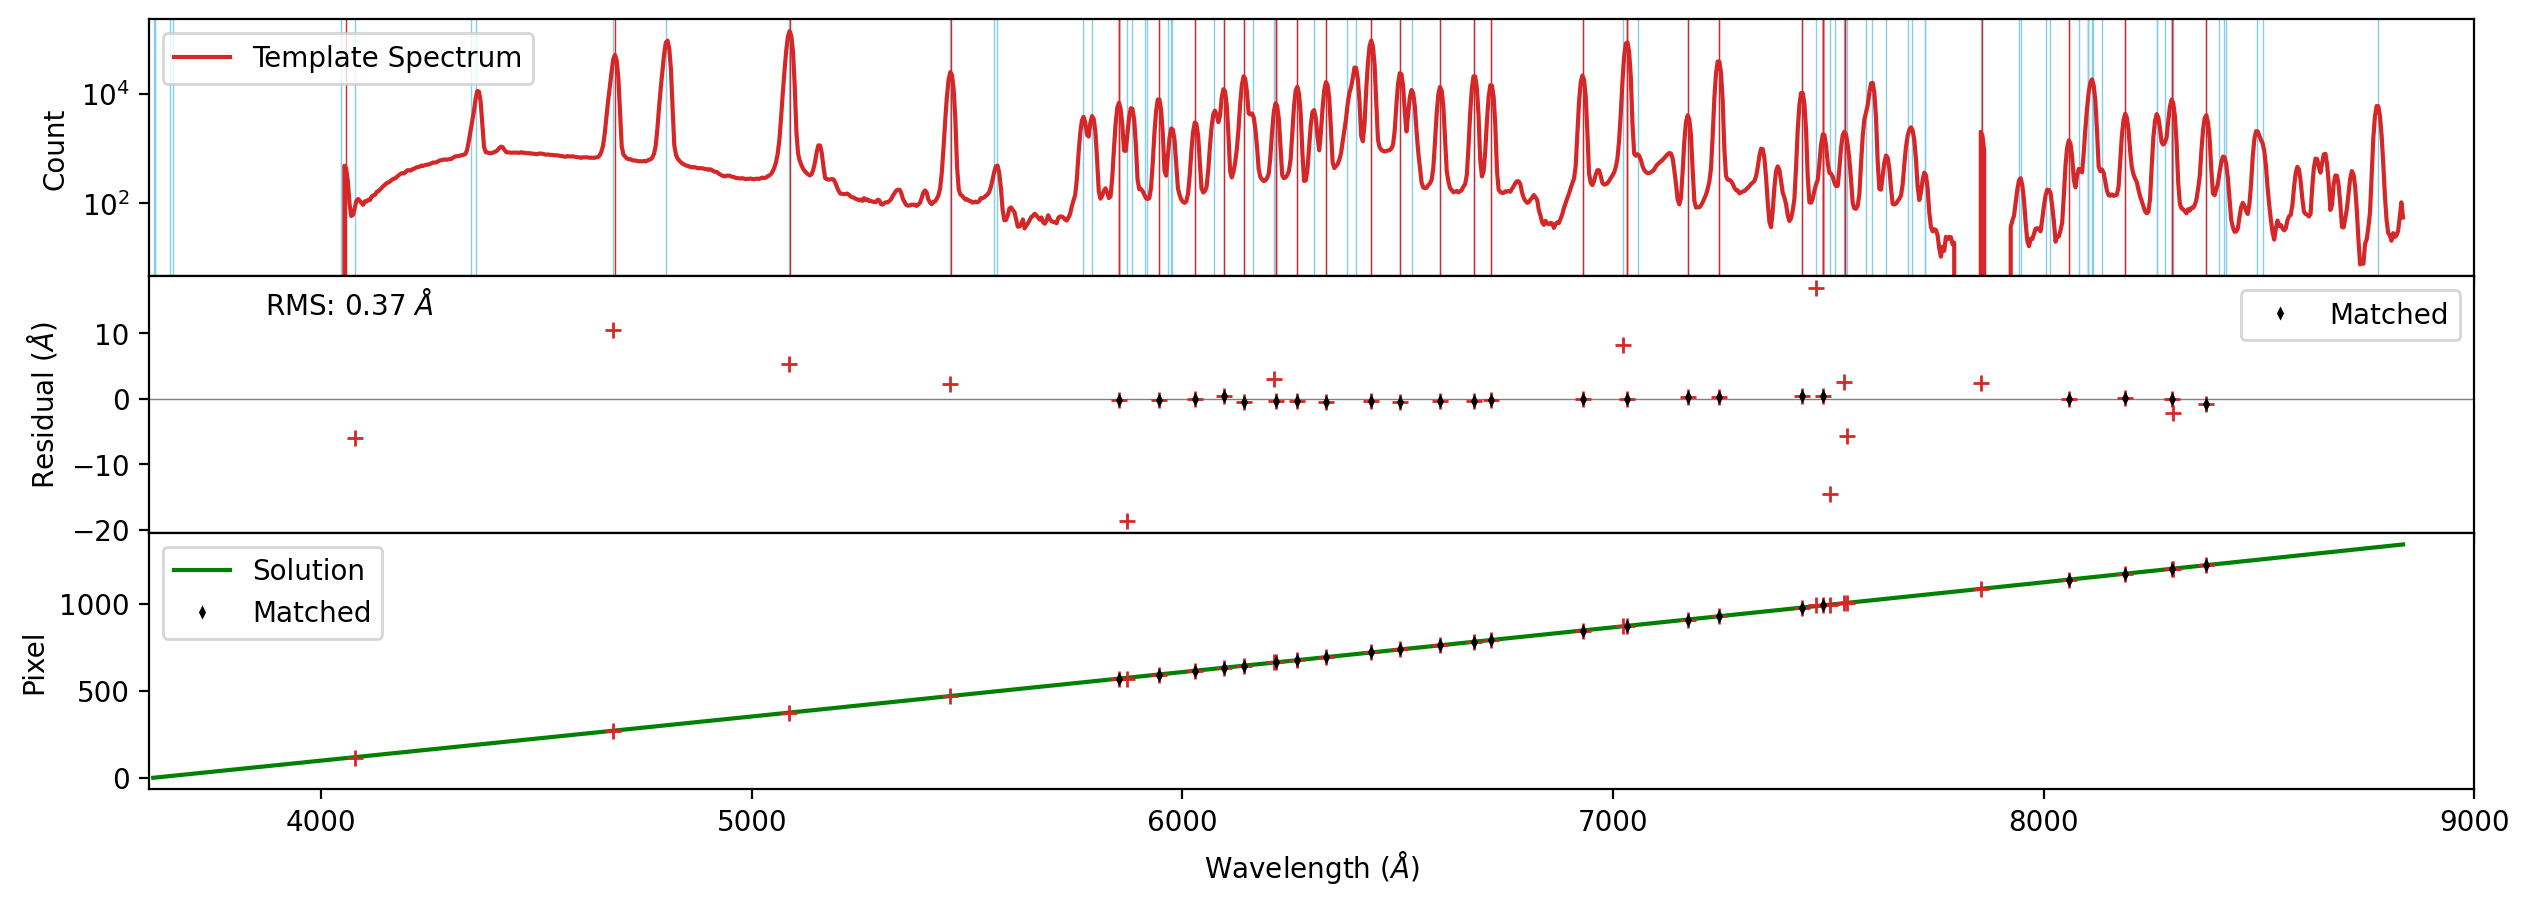

In [41]:
from kspecdr.wavecal.arc_io import read_arc_file

wavetemp = np.polyval(coeffs, np.arange(1340))

xlim = [3600, 9000]

fig, axes = plt.subplots(3, 1, figsize=(15, 5), sharex=True)
ax = axes[0]
# ax.plot(wave, hgarnekrcd_f8, label="Hg(Ar)NeKrCd FIB8", c="k")
# ax.plot(wavetemp, tempspec["flux"], label="Template Spectrum", c="tab:blue")
ax.plot(calispec["wave"], calispec["flux"], label="Template Spectrum", c="tab:red")

nx = 2
xvec = np.array(xlim)
wlist, ilist, labels, nlist = read_arc_file(nx, xvec, "HgArNeKrCd", arc_dir=WD/"data"/"arc_tables")
for i in range(len(wlist)):
    ax.axvline(wlist[i], color="skyblue", lw=0.5, zorder=0)

y_pts_inv = np.polyval(coeffs, x_pts)
for i in range(len(y_pts_inv)):
    ax.axvline(y_pts_inv[i], color="tab:red", lw=0.5, zorder=0)

ax.legend()
ax.set_yscale("log")
ax.set_xlim(xlim)
# ax.set_ylim(-1e4, 7e4)
ax.set_ylabel("Count")

ax = axes[1]
ax.plot(y_pts, residuals, c="tab:red", ls="", marker="+")

ax.plot(y_pts[~outliers], residuals[~outliers], c="k", ls="", marker="d", ms=2, label="Matched")
ax.legend()
ax.axhline(0, c="gray", lw=0.5, zorder=0)
ax.set_ylabel(r"Residual ($\AA$)")
rms = np.sqrt(np.mean(residuals[~outliers]**2))
ax.text(0.05, 0.95, f"RMS: {rms:.2f} $\AA$", transform=ax.transAxes, ha="left", va="top")

ax = axes[2]
xx = np.arange(1340)
yy = np.polyval(coeffs, xx)
ax.plot(yy, xx, label="Solution", c="green")

ax.plot(y_pts, x_pts, c="tab:red", ls="", marker="+")
ax.plot(y_pts[~outliers], x_pts[~outliers], c="k", ls="", marker="d", ms=2, label="Matched")
ax.legend()
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Pixel")
ax.set_xlim(xlim)

ax.legend()

# for ax in axes:
#     # minor ticks direction in
#     ax.minorticks_on()
#     ax.tick_params(which="both", direction="in")
#     ax.tick_params(which="major", length=6)
#     ax.tick_params(which="minor", length=3)

fig.subplots_adjust(hspace=0.0)


<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_78211/3888639995.py:7: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel("FWHM ($\AA$)")


Text(0, 0.5, 'R')

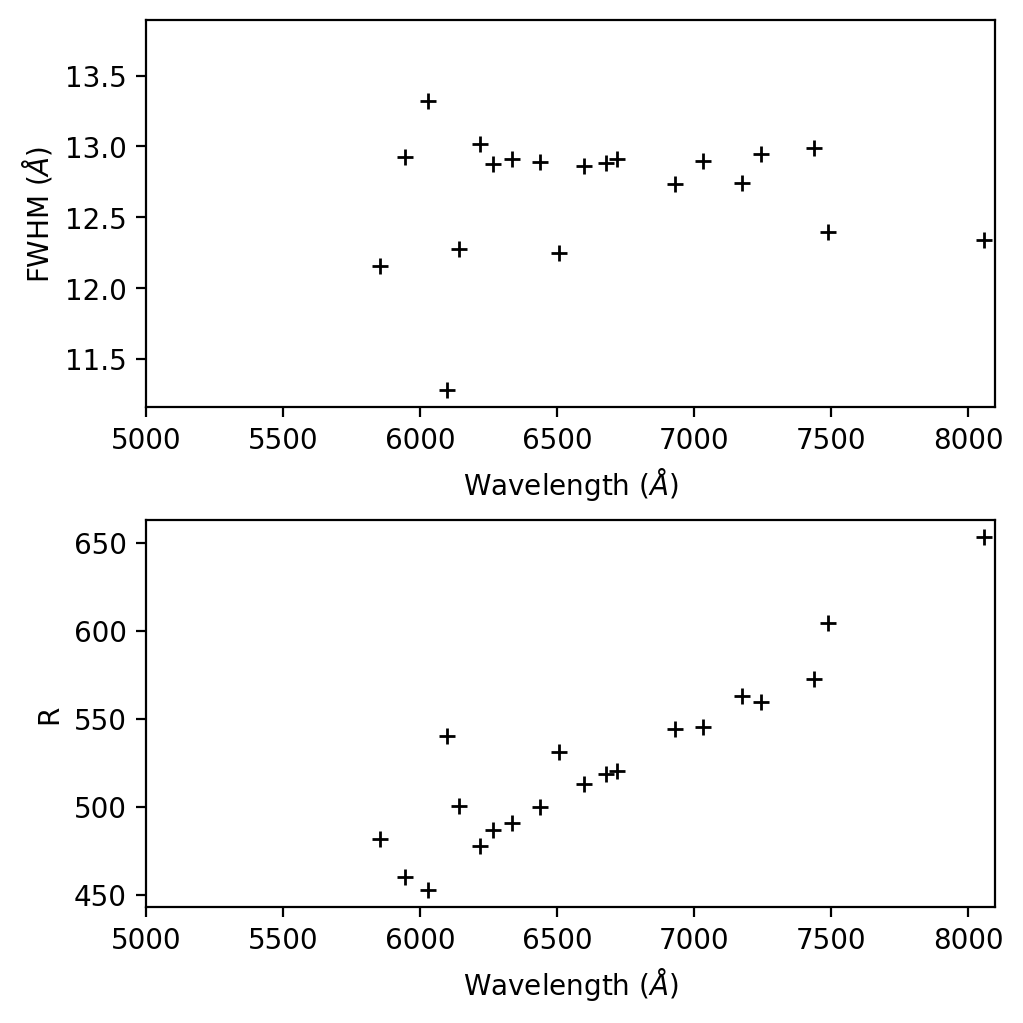

In [42]:
fig = plt.figure(figsize=(5, 5), constrained_layout=True)
ax = fig.add_subplot(211)
ax.plot(resoltab["wavelength"], resoltab["fwhm_angstrom"], c="k", ls="", marker="+")
ax.set_xlim(5000, 8100)
# ax.set_ylim(0, 1.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("FWHM ($\AA$)")
ax = fig.add_subplot(212)
ax.plot(resoltab["wavelength"], resoltab["resolving_power"], c="k", ls="", marker="+")
ax.set_xlim(5000, 8100)
# ax.set_ylim(0, 1.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("R")

In [43]:
colnames = ["fiber_ID", "target_x", "target_y", "target_ra", "target_dec", "target_rank", "target_class"]
assign_table = Table.read(ASSIGNDIR / "tile_032.assign.txt", names=colnames, format='ascii')
# fiber table columns for kspecdr
assign_table["TYPE"] = "N"
# assign_table["TYPE"][assign_table["target_class"] == 9] = "S"
assign_table["TYPE"][np.isin(assign_table["target_class"], [1, 2])] = "P"
assign_table["TYPE"][np.isin(assign_table["target_class"], [9])] = "S"
assign_table["TYPE"][np.isin(assign_table["target_class"], [8])] = "C"
assign_table["TYPE"][np.isin(assign_table["fiber_ID"], [1, 3, 5, 6, 7, 9, 11, 12])] = "S"

# reverse the order of the fibers
# assign_table = assign_table[::-1]

# assign_table["NAME"] = np.array([f"FIB{len(assign_table) - i}" for i in assign_table["fiber_ID"]])
assign_table["NAME"] = np.array([f"FIB{i}" for i in assign_table["fiber_ID"]])
assign_table

fiber_ID,target_x,target_y,target_ra,target_dec,target_rank,target_class,TYPE,NAME
int64,float64,float64,float64,float64,float64,int64,str1,str5
1,7.398,97.826,134.72975,2.584099,14.587,2,S,FIB1
2,-28.32,66.743,134.335481,2.921427,15.045,1,P,FIB2
3,-78.932,66.171,133.781799,2.932066,15.727,2,S,FIB3
4,-22.474,51.314,134.399429,3.090303,15.375,1,P,FIB4
5,51.483,55.786,135.217098,3.042585,15.365,2,S,FIB5
6,-53.19,21.94,134.05903,3.415187,16.043,2,S,FIB6
7,88.432,24.779,135.622404,3.385099,15.972,1,S,FIB7
8,-9.557,1.545,134.542108,3.640912,15.669,2,P,FIB8
9,-85.731,-8.91,133.702733,3.755663,15.409,2,S,FIB9


## Reduce commissioning flats with `reduce_fflat` (blocker check)

Run `reduce_fflat` on each commissioning flat setup (150_620, 300_490, 600_450) and inspect whether outputs are usable for object flat-fielding work.

In [44]:
arc_raw_by_spec = {
    "150_620": CALCONVDIR / "cArc_150_620_240s 2026 January 25.fits",
    "300_490": CALCONVDIR / "cArc_300_490_240s 2026 January 25.fits",
}

flat_raw_files = sorted(CALCONVDIR.glob("cFlat_* 2026 January 25 1.fits"))
fflat_jobs = []

for flat_raw in flat_raw_files:
    spec_set = flat_raw.name.split()[0].replace("cFlat_", "")[:7]
    if spec_set not in arc_raw_by_spec:
        print(f"Skipping {flat_raw.name}: no arc mapping for {spec_set}")
        continue

    flat_im = CALCONVDIR / f"{flat_raw.stem}_im.fits"
    flat_ex = CALCONVDIR / f"{flat_raw.stem}_ex.fits"
    tlm_path = CALDIR / f"tlm_{spec_set}.fits"

    arc_raw = arc_raw_by_spec[spec_set]
    arc_im = CALCONVDIR / f"{arc_raw.stem}_im.fits"
    arc_ex = CALCONVDIR / f"{arc_raw.stem}_ex.fits"
    arc_red = CALCONVDIR / f"{arc_raw.stem}_red.fits"

    if not arc_red.exists():
        reduce_arc(
            {
                "RAW_FILENAME": arc_raw.as_posix(),
                "IMAGE_FILENAME": arc_im.as_posix(),
                "EXTRAC_FILENAME": arc_ex.as_posix(),
                "OUTPUT_FILENAME": arc_red.as_posix(),
                "TLMAP_FILENAME": tlm_path.as_posix(),
                "USE_GENCAL": True,
                "ARCDIR": WD / "data" / "arc_tables",
                "LAMPNAME": "HgArNeKrCd",
            },
            get_diagnostic=False,
        )

    fflat_red = CALDIR / f"fflat_{spec_set}_red.fits"
    reduce_fflat(
        {
            "RAW_FILENAME": flat_raw.as_posix(),
            "EXTRAC_FILENAME": flat_ex.as_posix(),
            "OUTPUT_FILENAME": fflat_red.as_posix(),
            "WAVEL_FILENAME": arc_red.as_posix(),
            "DO_TLMAP": False,
            "DO_EXTRA": False,
            "DO_REDFL": True,
            "TRUNCFLAT": True,
            "USEFLATSTART": 30,
            "USEFLATEND": 1310,
            "LAF_FLAG": False,
            "BSSMOOTH": False,
            "VERBOSE": False,
        }
    )

    fflat_jobs.append(
        {
            "spec_set": spec_set,
            "flat_raw": flat_raw,
            "flat_im": flat_im,
            "flat_ex": flat_ex,
            "tlm": tlm_path,
            "arc_raw": arc_raw,
            "arc_red": arc_red,
            "fflat_red": fflat_red,
        }
    )

fflat_jobs


2026-03-10 23:13:32,777 | kspecdr.reduce_fflat | INFO | Reducing flat spectra data from /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cFlat_150_620_500s 2026 January 25 1_ex.fits
2026-03-10 23:13:32,779 | kspecdr.wavecal.scrunch | INFO | Scrunching tmp_mfsfff.fits using /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits (Reverse=False)
2026-03-10 23:13:32,790 | kspecdr.io.image | INFO | Opened file: tmp_mfsfff.fits (mode: UPDATE)
2026-03-10 23:13:32,794 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits (mode: READ)
2026-03-10 23:13:32,795 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits
2026-03-10 23:13:32,810 | kspecdr.io.image | INFO | Closed file: tmp_mfsfff.fits
2026-0

[{'spec_set': '150_620',
  'flat_raw': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cFlat_150_620_500s 2026 January 25 1.fits'),
  'flat_im': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cFlat_150_620_500s 2026 January 25 1_im.fits'),
  'flat_ex': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cFlat_150_620_500s 2026 January 25 1_ex.fits'),
  'tlm': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/tlm_150_620.fits'),
  'arc_raw': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25.fits'),
  'arc_red': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits'),
  'fflat_red': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/fflat_150_620_red.fits')},
 {'spec_set': '300_4

In [45]:
summary_rows = []
for job in fflat_jobs:
    with fits.open(job["flat_ex"]) as hdu_ex, fits.open(job["fflat_red"]) as hdu_red:
        ex_data = np.asarray(hdu_ex[0].data, dtype=float)
        red_data = np.asarray(hdu_red[0].data, dtype=float)

        summary_rows.append(
            (
                job["spec_set"],
                str(job["fflat_red"]),
                str(ex_data.shape),
                str(red_data.shape),
                bool(ex_data.shape == red_data.shape),
                "WAVELA" in hdu_red,
                hdu_red[0].header.get("SCRUNCH", None),
                float(np.nanmean(np.isfinite(red_data))),
                float(np.nanmedian(np.nanmedian(red_data, axis=1))),
                float(np.nanstd(np.nanmedian(red_data, axis=1))),
            )
        )

fflat_summary = Table(
    rows=summary_rows,
    names=[
        "spec_set",
        "fflat_red",
        "ex_shape",
        "red_shape",
        "shape_match",
        "has_wavela",
        "scrunch_flag",
        "finite_fraction",
        "fiber_median_med",
        "fiber_median_std",
    ],
)
fflat_summary


spec_set,fflat_red,ex_shape,red_shape,shape_match,has_wavela,scrunch_flag,finite_fraction,fiber_median_med,fiber_median_std
str7,str88,str10,str10,bool,bool,bool,float64,float64,float64
150_620,/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/fflat_150_620_red.fits,"(14, 1340)","(14, 1340)",True,True,True,1.0,0.9999928921461105,0.0004582697240682343
300_490,/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/fflat_300_490_red.fits,"(14, 1340)","(14, 1340)",True,True,True,1.0,0.9999842643737793,0.0005858542115986502


2026-03-10 23:13:33,435 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits (mode: READ)
2026-03-10 23:13:33,437 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits
2026-03-10 23:13:33,519 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_300_490_240s 2026 January 25_red.fits (mode: READ)
2026-03-10 23:13:33,520 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_300_490_240s 2026 January 25_red.fits


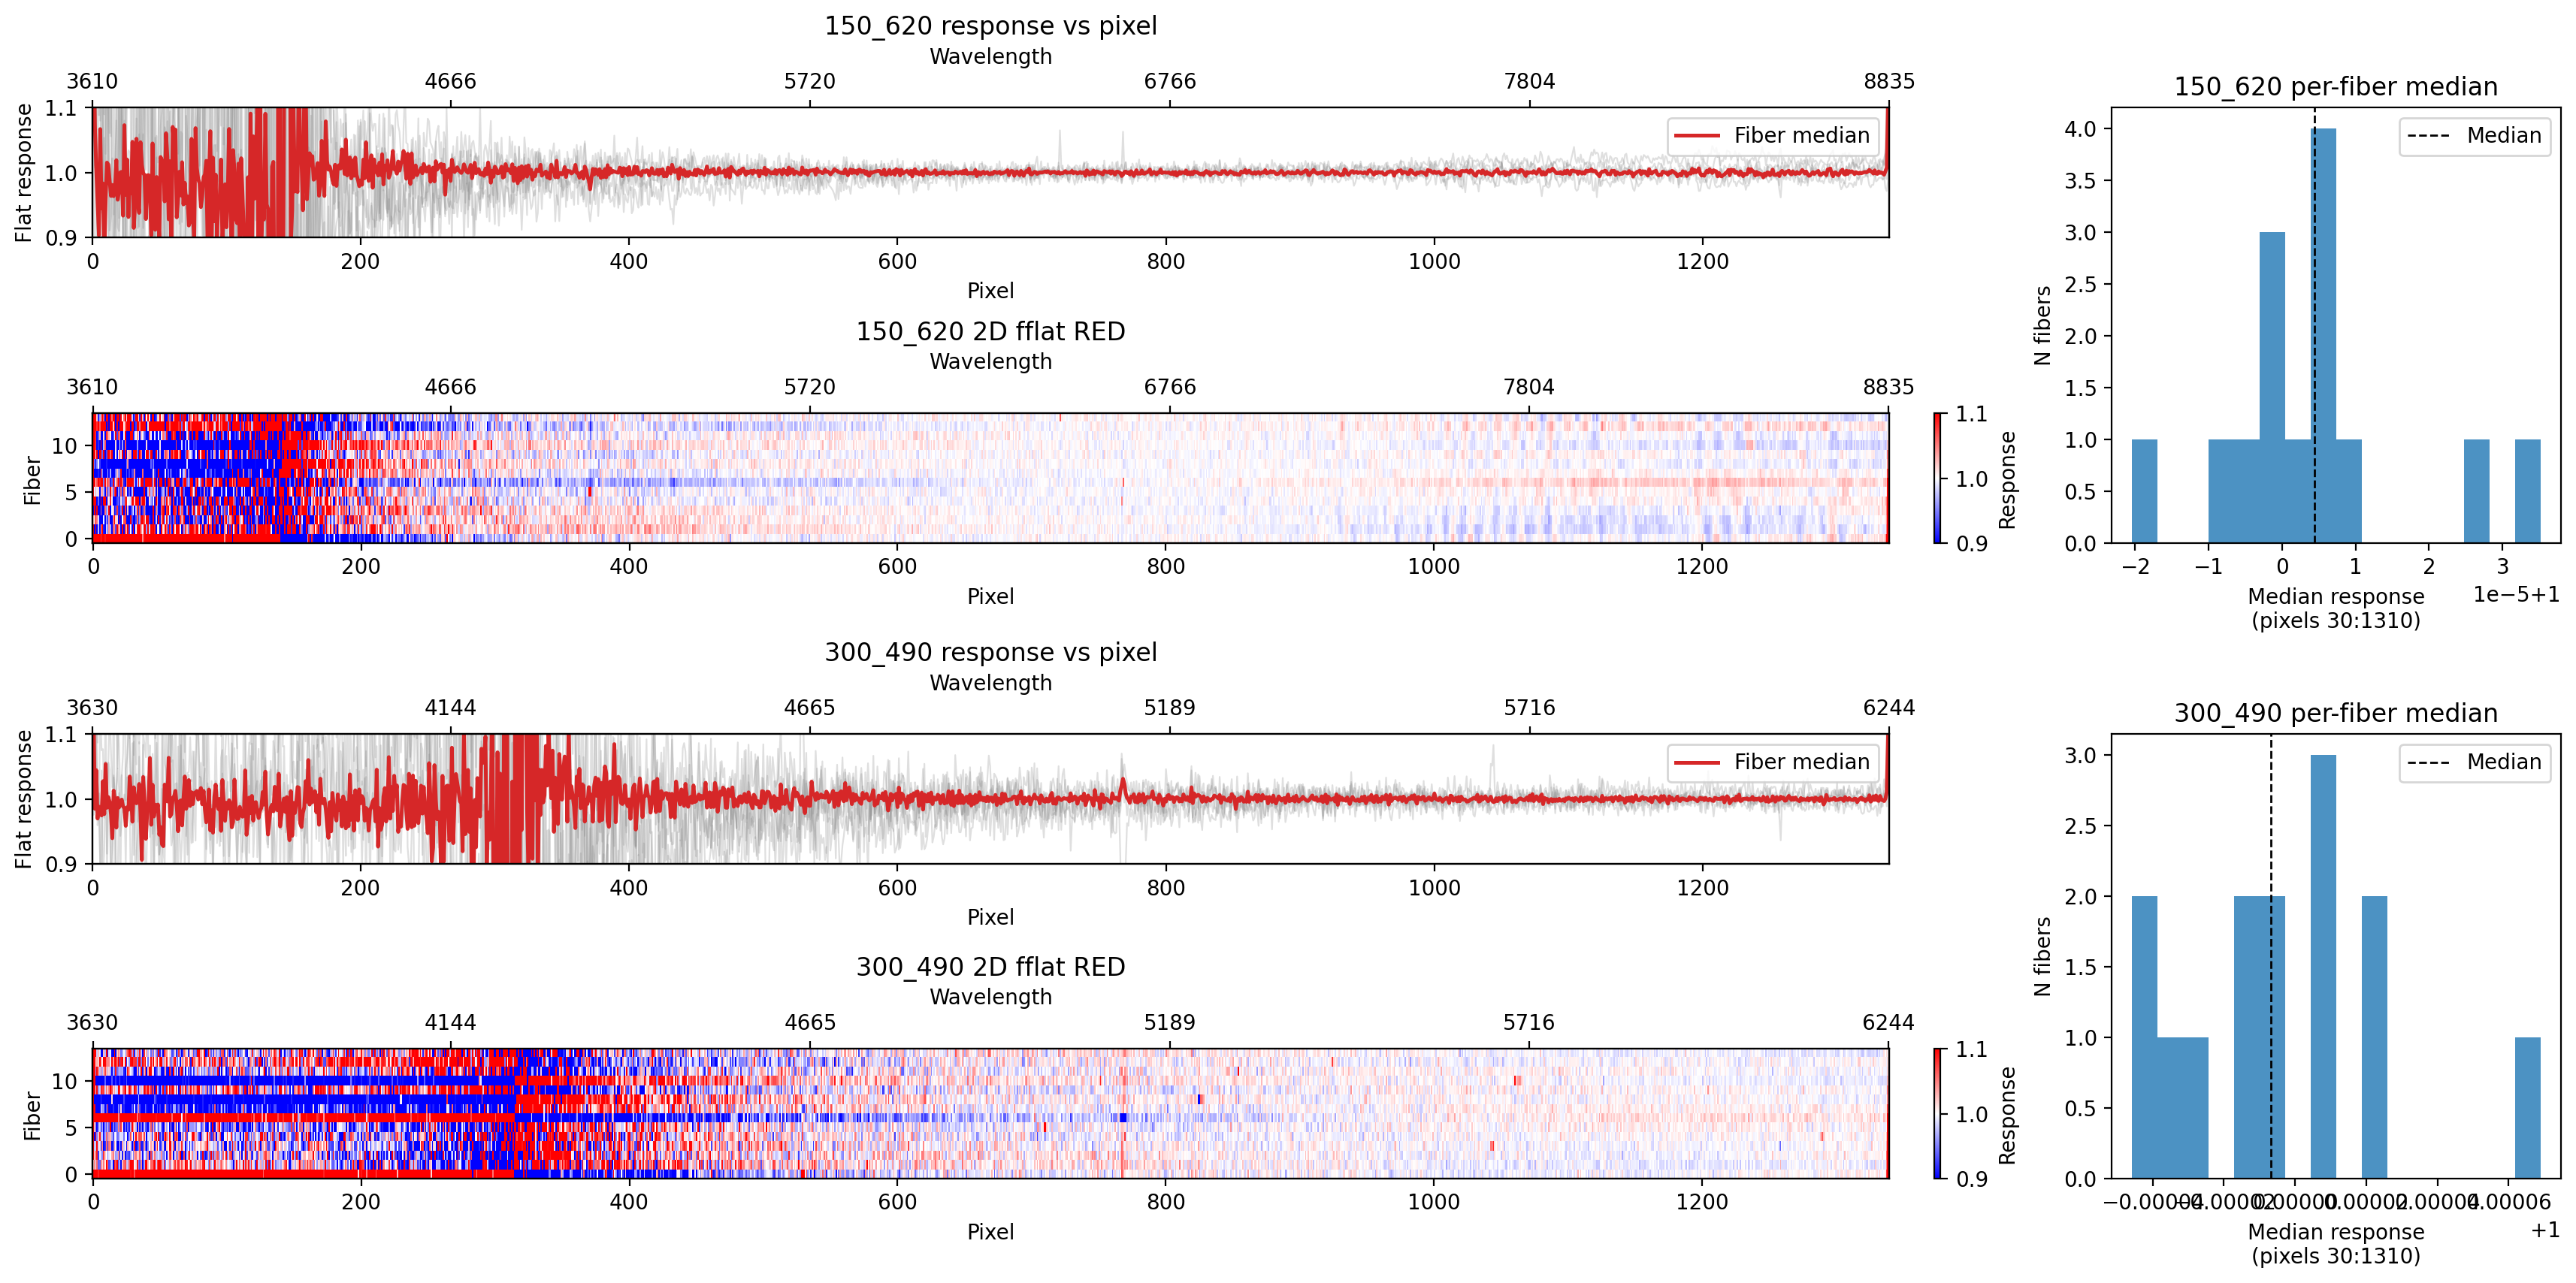

In [46]:
nset = len(fflat_jobs)
if nset == 0:
    raise RuntimeError("No reduce_fflat outputs found. Run the previous cell first.")

fig = plt.figure(figsize=(17, 4.2 * max(1, nset)), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.03, h_pad=0.03, wspace=0.02, hspace=0.02)
gs = fig.add_gridspec(2 * nset, 3, width_ratios=[2, 2, 1])

for i, job in enumerate(fflat_jobs):
    with fits.open(job["fflat_red"]) as hdul:
        red = np.asarray(hdul[0].data, dtype=float)

    npix = red.shape[1]
    xpix = np.arange(npix)

    median_spec = np.nanmedian(red, axis=0)
    sample_idx = np.linspace(0, red.shape[0] - 1, 5, dtype=int)

    # Derive wavelength solution for a reference fiber from the arc file
    wave_ref = None
    try:
        with ImageFile(job["arc_red"].as_posix(), mode="READ") as arc_file:
            wave_data = arc_file.read_wave_data()
        if wave_data is not None and wave_data.shape[1] == npix:
            ref_fiber = wave_data.shape[0] // 2
            wave_ref = wave_data[ref_fiber]
    except Exception:
        wave_ref = None

    # Rows used by this spec_set
    row_top = 2 * i
    row_bottom = 2 * i + 1

    # Left panel (L): response vs pixel, on the top row, spanning first two columns
    ax_left = fig.add_subplot(gs[row_top, :2])
    for fib_idx in sample_idx:
        ax_left.plot(xpix, red[fib_idx], alpha=0.25, lw=0.8, color="gray")
    ax_left.plot(xpix, median_spec, lw=1.8, color="tab:red", label="Fiber median")
    ax_left.set_title(f"{job['spec_set']} response vs pixel")
    ax_left.set_ylabel("Flat response")
    ax_left.set_xlabel("Pixel")
    ax_left.legend(loc="upper right")
    ax_left.set_ylim(0.9, 1.1)
    ax_left.set_xlim(0, npix - 1)

    # Add wavelength axis on top using the reference fiber
    if wave_ref is not None:
        ax_left_wave = ax_left.twiny()
        ax_left_wave.set_xlim(ax_left.get_xlim())
        tick_pix = np.linspace(0, npix - 1, 6, dtype=int)
        tick_wave = wave_ref[tick_pix]
        ax_left_wave.set_xticks(tick_pix)
        ax_left_wave.set_xticklabels([f"{w:.0f}" for w in tick_wave])
        ax_left_wave.set_xlabel("Wavelength")

    # Right-bottom panel (R): 2D fflat RED image, on the bottom row, spanning first two columns
    ax_right = fig.add_subplot(gs[row_bottom, :2])
    # vmin, vmax = np.nanpercentile(red, [1, 99])
    vmin, vmax = 0.9, 1.1
    im = ax_right.imshow(red, origin="lower", aspect="auto", cmap="bwr", vmin=vmin, vmax=vmax, interpolation="none")
    ax_right.set_title(f"{job['spec_set']} 2D fflat RED")
    ax_right.set_xlabel("Pixel")
    ax_right.set_ylabel("Fiber")
    cbar = fig.colorbar(im, ax=ax_right, fraction=0.1, pad=0.01)
    cbar.set_label("Response")

    # Add wavelength axis on top of the image panel using the same reference fiber
    if wave_ref is not None:
        ax_right_wave = ax_right.twiny()
        ax_right_wave.set_xlim(ax_right.get_xlim())
        tick_pix = np.linspace(0, npix - 1, 6, dtype=int)
        tick_wave = wave_ref[tick_pix]
        ax_right_wave.set_xticks(tick_pix)
        ax_right_wave.set_xticklabels([f"{w:.0f}" for w in tick_wave])
        ax_right_wave.set_xlabel("Wavelength")

    # Middle panel (M): per-fiber median histogram, spanning both rows in the right column
    ax_mid = fig.add_subplot(gs[row_top:row_bottom + 1, 2])
    fiber_median = np.nanmedian(red[:, 30:1310], axis=1)
    fiber_median = fiber_median[np.isfinite(fiber_median)]
    ax_mid.hist(fiber_median, bins=16, color="tab:blue", alpha=0.8)
    ax_mid.axvline(np.nanmedian(fiber_median), color="k", lw=1, ls="--", label="Median")
    ax_mid.set_title(f"{job['spec_set']} per-fiber median")
    ax_mid.set_xlabel("Median response\n(pixels 30:1310)")
    ax_mid.set_ylabel("N fibers")
    ax_mid.legend(loc="upper right")

plt.show()


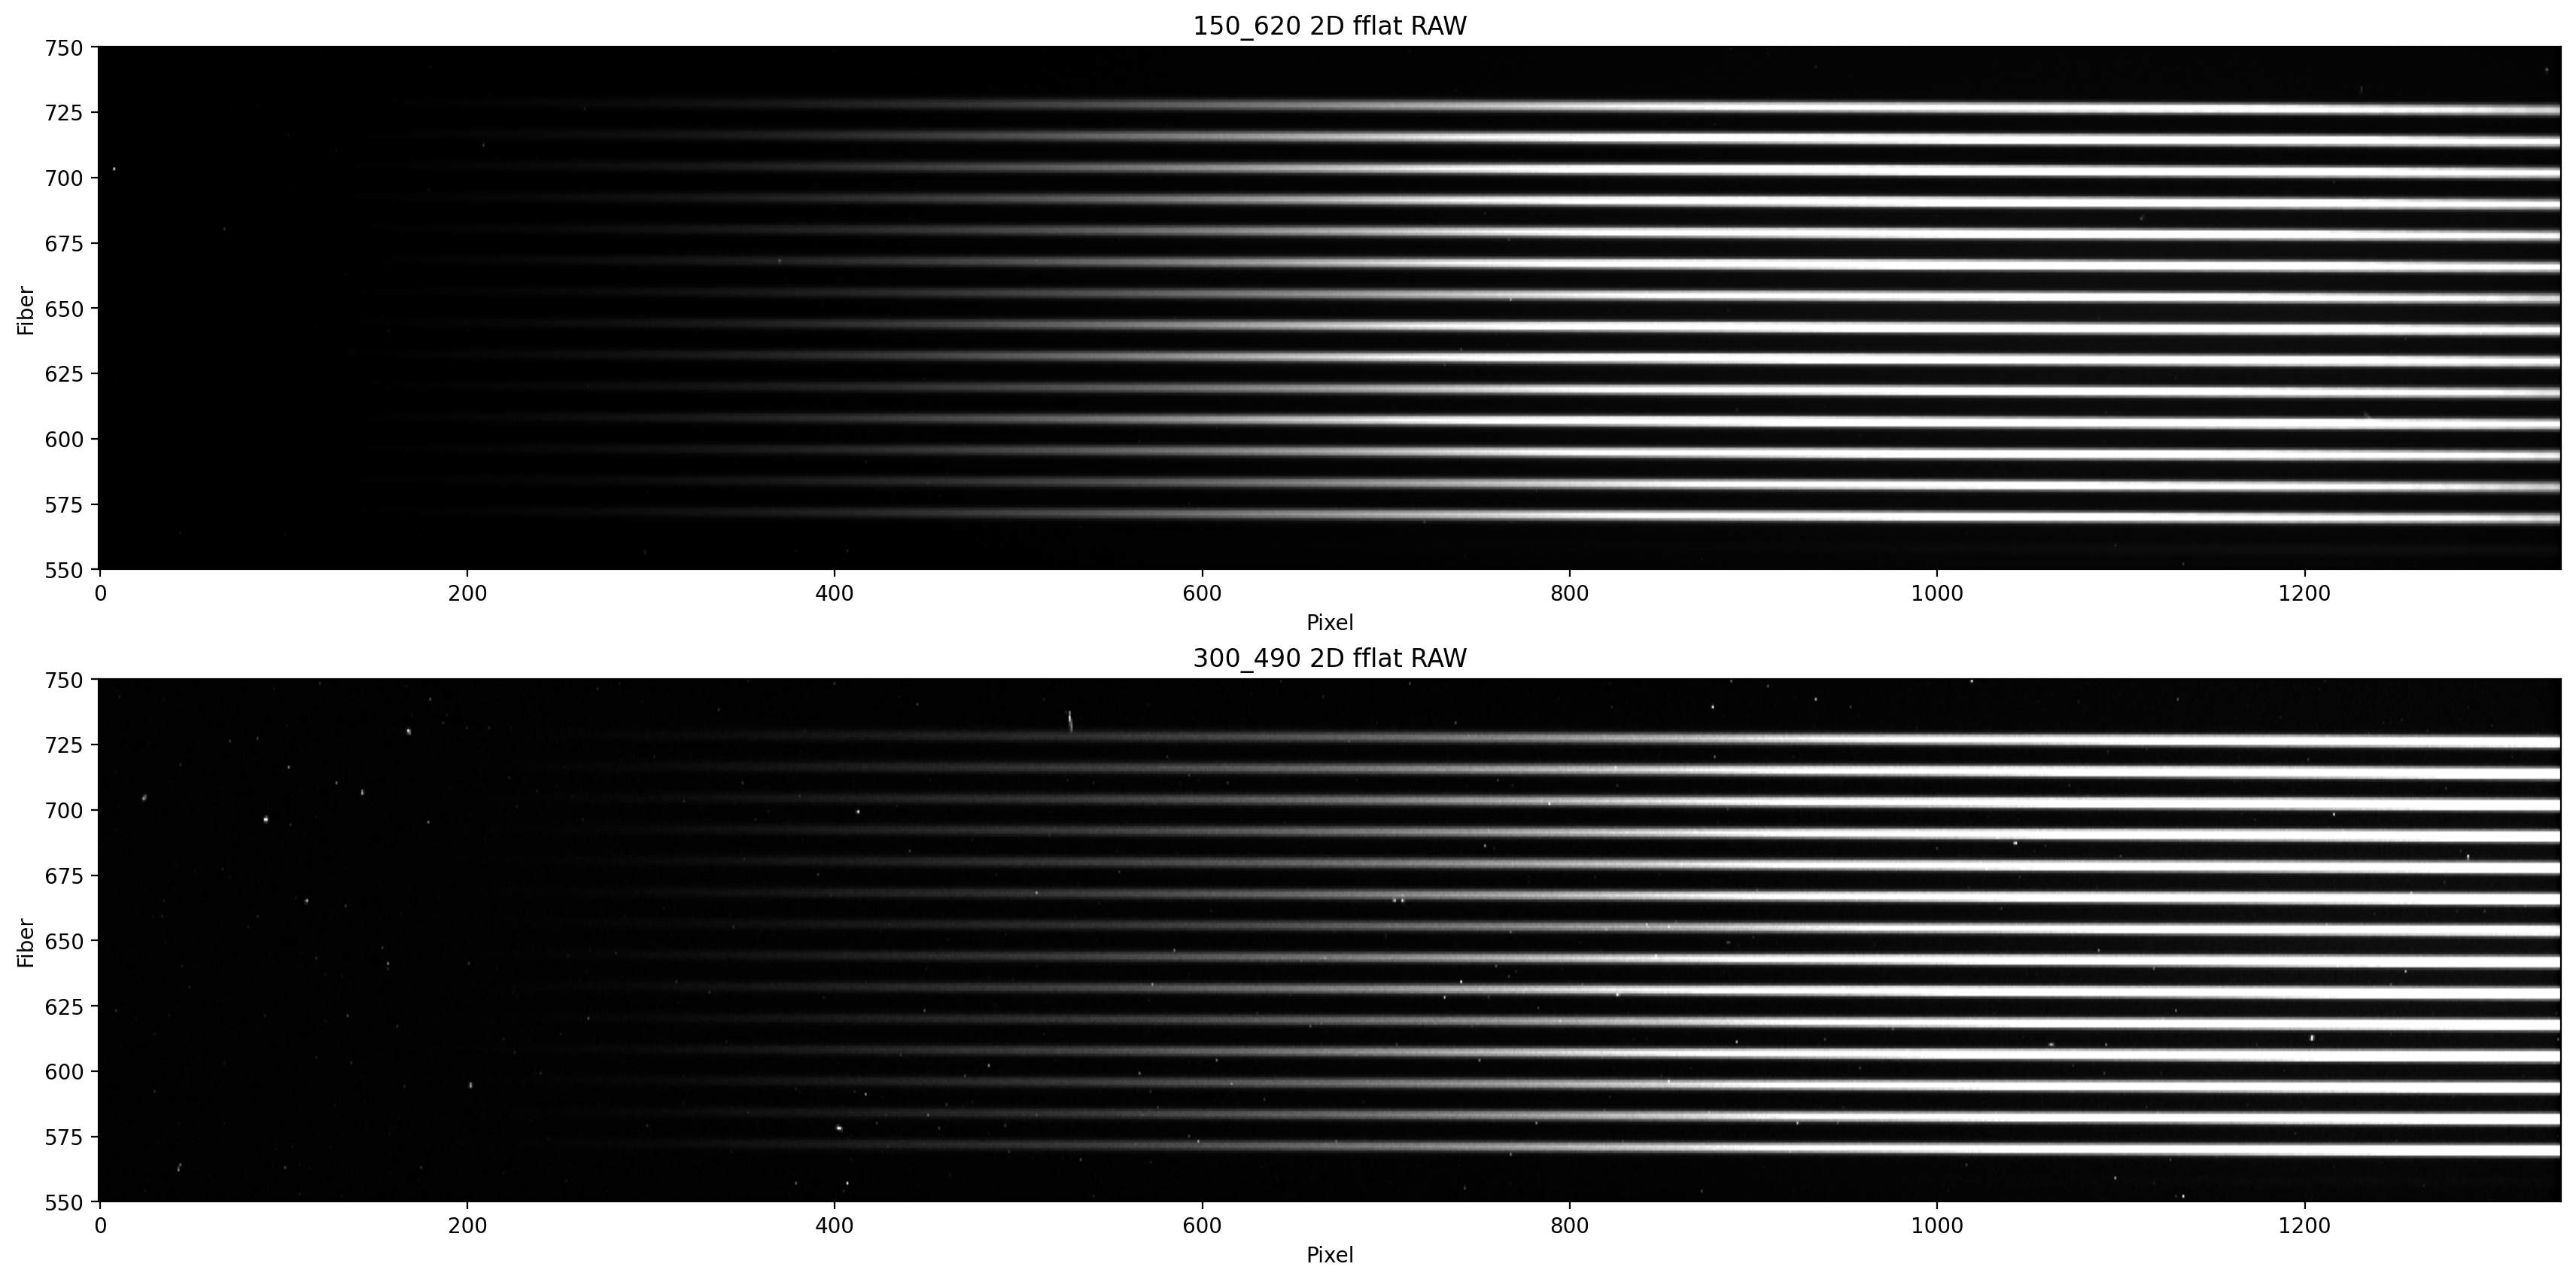

In [47]:
fig = plt.figure(figsize=(17, 4.2 * max(1, nset)), constrained_layout=True)

for i, job in enumerate(fflat_jobs):
    with fits.open(job["flat_raw"]) as hdul:
        raw = np.asarray(hdul[0].data, dtype=float)
    
    ax = fig.add_subplot(nset, 1, i + 1)
    vmin, vmax = np.nanpercentile(raw, [1, 99])
    ax.imshow(raw, origin="lower", aspect="auto", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{job['spec_set']} 2D fflat RAW")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Fiber")
    ax.set_ylim(550, 750)

## Reduce Object Science Frame with `reduce_object`

Reduce the `tile_059` science frames from the January 29 commissioning run using `reduce_object`:

- **Throughput calibration**: `SKYLINE(KGB)` — Karl Glazebrook's sky-line robust-slope algorithm
- **Flux calibration**: ATLAS Refcat2 standard-star catalog + BOSZ stellar templates (`CALIBFLUX=True`)
- **Intermediate products**: `RWSS` (pre-sky-subtracted), `SKY`, and `THPUT` extensions are saved for inspection

The standard star in `tile_059` is fiber 3 (0-indexed: 2, class 8 in the assignment), matched to the Refcat2 entry in `standard_star_atlas_refcat2.csv`.

In [48]:
from kspecdr.reduce_object import reduce_object
from kspecdr.fluxcal.qc import (
    plot_calibration_summary,
    plot_per_star_vectors,
    plot_calibration_residuals,
    plot_photometric_residuals,
    summarize_calibration,
)
from kspecdr.fluxcal.calibration import (
    compute_calibration_vector_for_star,
    combine_calibration_vectors,
)
from kspecdr.fluxcal.photometry import (
    load_filter_curves,
    load_standard_star_catalog,
    photometry_from_catalog_row,
    DEFAULT_BANDS,
)
from kspecdr.fluxcal.templates import TemplateLibrary, prepare_template
from kspecdr.fluxcal.masks import load_mask_regions
from kspecdr.fluxcal.containers import Spectrum1D
from kspecdr.constants import FIBER_TYPE_CALIBRATION

CATALOG = CALDIR / "standard_star_atlas_refcat2.csv"

# Arc RED files produced by the fflat setup cell above
arc_red_by_spec = {
    "150_620": CALCONVDIR / "cArc_150_620_240s 2026 January 25_red.fits",
    "300_490": CALCONVDIR / "cArc_300_490_240s 2026 January 25_red.fits",
}
# --- Convert tile_059 raw science frames and run make_im ---
tile032_files = sorted(TESTDIR.glob("tile_032*.fits"))
obj_jobs = []

for fpath in tile032_files:
    fpath_converted = CONVDIR / fpath.name.replace("tile_032", "ctile_032")
    im_path = CONVDIR / (fpath_converted.stem + "_im.fits")
    ex_path = CONVDIR / (fpath_converted.stem + "_ex.fits")

    write_isoplane_converted_image(fpath, fpath_converted, "OBJECT", fiber_table=assign_table)

    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="LACOSMIC",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
        use_dark=True,
        dark_filename=mdark_path.as_posix(),
    )

    # Determine spectral setup from IM file header (GRATID + LAMBDAC)
    with ImageFile(im_path.as_posix()) as img:
        grating = img.get_header_value("GRATID")
        lambdac = float(img.get_header_value("LAMBDAC"))
        spec_set = f"{grating}_{lambdac/10:.0f}"

    tlm_path = CALDIR / f"tlm_{spec_set}.fits"
    fflat_path = CALDIR / f"fflat_{spec_set}_red.fits"
    arc_red_path = arc_red_by_spec.get(spec_set)

    if arc_red_path is None:
        print(f"WARNING: no arc file for spec_set={spec_set!r} — scrunch will be skipped")

    red_path = PROCDIR / f"{fpath_converted.stem}_red.fits"

    obj_jobs.append({
        "spec_set": spec_set,
        "raw": fpath,
        "converted": fpath_converted,
        "im": im_path,
        "ex": ex_path,
        "tlm": tlm_path,
        "fflat": fflat_path,
        "arc_red": arc_red_path,
        "red": red_path,
    })
    print(f"  {fpath.name}  →  spec_set={spec_set}")

print(f"\nReady to reduce {len(obj_jobs)} tile_032 science frame(s)")

2026-03-10 23:13:37,064 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-03-10 23:13:37,083 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-03-10 23:13:37,086 | kspecdr.inst.isoplane | INFO | Adding fiber table with None fibers
2026-03-10 23:13:37,087 | kspecdr.inst.isoplane | WARNING | Fiber table has 14 rows, but n_fibers=None were given. Ignoring n_fibers argument.
2026-03-10 23:13:37,106 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-03-10 23:13:37,119 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-03-10 23:13:37,119 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 202

  tile_032 2026 January 25 1.fits  →  spec_set=150_620


2026-03-10 23:13:38,305 | kspecdr.preproc.make_im | INFO | Detected and removed 12872 cosmic ray pixels
2026-03-10 23:13:38,341 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 2_im.fits
2026-03-10 23:13:38,351 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 2_im.fits (mode: READ)
2026-03-10 23:13:38,352 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 2_im.fits


  tile_032 2026 January 25 2.fits  →  spec_set=150_620

Ready to reduce 2 tile_032 science frame(s)


In [49]:
for job in obj_jobs:
    print(f"\nReducing: {job['raw'].name}")

    args = {
        # IM → EX pipeline (make_ex runs inside reduce_object using IMAGE_FILENAME)
        "IMAGE_FILENAME":  job["im"].as_posix(),
        "EXTRAC_FILENAME": job["ex"].as_posix(),
        "OUTPUT_FILENAME": job["red"].as_posix(),
        # Calibration files
        "TLMAP_FILENAME":  job["tlm"].as_posix(),
        "FFLAT_FILENAME":  job["fflat"].as_posix(),
        "USEFFLAT": False,
        "WAVEL_FILENAME":  job["arc_red"].as_posix() if job["arc_red"] else "",
        # Throughput calibration: Karl Glazebrook sky-line robust-slope algorithm
        # "TPMETH": "SKYLINE(KGB)",
        "TPMETH": "OFF",
        # Save pre-sky-subtraction snapshot for later inspection
        "INC_RWSS": True,
        # Sky subtraction (mean combination of sky fibers)
        "SKYSUB": True,
        # "SKYSUB_METHOD": "MEDIAN",
        "SKYCOMBINE": "SIGCLIP",
        "SKYCOMBINE_SIGMA": 3.0,
        "SKYCOMBINE_NITER": 15,
        # Flux calibration with Refcat2 standard-star catalog + BOSZ templates
        "CALIBFLUX": False,
        "CALIBFLUX_CATALOG": CATALOG.as_posix(),
        "CALIBFLUX_METRIC": "chi2",
        "VERBOSE": True,
    }

    reduce_object(args)
    print(f"  ✓  Written: {job['red']}")

2026-03-10 23:13:38,407 | kspecdr.reduce_object | WARNING | RAW_FILENAME not in args; skipping MAKE_IM (assuming IM file already exists)
2026-03-10 23:13:38,408 | kspecdr.extract.make_ex | INFO | Extracting /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_im.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_ex.fits using TLM /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/tlm_150_620.fits
2026-03-10 23:13:38,409 | kspecdr.extract.make_ex | INFO | Extraction Method: TRAM
2026-03-10 23:13:38,420 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_im.fits (mode: READ)
2026-03-10 23:13:38,433 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/tlm_150_620.fits (mode: READ)
2026-03-10 23:13:38,436 | kspecdr.io.image | INFO | Close


Reducing: tile_032 2026 January 25 1.fits


Summing extraction: 100%|██████████| 1340/1340 [00:01<00:00, 1222.56pixel/s]
2026-03-10 23:13:39,560 | kspecdr.extract.make_ex | INFO | Written extracted file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_ex.fits
2026-03-10 23:13:39,562 | kspecdr.reduce_object | INFO | ==================================================
2026-03-10 23:13:39,562 | kspecdr.reduce_object | INFO | Reducing object spectra from extraction file
2026-03-10 23:13:39,563 | kspecdr.reduce_object | INFO | ==================================================
2026-03-10 23:13:39,563 | kspecdr.reduce_object | INFO | Extraction file = /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_ex.fits
2026-03-10 23:13:39,564 | kspecdr.reduce_object | INFO | Creating RED file /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 1_red.fits from /Users/hbahk/Research/kspec/kspecdr/resources/co

  ✓  Written: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 1_red.fits

Reducing: tile_032 2026 January 25 2.fits


Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1814.61pixel/s]
2026-03-10 23:13:40,892 | kspecdr.extract.make_ex | INFO | Written extracted file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 2_ex.fits
2026-03-10 23:13:40,893 | kspecdr.reduce_object | INFO | ==================================================
2026-03-10 23:13:40,893 | kspecdr.reduce_object | INFO | Reducing object spectra from extraction file
2026-03-10 23:13:40,894 | kspecdr.reduce_object | INFO | ==================================================
2026-03-10 23:13:40,894 | kspecdr.reduce_object | INFO | Extraction file = /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 2_ex.fits
2026-03-10 23:13:40,895 | kspecdr.reduce_object | INFO | Creating RED file /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 2_red.fits from /Users/hbahk/Research/kspec/kspecdr/resources/co

  ✓  Written: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 2_red.fits


Filename: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 2_red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     181   (1340, 14)   float32   
  1  VARIANCE      1 ImageHDU         8   (1340, 14)   float32   
  2  WAVELA        1 ImageHDU         8   (1340, 14)   float32   
  3  FIBRES        1 BinTableHDU     27   14R x 9C   [K, D, D, D, D, D, K, 1A, 5A]   
  4  THPUT         1 ImageHDU         7   (14,)   float32   
  5  RWSS          1 ImageHDU         8   (1340, 14)   float32   
  6  RWSSVAR       1 ImageHDU         8   (1340, 14)   float32   
  7  SKY           1 ImageHDU         7   (1340,)   float32   
  8  SKYVAR        1 ImageHDU         7   (1340,)   float32   


2026-03-11 00:29:08,280 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 2_red.fits (mode: READ)
2026-03-11 00:29:08,288 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 January 25 2_red.fits


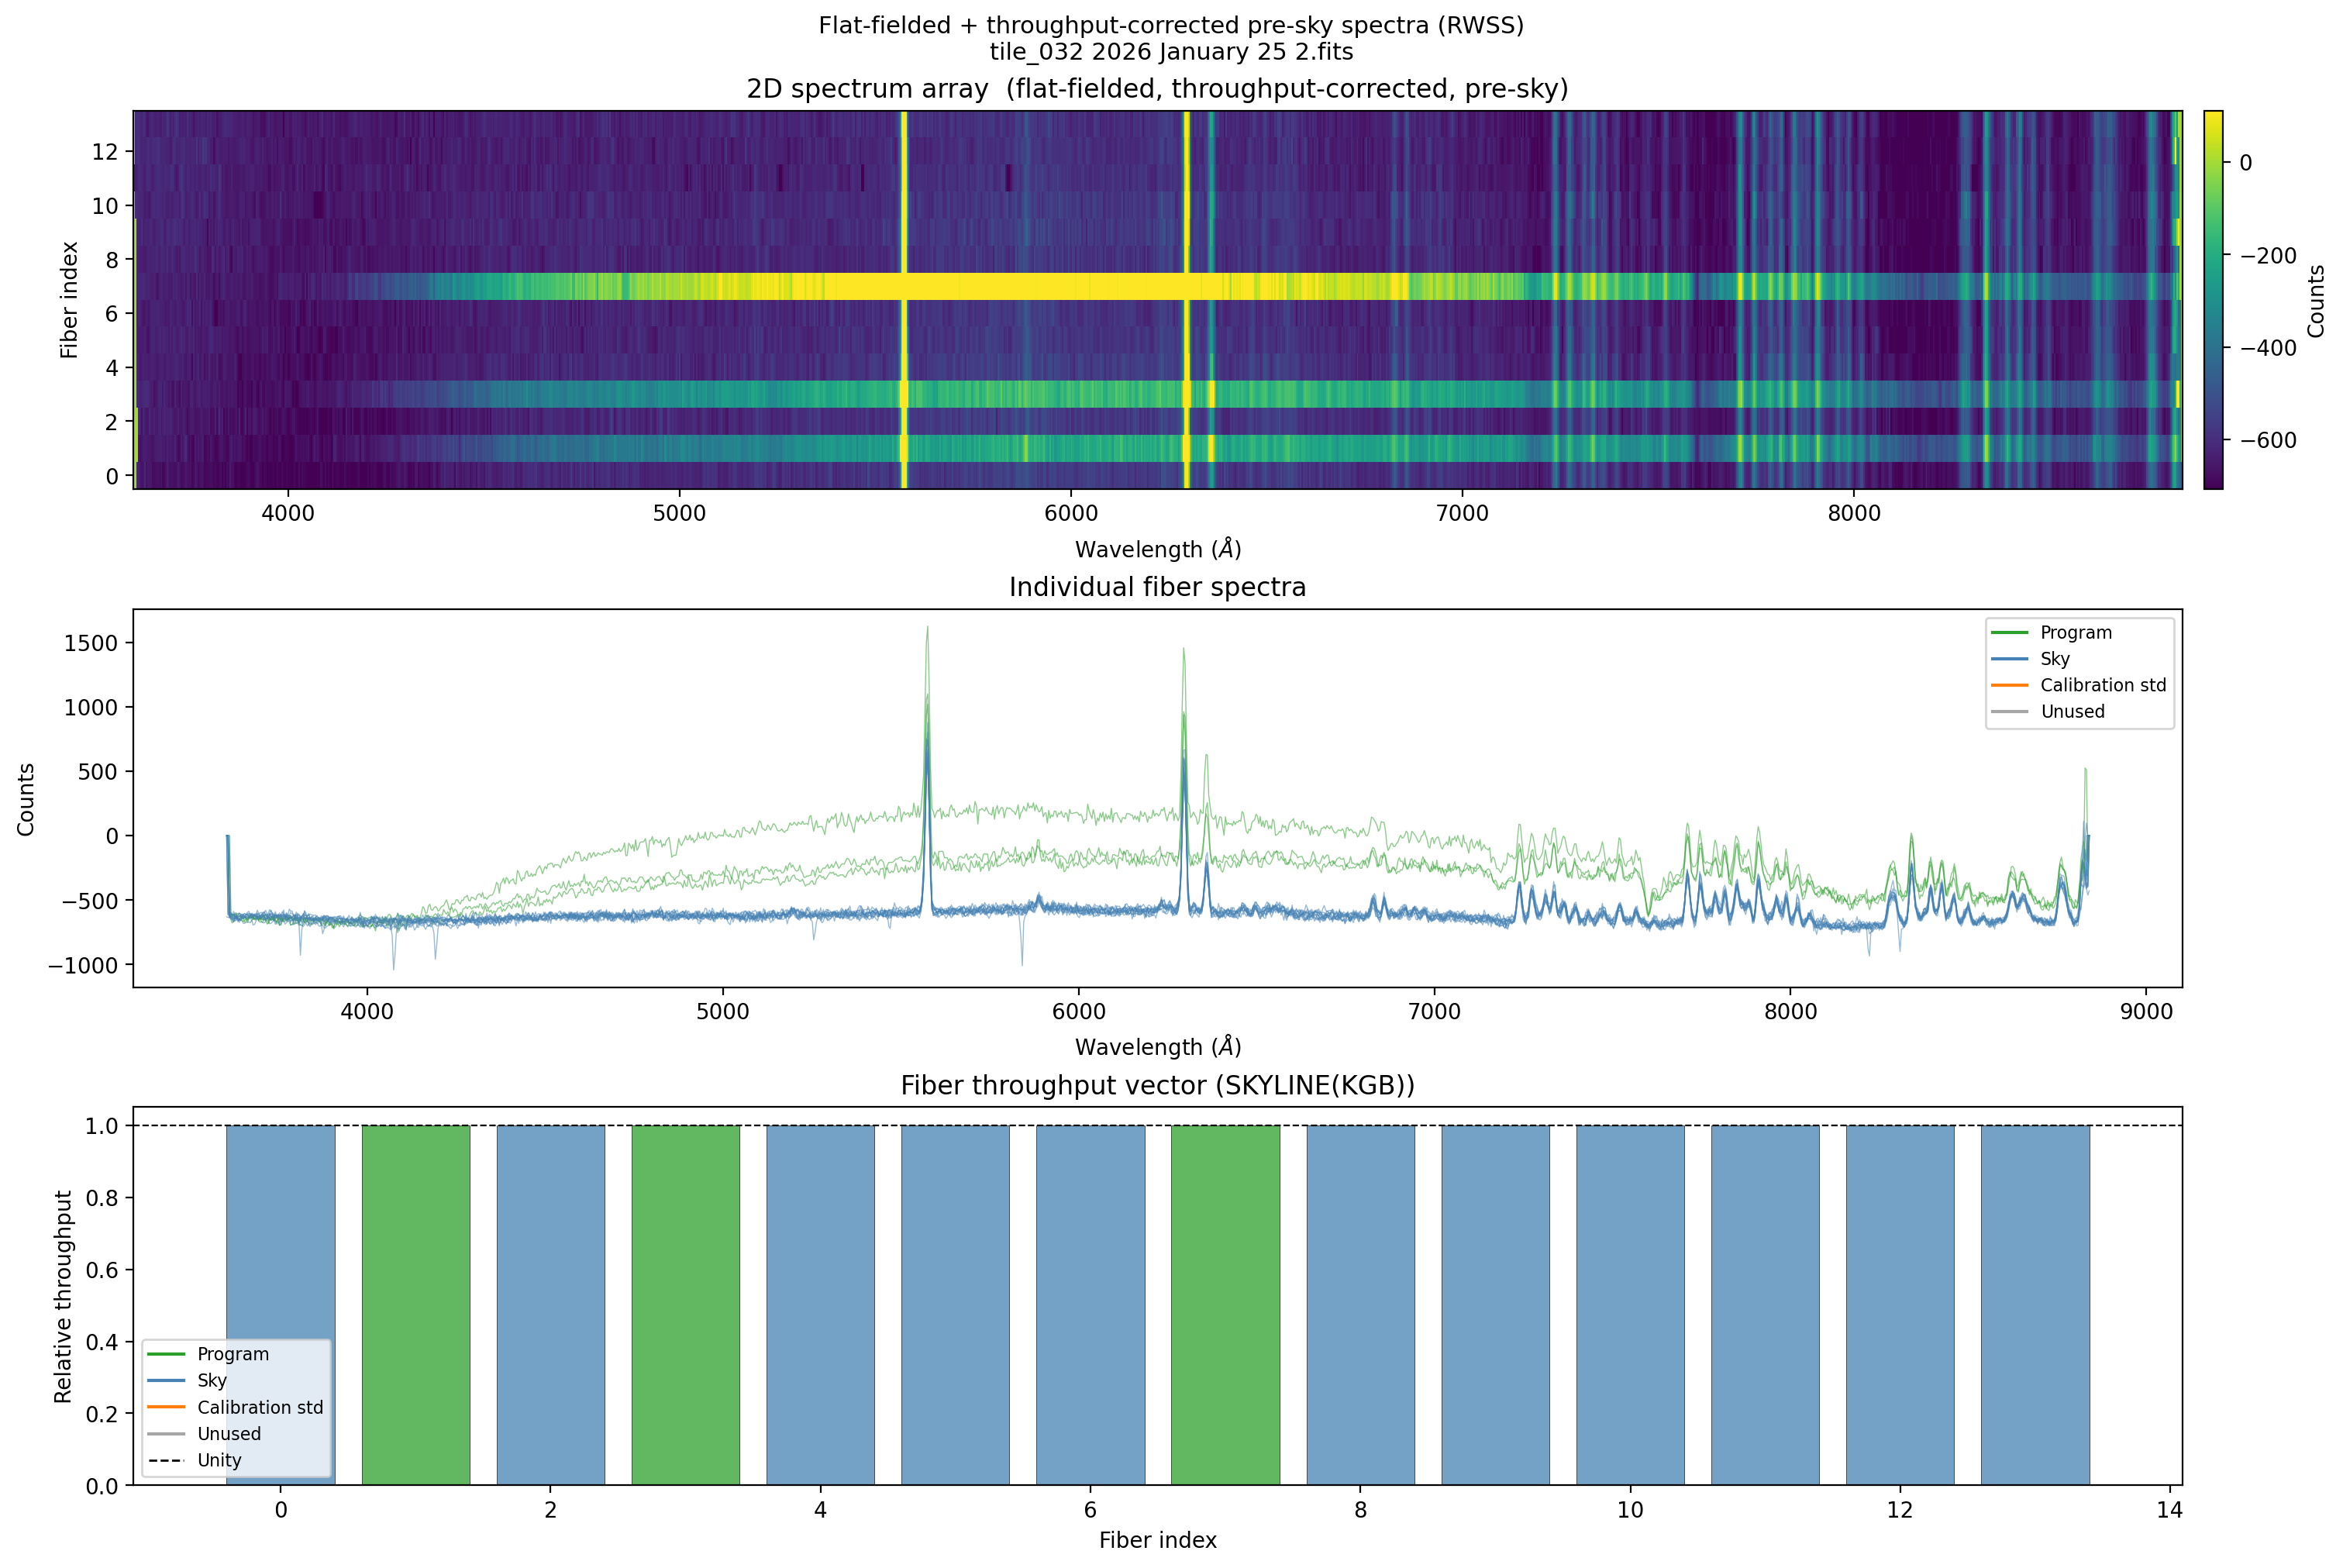

In [119]:
# ─────────────────────────────────────────────────────────────────────────────
# Flat-fielded + throughput-corrected pre-sky spectra  (RWSS extension)
# RWSS = post flat-field, post scrunch, post SKYLINE(KGB) throughput, PRE sky-sub
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[1]

with fits.open(job["red"]) as hdul:
    hdul.info()
    wave_hdu  = hdul["WAVELA"].data if "WAVELA" in hdul else None
    rwss      = hdul["RWSS"].data.astype(float)
    thput_vec = hdul["THPUT"].data.astype(float) if "THPUT" in hdul else None

with ImageFile(job["red"].as_posix(), mode="READ") as red_f:
    fiber_types, _ = red_f.read_fiber_types(1000)

if wave_hdu is not None and wave_hdu.ndim == 2:
    wave = wave_hdu[0]
elif wave_hdu is not None:
    wave = wave_hdu
else:
    wave = np.arange(rwss.shape[1])

nfib  = rwss.shape[0]
ftypes = list(fiber_types[:nfib])

colors_by_type = {"S": "steelblue", "P": "tab:green", "C": "tab:orange", "N": "0.65"}
type_labels    = {"S": "Sky", "P": "Program", "C": "Calibration std", "N": "Unused"}
legend_handles = [
    Line2D([0], [0], color=colors_by_type[t], lw=1.5, label=type_labels[t])
    for t in ["P", "S", "C", "N"]
]

fig, axes = plt.subplots(3, 1, figsize=(15, 10), constrained_layout=True)
fig.suptitle(
    f"Flat-fielded + throughput-corrected pre-sky spectra (RWSS)\n{job['raw'].name}",
    fontsize=11,
)

# — 2D image —
ax = axes[0]
vmin, vmax = np.nanpercentile(rwss, [2, 98])
im_plot = ax.imshow(
    rwss, origin="lower", aspect="auto", cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, throughput-corrected, pre-sky)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)

# — Individual spectra colour-coded by fiber type —
ax = axes[1]
for i in range(nfib):
    ftype = ftypes[i] if i < len(ftypes) else "N"
    c     = colors_by_type.get(ftype, "0.65")
    valid = np.isfinite(rwss[i])
    if np.sum(valid) > 10:
        ax.plot(wave[valid], rwss[i][valid], lw=0.5, alpha=0.55, color=c)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
ax.set_title("Individual fiber spectra")
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

# — SKYLINE(KGB) throughput vector —
ax = axes[2]
if thput_vec is not None:
    for i in range(min(nfib, len(thput_vec))):
        ftype = ftypes[i] if i < len(ftypes) else "N"
        c = colors_by_type.get(ftype, "0.65")
        t_val = float(thput_vec[i])
        if np.isfinite(t_val) and t_val > 0:
            ax.bar(i, t_val, color=c, width=0.8, alpha=0.75, edgecolor="k", linewidth=0.3)
    ax.axhline(1.0, color="k", lw=0.8, ls="--", label="Unity")
    ax.set_xlabel("Fiber index")
    ax.set_ylabel("Relative throughput")
    ax.set_title("Fiber throughput vector (SKYLINE(KGB))")
    ax.legend(
        handles=legend_handles + [Line2D([0], [0], color="k", ls="--", lw=1, label="Unity")],
        fontsize=8,
    )
else:
    ax.text(0.5, 0.5, "THPUT extension not found", transform=ax.transAxes, ha="center")

plt.show()

In [120]:
obj_jobs

[{'spec_set': '150_620',
  'raw': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/tile_032 2026 January 25 1.fits'),
  'converted': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1.fits'),
  'im': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_im.fits'),
  'ex': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/converted/ctile_032 2026 January 25 1_ex.fits'),
  'tlm': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/tlm_150_620.fits'),
  'fflat': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/fflat_150_620_red.fits'),
  'arc_red': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/calib/converted/cArc_150_620_240s 2026 January 25_red.fits'),
  'red': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260125/processed/ctile_032 2026 J

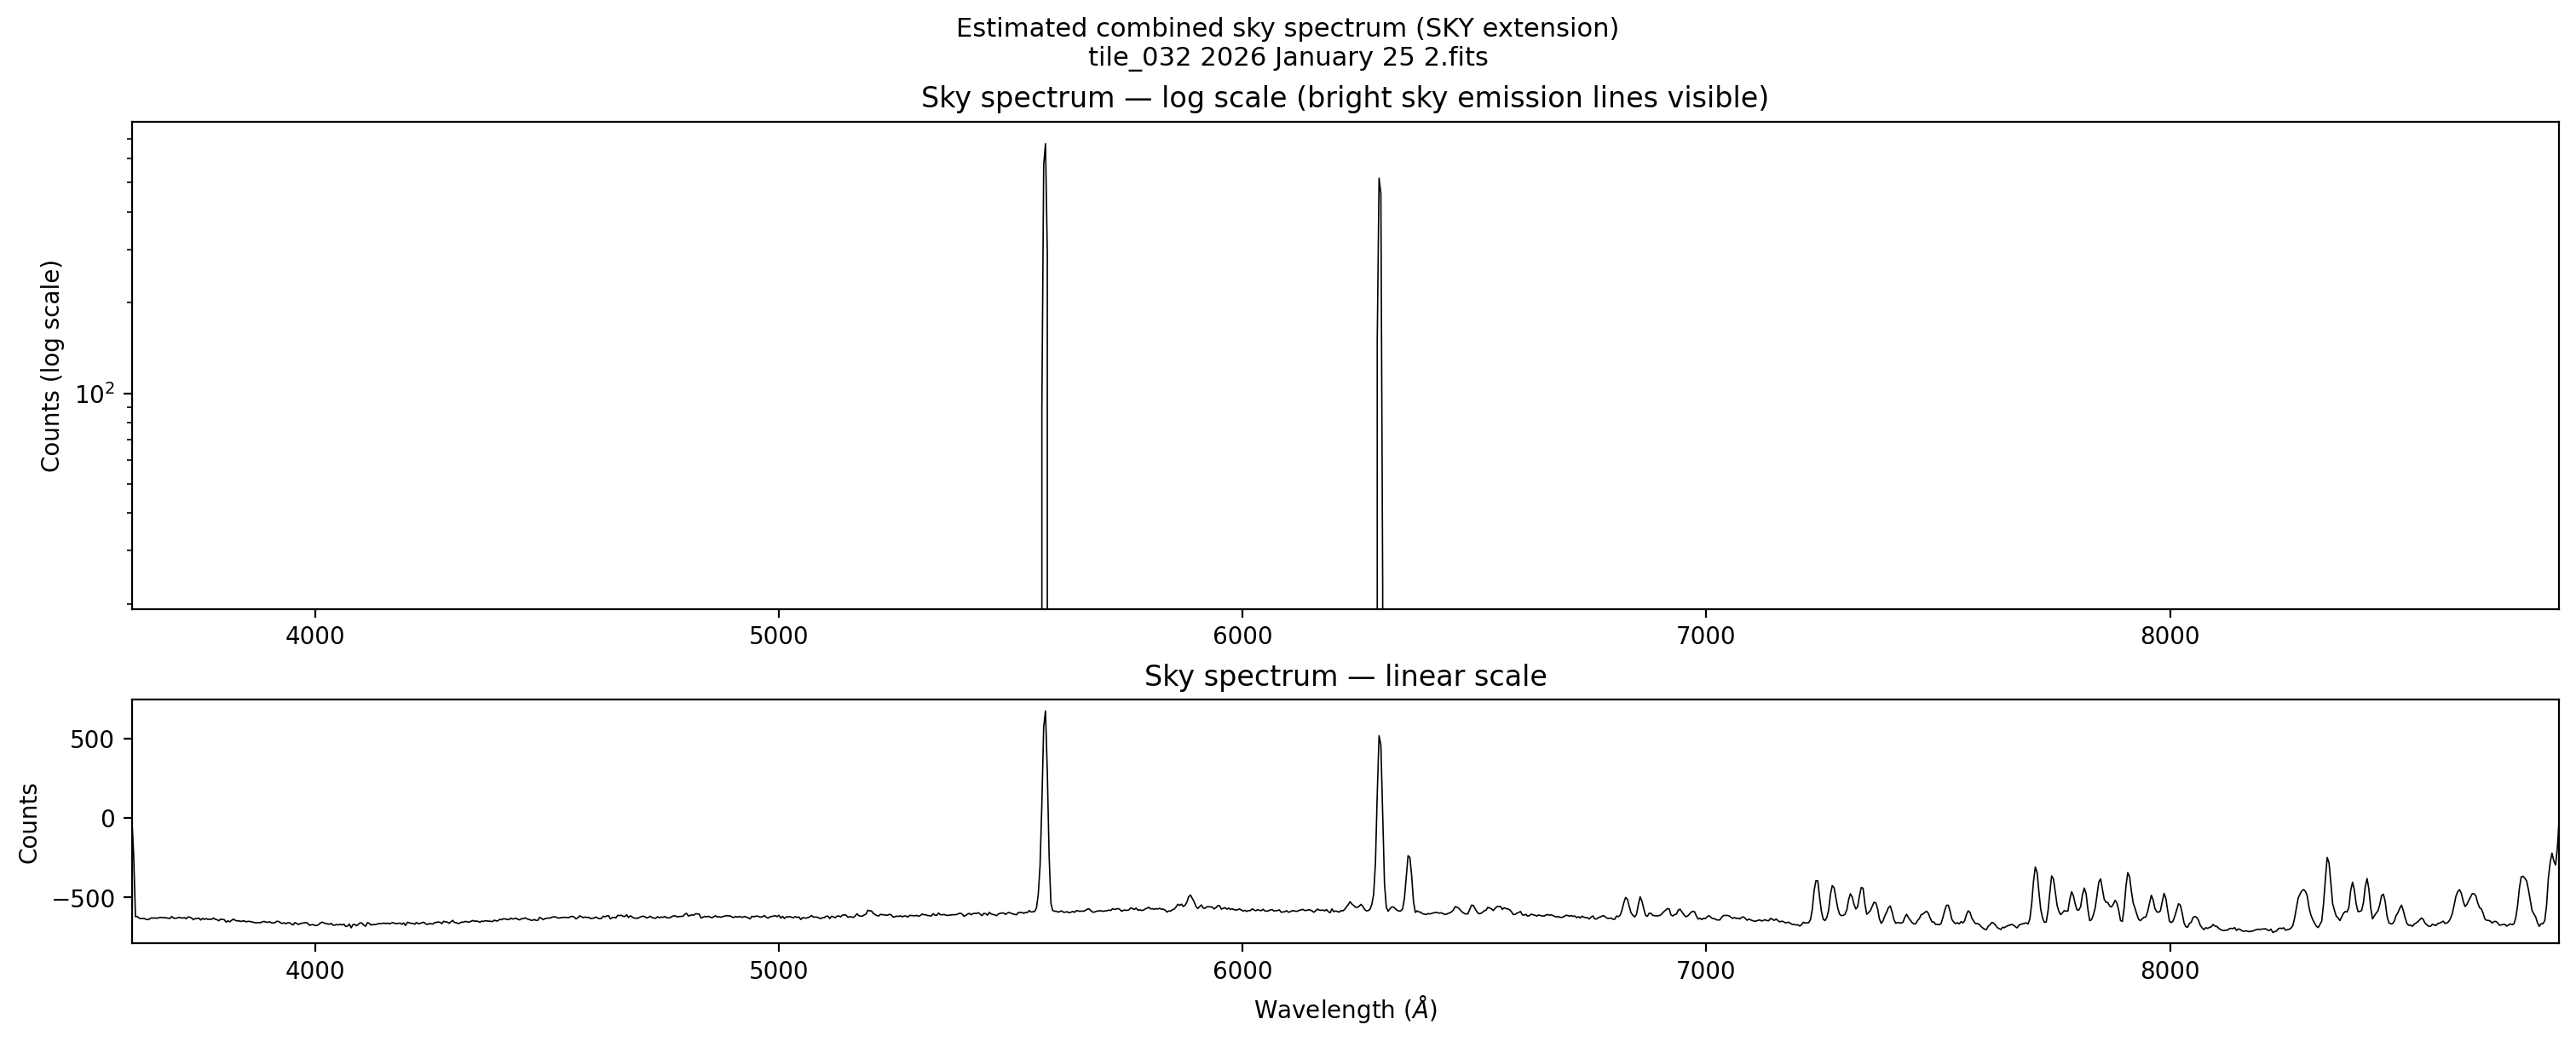

In [121]:
# ─────────────────────────────────────────────────────────────────────────────
# Estimated combined sky spectrum  (SKY extension)
# Combined from all sky fibers (TYPE='S') by mean combination
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[1]

with fits.open(job["red"]) as hdul:
    sky = hdul["SKY"].data.astype(float)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle(f"Estimated combined sky spectrum (SKY extension)\n{job['raw'].name}", fontsize=11)

valid = np.isfinite(sky) #& (sky > 0)

ax = axes[0]
ax.plot(wave[valid], sky[valid], "k-", lw=0.6)
ax.set_ylabel("Counts (log scale)")
ax.set_title("Sky spectrum — log scale (bright sky emission lines visible)")
ax.set_yscale("log")
ax.set_xlim(wave[0], wave[-1])

ax = axes[1]
ax.plot(wave[valid], sky[valid], "k-", lw=0.6)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
ax.set_title("Sky spectrum — linear scale")
ax.set_xlim(wave[0], wave[-1])

plt.show()

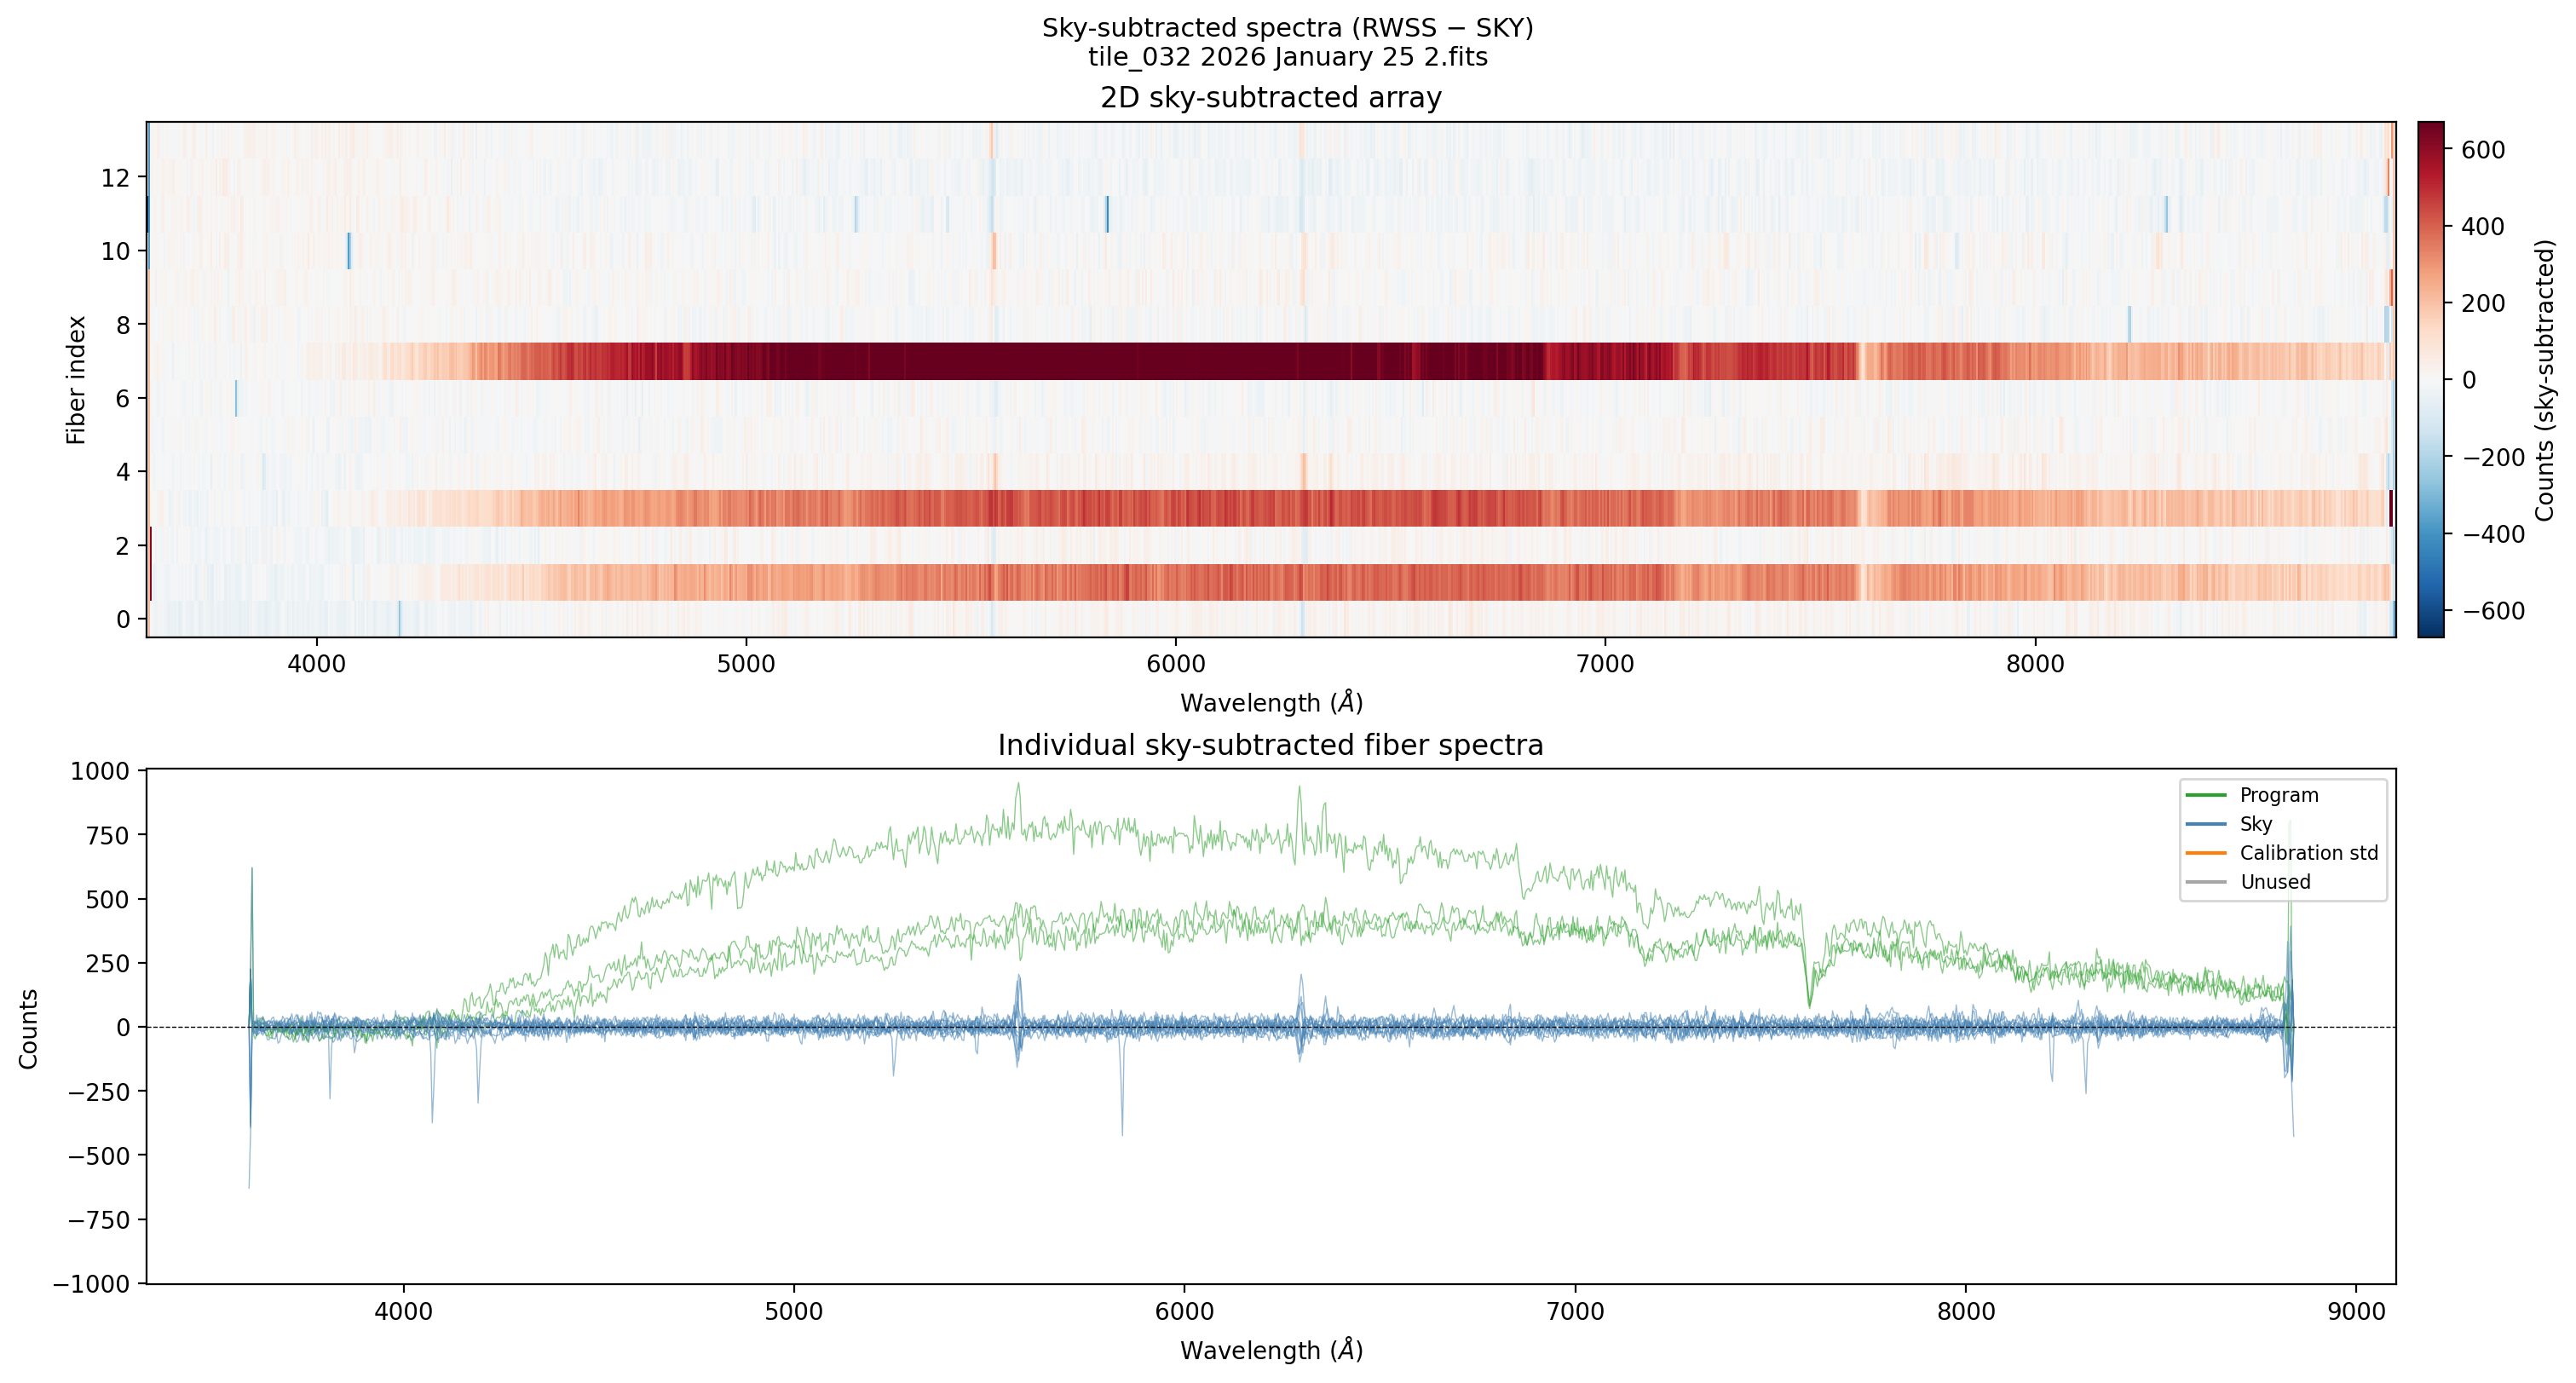

In [122]:
# ─────────────────────────────────────────────────────────────────────────────
# Sky-subtracted spectra  (RWSS − SKY, per fiber)
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[1]

with fits.open(job["red"]) as hdul:
    rwss_sk = hdul["RWSS"].data.astype(float)
    sky_sk  = hdul["SKY"].data.astype(float)

sky_sub = rwss_sk - sky_sk[np.newaxis, :]   # broadcast sky over all fibers

fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
fig.suptitle(
    f"Sky-subtracted spectra (RWSS − SKY)\n{job['raw'].name}",
    fontsize=11,
)

# — 2D image (diverging colormap centred at zero) —
ax = axes[0]
clip_val = np.nanpercentile(np.abs(sky_sub), 98)
im_plot = ax.imshow(
    sky_sub, origin="lower", aspect="auto", cmap="RdBu_r",
    vmin=-clip_val, vmax=clip_val,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D sky-subtracted array")
plt.colorbar(im_plot, ax=ax, label="Counts (sky-subtracted)", fraction=0.015, pad=0.01)

# — Individual spectra —
ax = axes[1]
for i in range(nfib):
    ftype = ftypes[i] if i < len(ftypes) else "N"
    c     = colors_by_type.get(ftype, "0.65")
    valid = np.isfinite(sky_sub[i])
    if np.sum(valid) > 10:
        ax.plot(wave[valid], sky_sub[i][valid], lw=0.5, alpha=0.55, color=c)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
ax.set_title("Individual sky-subtracted fiber spectra")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 98) * 1.5
ax.set_ylim(-ylim, ylim)
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

plt.show()

<>:114: SyntaxWarning: invalid escape sequence '\A'
<>:114: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_78211/2125920122.py:114: SyntaxWarning: invalid escape sequence '\A'
  r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \


Text(0, -0.5, '$\\bf{KSPEC \\ IsoPlane \\ Commissioning}$\n$\\bf{Instrumental \\ sky\\text{-}subtracted \\ spectrum}$\n$\\bf{Target}$: NGC 2713 (SDSS), $\\bf{RA}$:134.3354, $\\bf{Dec}$: 2.9214, $\\bf{z}$: 0.0130 (NED)\n$\\bf{Tile}$: 032, $\\bf{DATE}$: UT 2026-01-25T15:35:41, $\\bf{EXPTIME}$: 1800.0 s\n$\\bf{GRATING}$: 150, $\\bf{CENTWAVE}$: 6200.0 $\\AA$\n$\\bf{SkyMapper \\ PSF \\ magnitudes}$: $u$=16.63, $v$=16.08, $g$=13.54, $r$=12.81, $i$=12.21, $z$=11.86')

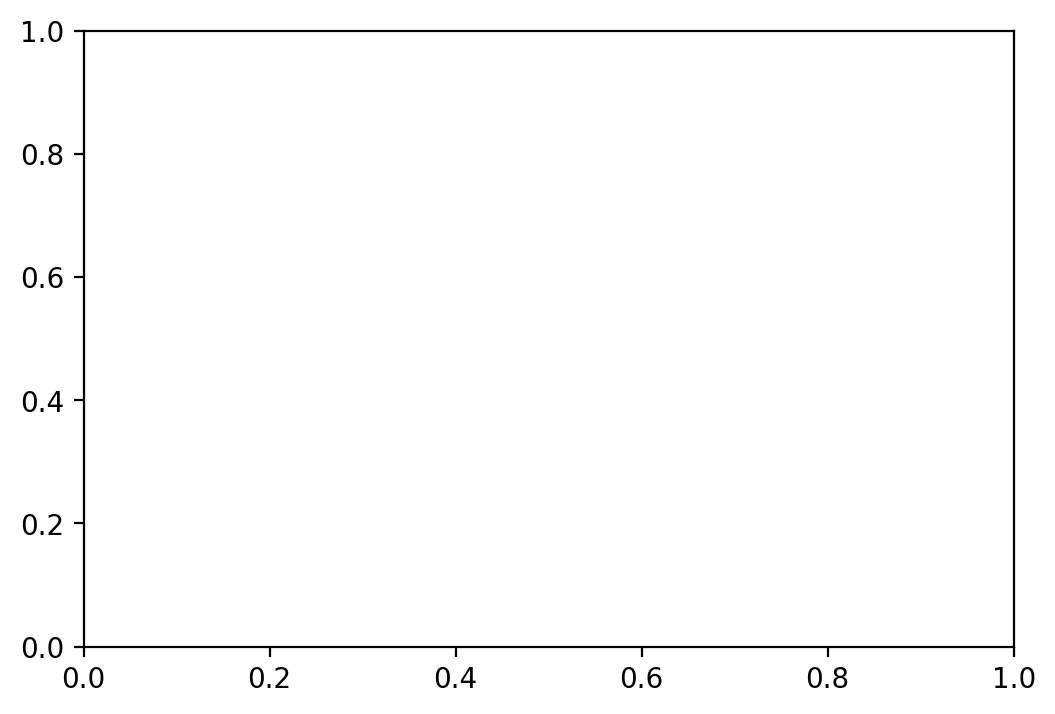

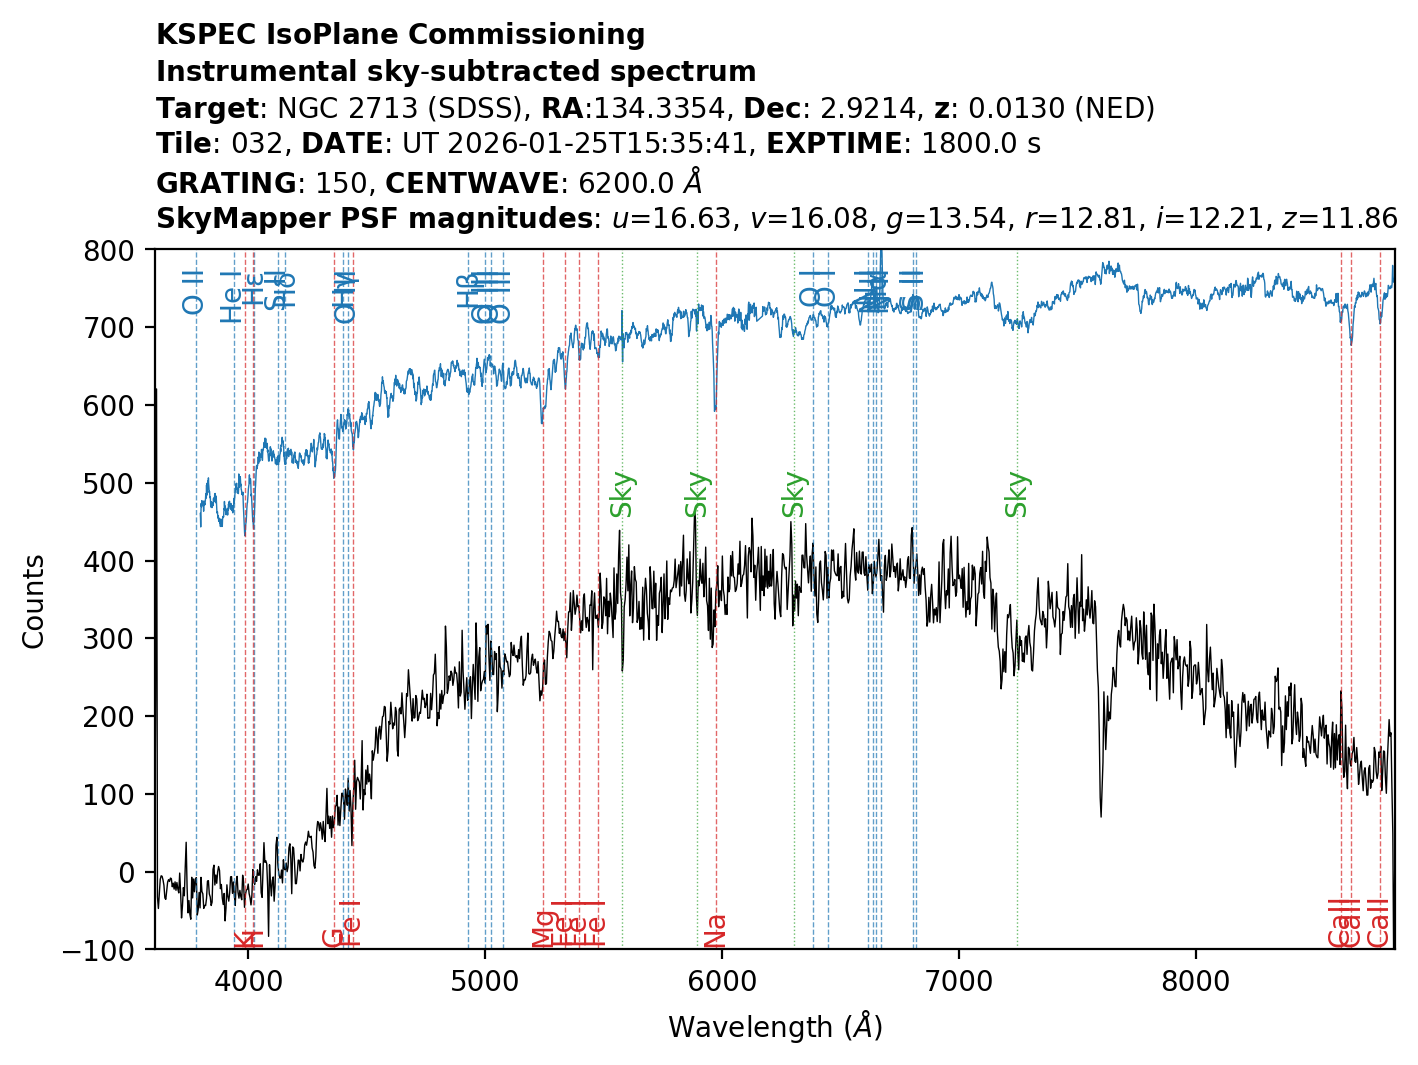

In [123]:
with fits.open(job["red"]) as hdul:
    sky_sub = hdul["PRIMARY"].data.astype(float)
    sky_sub_sig = np.sqrt(hdul["VARIANCE"].data.astype(float))
    rwss      = hdul["RWSS"].data.astype(float)
    rwss_sig  = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk    = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header

i = 1
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
valid = np.isfinite(sky_sub[i])

# # gaussian + linear fit to the sky and rwss spectrum
from scipy.optimize import curve_fit
def gaussian_linear(x, a, b, c, d, e):
    return a * np.exp(-(x - b)**2 / (2 * c**2)) + d * x + e

# skyline_window = np.where((wave > 5870) & (wave < 5920))[0]

# popt_sky, _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
#                         p0=[900, 5894, 5, 0, 300])
# popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
#                         p0=[900, 5894, 5, 0, 100])

# ww = np.linspace(wave[skyline_window][0], wave[skyline_window][-1], 1000)
# ax.plot(ww, gaussian_linear(ww, *popt_sky), color="tab:red")
# ax.plot(ww, gaussian_linear(ww, *popt_rwss), color="tab:red")
# # ax.plot(wave[skyline_window], rwss[i][skyline_window], lw=0.8, color="k", marker="o", markersize=4, label="RWSS")
# # ax.plot(wave[skyline_window], sky_sk[skyline_window], lw=0.8, color="tab:blue", marker="o", markersize=4, label="Sky")
# ax.errorbar(wave[skyline_window], sky_sk[skyline_window], yerr=sky_sk_sig[skyline_window], color="tab:blue", alpha=1, label="Sky", ls="", marker="o", markersize=4, capsize=2)
# ax.errorbar(wave[skyline_window], rwss[i][skyline_window], yerr=rwss_sig[i][skyline_window], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=4, capsize=2)
# ax.legend()

# ax.set_xlabel(r"Wavelength ($\AA$)")
# ax.set_ylabel("Counts")


# sky_sub_again = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]
# sky_sub_again_sig = np.sqrt(rwss_sig[i]**2 + (popt_rwss[0] / popt_sky[0] * sky_sk_sig)**2)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [1, 5]})
ax = axes[1]
# ax.plot(wave, sky_sub_again, lw=0.5, color="k")
ax.plot(wave, sky_sub[i], lw=0.5, color="k")
# ax.errorbar(wave, sky_sub_again, yerr=sky_sub_again_sig, color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=1, elinewidth=0.5)
# ax.errorbar(wave, sky_sub[i], yerr=sky_sub_sig[i], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=1, elinewidth=0.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
# ax.set_title("Instrumental sky-subtracted spectrum")
# ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 98) * 1.5
ax.set_ylim(-100, 800)

sdss_hdul = fits.open(TESTDIR / "spec-0565-52225-0173.fits")
sdss_spec = Table(sdss_hdul["COADD"].data)
sdss_wave = 10**(sdss_spec["loglam"])
sdss_flux = sdss_spec["flux"]

ax.plot(sdss_wave, sdss_flux+400, color="tab:blue", lw=0.5)

# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])

target_z = 0.012989

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")
    
axes[0].axis("off")
infotext = r"$\bf{KSPEC \ IsoPlane \ Commissioning}$" + \
    "\n" + r"$\bf{Instrumental \ sky\text{-}subtracted \ spectrum}$" + \
    "\n" + r"$\bf{Target}$: NGC 2713 (SDSS), " + \
    r"$\bf{RA}$:134.3354, $\bf{Dec}$: 2.9214, $\bf{z}$: "+f"{target_z:.4f} (NED)" + \
    "\n" + r"$\bf{Tile}$: 032, $\bf{DATE}$: UT "+f"{hdr['DATE']}, " + \
    r"$\bf{EXPTIME}$: "+rf"{hdr['EXPOSED']} s" + \
    "\n" + r"$\bf{GRATING}$: "+f"{hdr['GRATID']}, " + \
    r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \
    "\n" + r"$\bf{SkyMapper \ PSF \ magnitudes}$: $u$=16.63, $v$=16.08, $g$=13.54, $r$=12.81, $i$=12.21, $z$=11.86"
axes[0].text(0, -0.5, infotext, ha="left", va="bottom", transform=axes[0].transAxes)
# axes[0].text

<>:109: SyntaxWarning: invalid escape sequence '\A'
<>:109: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_78211/3703213512.py:109: SyntaxWarning: invalid escape sequence '\A'
  r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \


Text(0, -0.5, '$\\bf{KSPEC \\ IsoPlane \\ Commissioning}$\n$\\bf{Instrumental \\ sky\\text{-}subtracted \\ spectrum}$\n$\\bf{Target}$: NGC 2716 (SDSS), $\\bf{RA}$:134.3994, $\\bf{Dec}$: 3.0903, $\\bf{z}$: 0.0121 (NED)\n$\\bf{Tile}$: 032, $\\bf{DATE}$: UT 2026-01-25T15:35:41, $\\bf{EXPTIME}$: 1800.0 s\n$\\bf{GRATING}$: 150, $\\bf{CENTWAVE}$: 6200.0 $\\AA$\n$\\bf{SkyMapper \\ PSF \\ magnitudes}$: $u$=16.34, $v$=15.92, $g$=13.71, $r$=13.00, $i$=12.60, $z$=12.25')

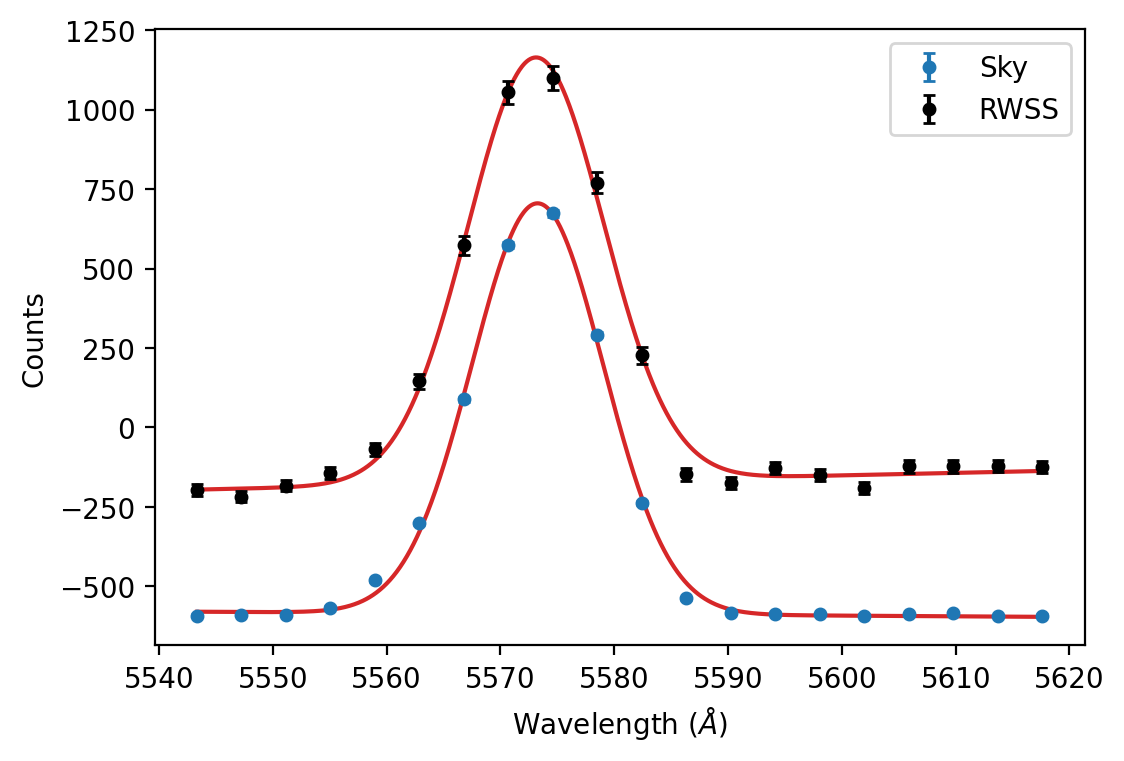

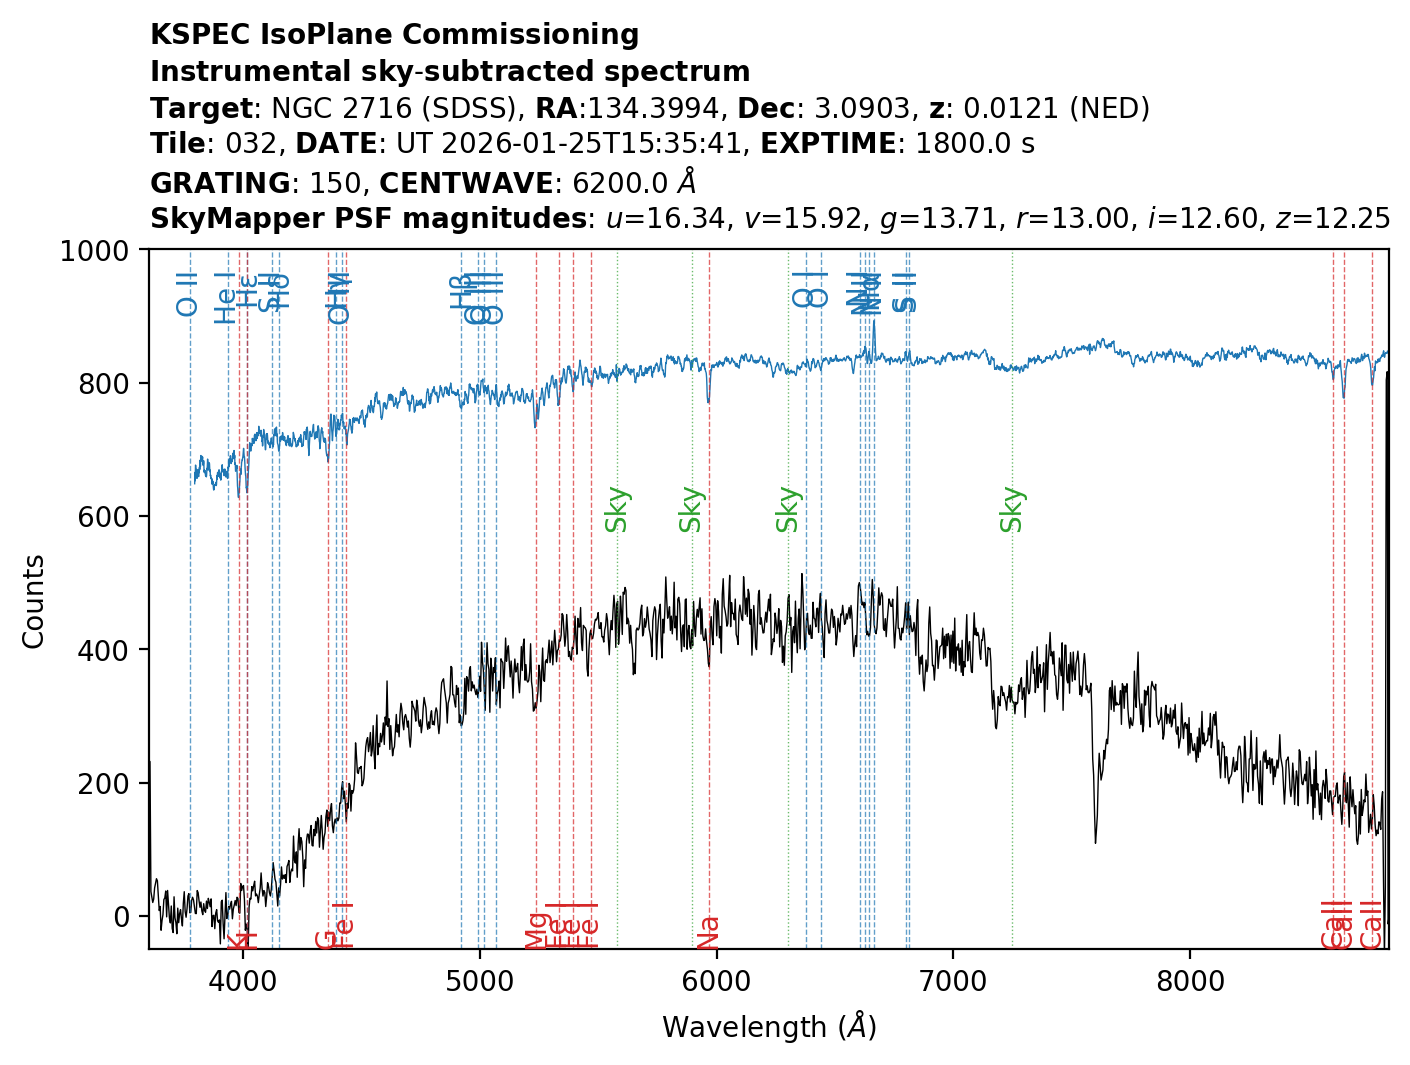

In [124]:
with fits.open(job["red"]) as hdul:
    sky_sub = hdul["PRIMARY"].data.astype(float)
    sky_sub_sig = np.sqrt(hdul["VARIANCE"].data.astype(float))
    rwss      = hdul["RWSS"].data.astype(float)
    rwss_sig  = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk    = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header

i = 3

skyline_window = np.where((wave > 5540) & (wave < 5620))[0]

popt_sky, _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                        p0=[900, 5578, 5, 0, 300])
popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                        p0=[900, 5578, 5, 0, 100])

ww = np.linspace(wave[skyline_window][0], wave[skyline_window][-1], 1000)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
valid = np.isfinite(sky_sub[i])
ax.plot(ww, gaussian_linear(ww, *popt_sky), color="tab:red")
ax.plot(ww, gaussian_linear(ww, *popt_rwss), color="tab:red")
# ax.plot(wave[skyline_window], rwss[i][skyline_window], lw=0.8, color="k", marker="o", markersize=4, label="RWSS")
# ax.plot(wave[skyline_window], sky_sk[skyline_window], lw=0.8, color="tab:blue", marker="o", markersize=4, label="Sky")
ax.errorbar(wave[skyline_window], sky_sk[skyline_window], yerr=sky_sk_sig[skyline_window], color="tab:blue", alpha=1, label="Sky", ls="", marker="o", markersize=4, capsize=2)
ax.errorbar(wave[skyline_window], rwss[i][skyline_window], yerr=rwss_sig[i][skyline_window], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=4, capsize=2)
ax.legend()

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")

sky_sub_again = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]
sky_sub_again_sig = np.sqrt(rwss_sig[i]**2 + (popt_rwss[0] / popt_sky[0] * sky_sk_sig)**2)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [1, 5]})
ax = axes[1]
# ax.plot(wave, sky_sub[i], lw=0.5, color="k")
ax.plot(wave, sky_sub_again, lw=0.5, color="k")
# ax.errorbar(wave, sky_sub[i], yerr=sky_sub_sig[i], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=1, elinewidth=0.5)
# ax.errorbar(wave, sky_sub_again, yerr=sky_sub_again_sig, color="k", alpha=1, label="Instrumental sky-subtracted", ls="", marker="o", markersize=1, elinewidth=0.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
# ax.set_title("Instrumental sky-subtracted spectrum")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.set_ylim(-50, 1000)

# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])

sdss_hdul = fits.open(TESTDIR / "spec-0565-52225-0152.fits")
sdss_spec = Table(sdss_hdul["COADD"].data)
sdss_wave = 10**(sdss_spec["loglam"])
sdss_flux = sdss_spec["flux"]

ax.plot(sdss_wave, sdss_flux+600, color="tab:blue", lw=0.5)


target_z = 0.012055

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")
    
axes[0].axis("off")
infotext = r"$\bf{KSPEC \ IsoPlane \ Commissioning}$" + \
    "\n" + r"$\bf{Instrumental \ sky\text{-}subtracted \ spectrum}$" + \
    "\n" + r"$\bf{Target}$: NGC 2716 (SDSS), " + \
    r"$\bf{RA}$:134.3994, $\bf{Dec}$: 3.0903, $\bf{z}$: "+f"{target_z:.4f} (NED)" + \
    "\n" + r"$\bf{Tile}$: 032, $\bf{DATE}$: UT "+f"{hdr['DATE']}, " + \
    r"$\bf{EXPTIME}$: "+rf"{hdr['EXPOSED']} s" + \
    "\n" + r"$\bf{GRATING}$: "+f"{hdr['GRATID']}, " + \
    r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \
    "\n" + r"$\bf{SkyMapper \ PSF \ magnitudes}$: $u$=16.34, $v$=15.92, $g$=13.71, $r$=13.00, $i$=12.60, $z$=12.25"
axes[0].text(0, -0.5, infotext, ha="left", va="bottom", transform=axes[0].transAxes)
# axes[0].text

<>:111: SyntaxWarning: invalid escape sequence '\A'
<>:111: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_78211/187129731.py:111: SyntaxWarning: invalid escape sequence '\A'
  r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \


Text(0, -0.5, '$\\bf{KSPEC \\ IsoPlane \\ Commissioning}$\n$\\bf{Instrumental \\ sky\\text{-}subtracted \\ spectrum}$\n$\\bf{Target}$: SMSS J085810.10+033827.3 (SDSS), $\\bf{RA}$:134.5421, $\\bf{Dec}$: 3.6409\n$\\bf{Tile}$: 032, $\\bf{DATE}$: UT 2026-01-25T15:35:41, $\\bf{EXPTIME}$: 1800.0 s\n$\\bf{GRATING}$: 150, $\\bf{CENTWAVE}$: 6200.0 $\\AA$\n$\\bf{SkyMapper \\ PSF \\ magnitudes}$: $u$=16.67, $v$=16.26, $g$=15.51, $r$=15.34, $i$=15.22, $z$=15.22')

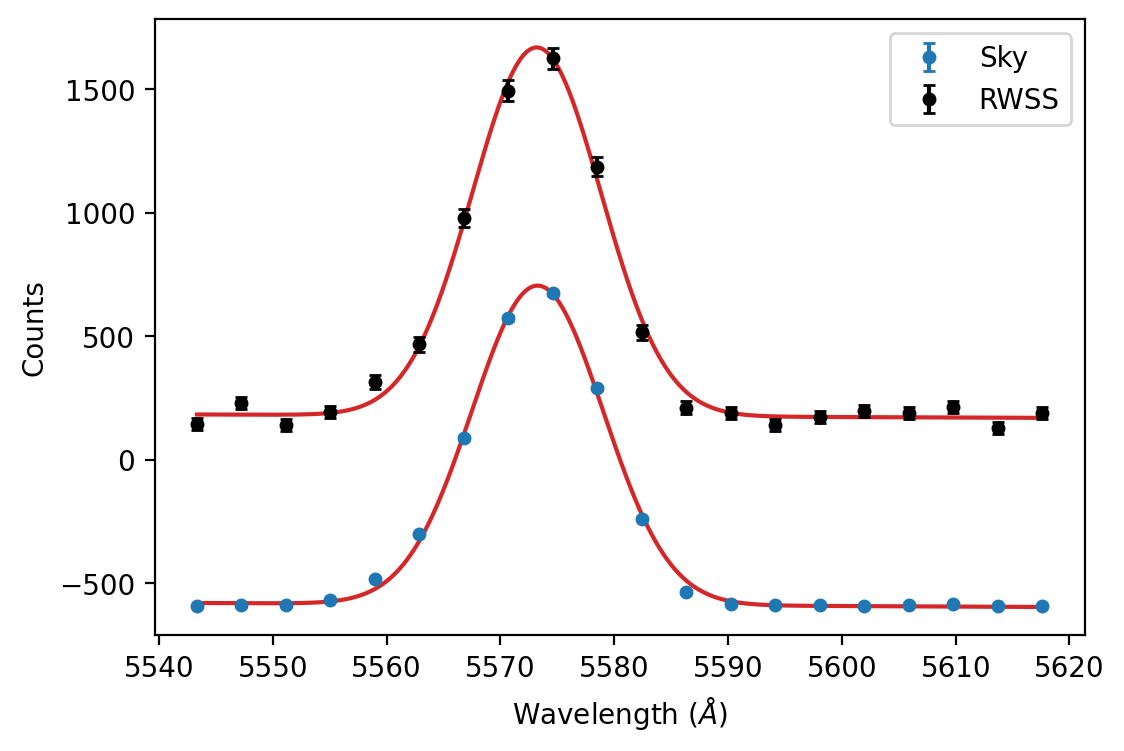

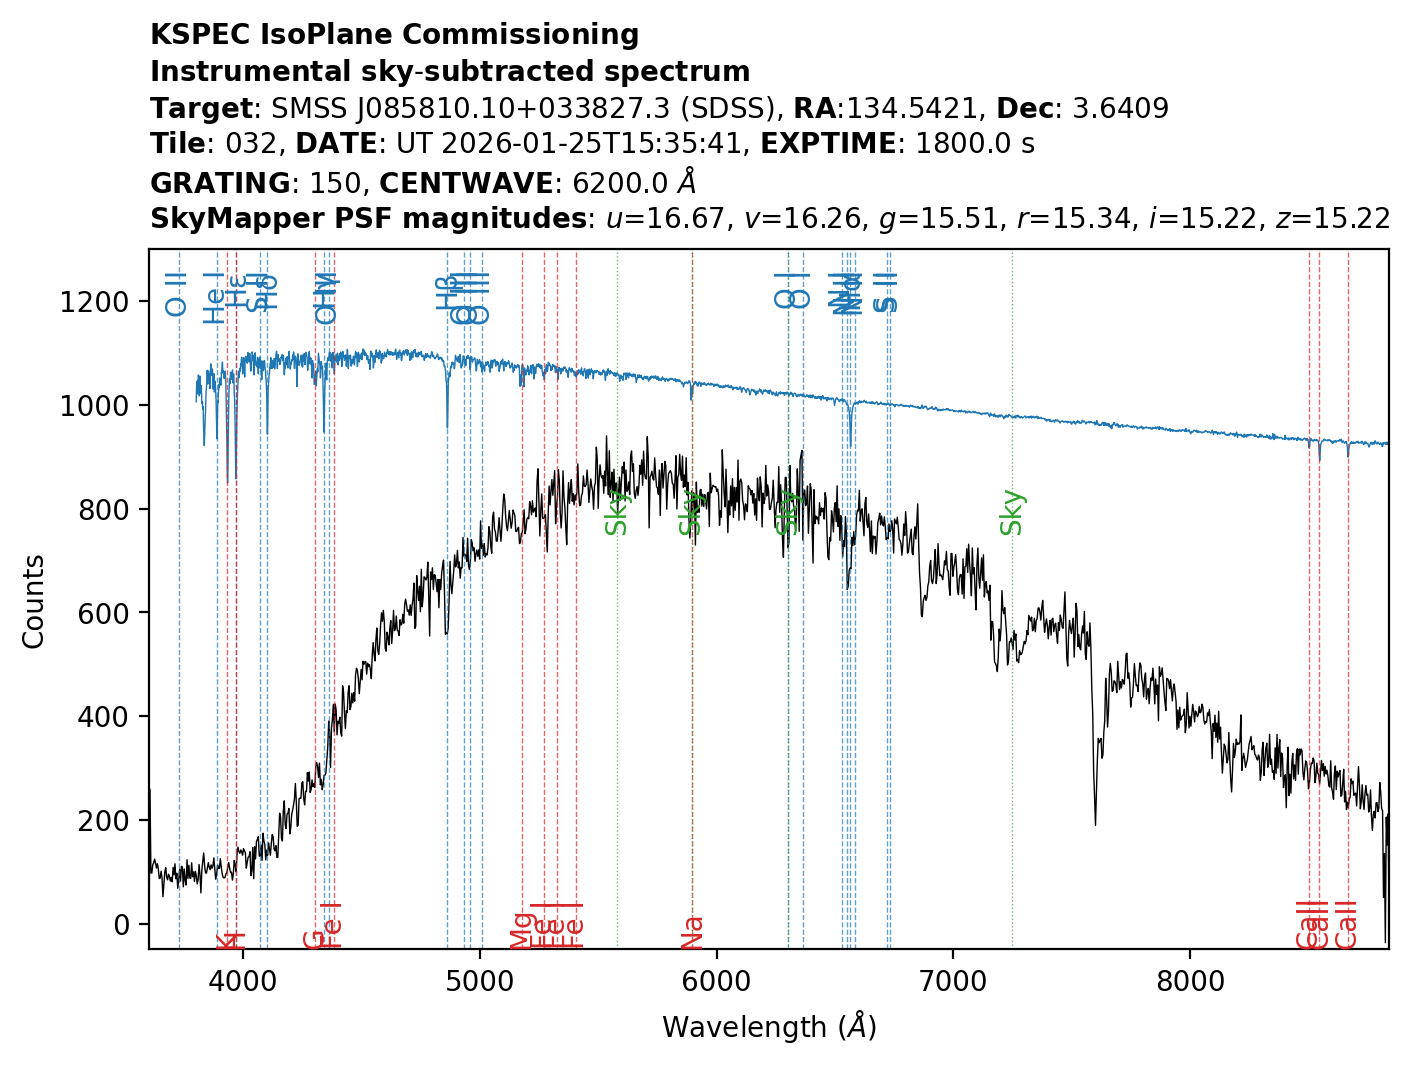

In [125]:
with fits.open(job["red"]) as hdul:
    sky_sub = hdul["PRIMARY"].data.astype(float)
    sky_sub_sig = np.sqrt(hdul["VARIANCE"].data.astype(float))
    rwss      = hdul["RWSS"].data.astype(float)
    rwss_sig  = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk    = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header


i = 7
skyline_window = np.where((wave > 5540) & (wave < 5620))[0]

popt_sky, _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                        p0=[900, 5578, 5, 0, 300])
popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                        p0=[900, 5578, 5, 0, 100])

ww = np.linspace(wave[skyline_window][0], wave[skyline_window][-1], 1000)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
valid = np.isfinite(sky_sub[i])
ax.plot(ww, gaussian_linear(ww, *popt_sky), color="tab:red")
ax.plot(ww, gaussian_linear(ww, *popt_rwss), color="tab:red")
# ax.plot(wave[skyline_window], rwss[i][skyline_window], lw=0.8, color="k", marker="o", markersize=4, label="RWSS")
# ax.plot(wave[skyline_window], sky_sk[skyline_window], lw=0.8, color="tab:blue", marker="o", markersize=4, label="Sky")
ax.errorbar(wave[skyline_window], sky_sk[skyline_window], yerr=sky_sk_sig[skyline_window], color="tab:blue", alpha=1, label="Sky", ls="", marker="o", markersize=4, capsize=2)
ax.errorbar(wave[skyline_window], rwss[i][skyline_window], yerr=rwss_sig[i][skyline_window], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=4, capsize=2)
ax.legend()

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")

sky_sub_again = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]
sky_sub_again_sig = np.sqrt(rwss_sig[i]**2 + (popt_rwss[0] / popt_sky[0] * sky_sk_sig)**2)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [1, 5]})
ax = axes[1]
ax.plot(wave, sky_sub_again, lw=0.5, color="k")
# ax.errorbar(wave, sky_sub[i], yerr=sky_sub_sig[i], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=1, elinewidth=0.5)
# ax.errorbar(wave, sky_sub_again, yerr=sky_sub_again_sig, color="k", alpha=1, label="Instrumental sky-subtracted", ls="", marker="o", markersize=1, elinewidth=0.5)
# ax.errorbar(wave, sky_sub[i], yerr=sky_sub_sig[i], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=1, elinewidth=0.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
# ax.set_title("Instrumental sky-subtracted spectrum")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.set_ylim(-50, 1300)


sdss_hdul = fits.open(TESTDIR / "spec-2888-54529-0543.fits")
sdss_spec = Table(sdss_hdul["COADD"].data)
sdss_wave = 10**(sdss_spec["loglam"])
sdss_flux = sdss_spec["flux"]

ax.plot(sdss_wave, sdss_flux+800, color="tab:blue", lw=0.5)


# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])


target_z = 0.

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")
    
axes[0].axis("off")
infotext = r"$\bf{KSPEC \ IsoPlane \ Commissioning}$" + \
    "\n" + r"$\bf{Instrumental \ sky\text{-}subtracted \ spectrum}$" + \
    "\n" + r"$\bf{Target}$: SMSS J085810.10+033827.3 (SDSS), " + \
    r"$\bf{RA}$:134.5421, $\bf{Dec}$: 3.6409" + \
    "\n" + r"$\bf{Tile}$: 032, $\bf{DATE}$: UT "+f"{hdr['DATE']}, " + \
    r"$\bf{EXPTIME}$: "+rf"{hdr['EXPOSED']} s" + \
    "\n" + r"$\bf{GRATING}$: "+f"{hdr['GRATID']}, " + \
    r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \
    "\n" + r"$\bf{SkyMapper \ PSF \ magnitudes}$: $u$=16.67, $v$=16.26, $g$=15.51, $r$=15.34, $i$=15.22, $z$=15.22"
axes[0].text(0, -0.5, infotext, ha="left", va="bottom", transform=axes[0].transAxes)
# axes[0].text




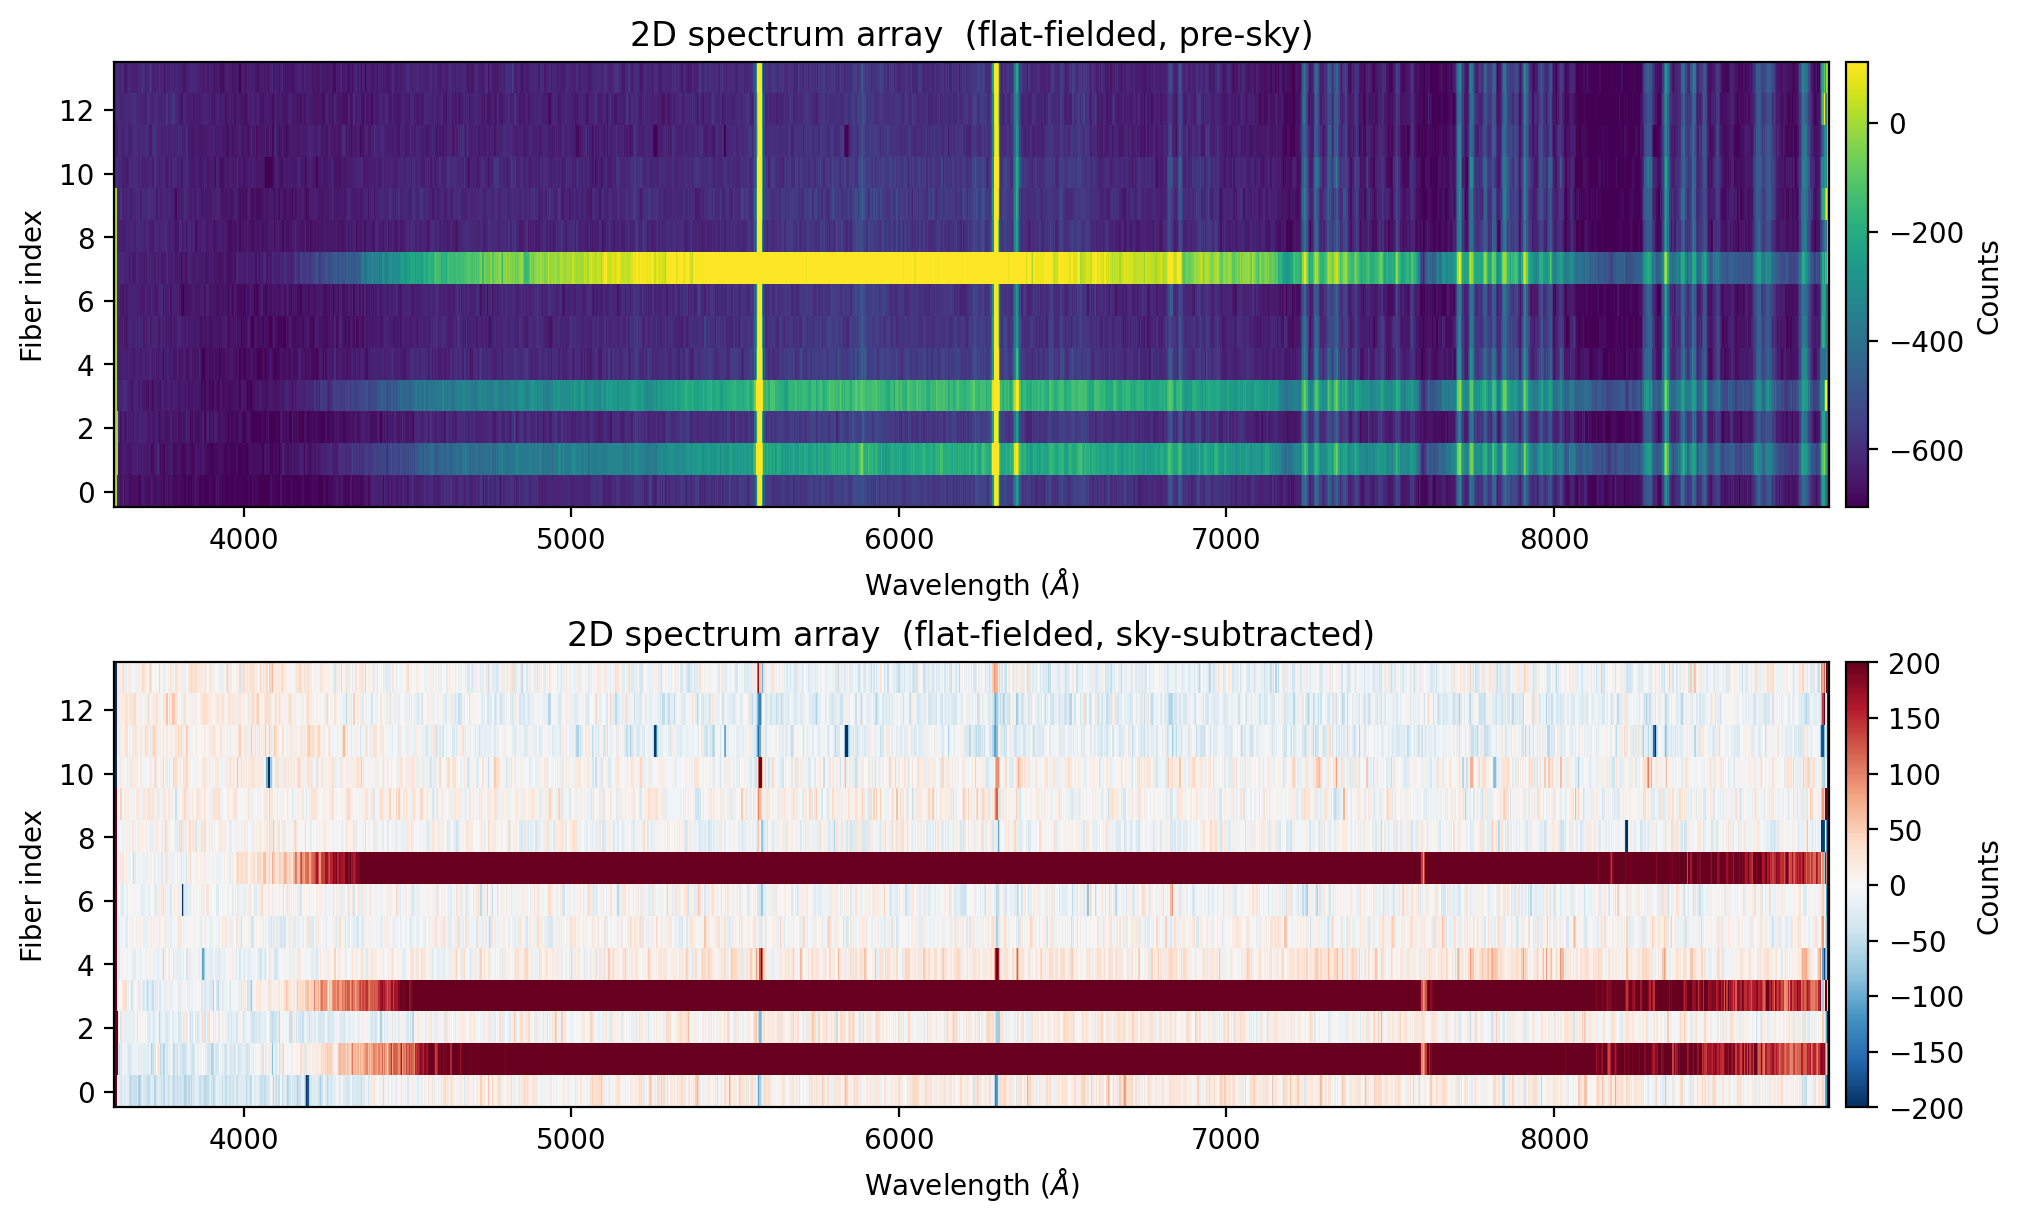

In [126]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
ax = axes[0]
vmin, vmax = np.nanpercentile(rwss, [2, 98])
im_plot = ax.imshow(
    rwss, origin="lower", aspect="auto", cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, pre-sky)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)

ax = axes[1]
vmin, vmax = -200, 200
im_plot = ax.imshow(
    sky_sub, origin="lower", aspect="auto", cmap="RdBu_r",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, sky-subtracted)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)
    
    

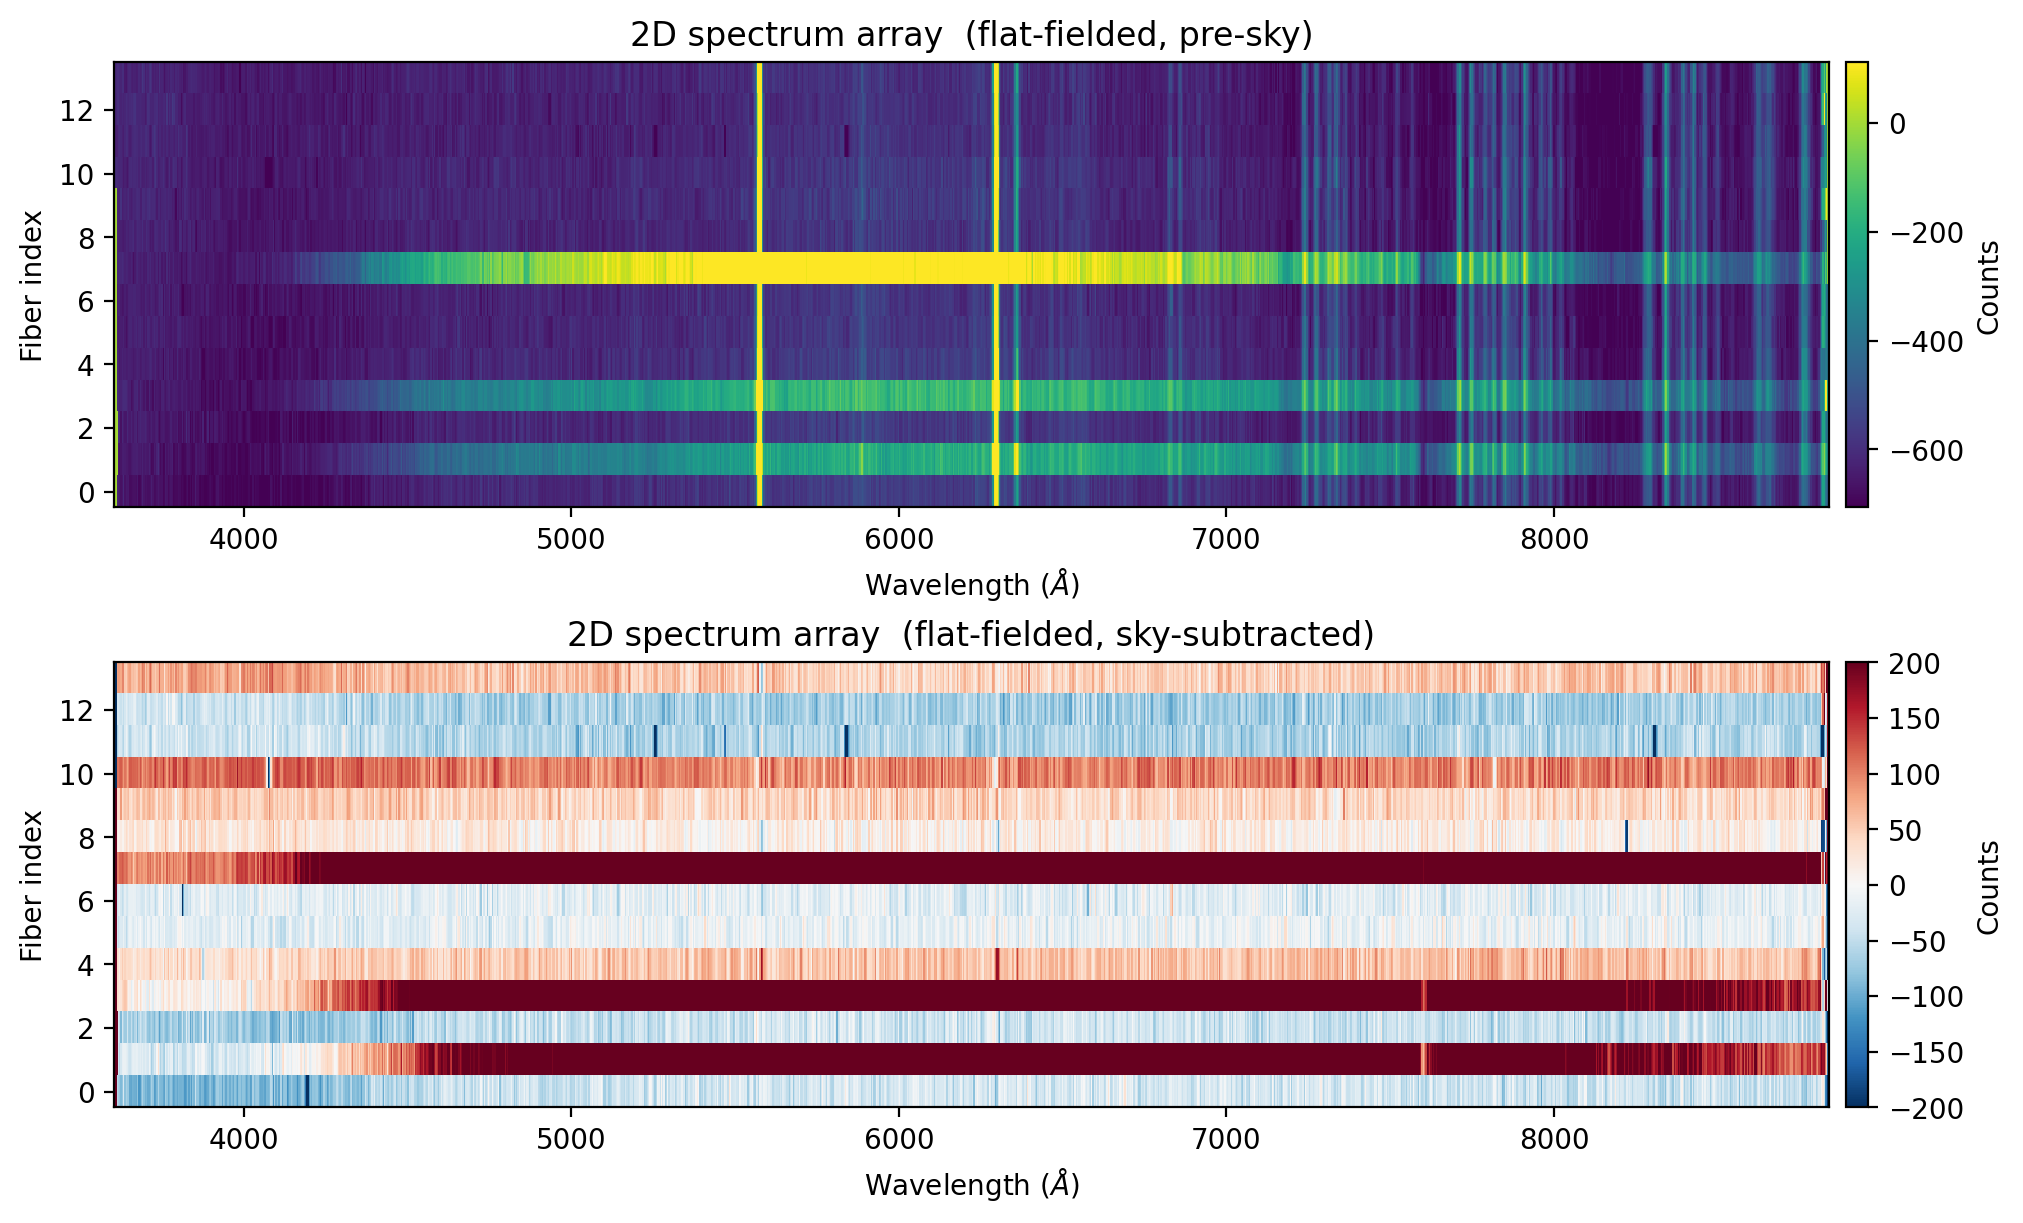

In [127]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
ax = axes[0]
vmin, vmax = np.nanpercentile(rwss, [2, 98])
im_plot = ax.imshow(
    rwss, origin="lower", aspect="auto", cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, pre-sky)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)

rwss_sksub = np.zeros_like(rwss)
for i in range(nfib):
    valid = np.isfinite(rwss[i])

    skyline_window = np.where((wave > 5540) & (wave < 5620))[0]

    popt_sky, _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                            p0=[900, 5578, 5, 0, 300])
    popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                            p0=[900, 5578, 5, 0, 100])
    
    rwss_sksub[i] = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]

ax = axes[1]
vmin, vmax = -200, 200
im_plot = ax.imshow(
    rwss_sksub, origin="lower", aspect="auto", cmap="RdBu_r",
    # rwss_sksub, origin="lower", aspect="auto", cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, sky-subtracted)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)
    
    

Median |fractional residual| (unmasked): 0.034


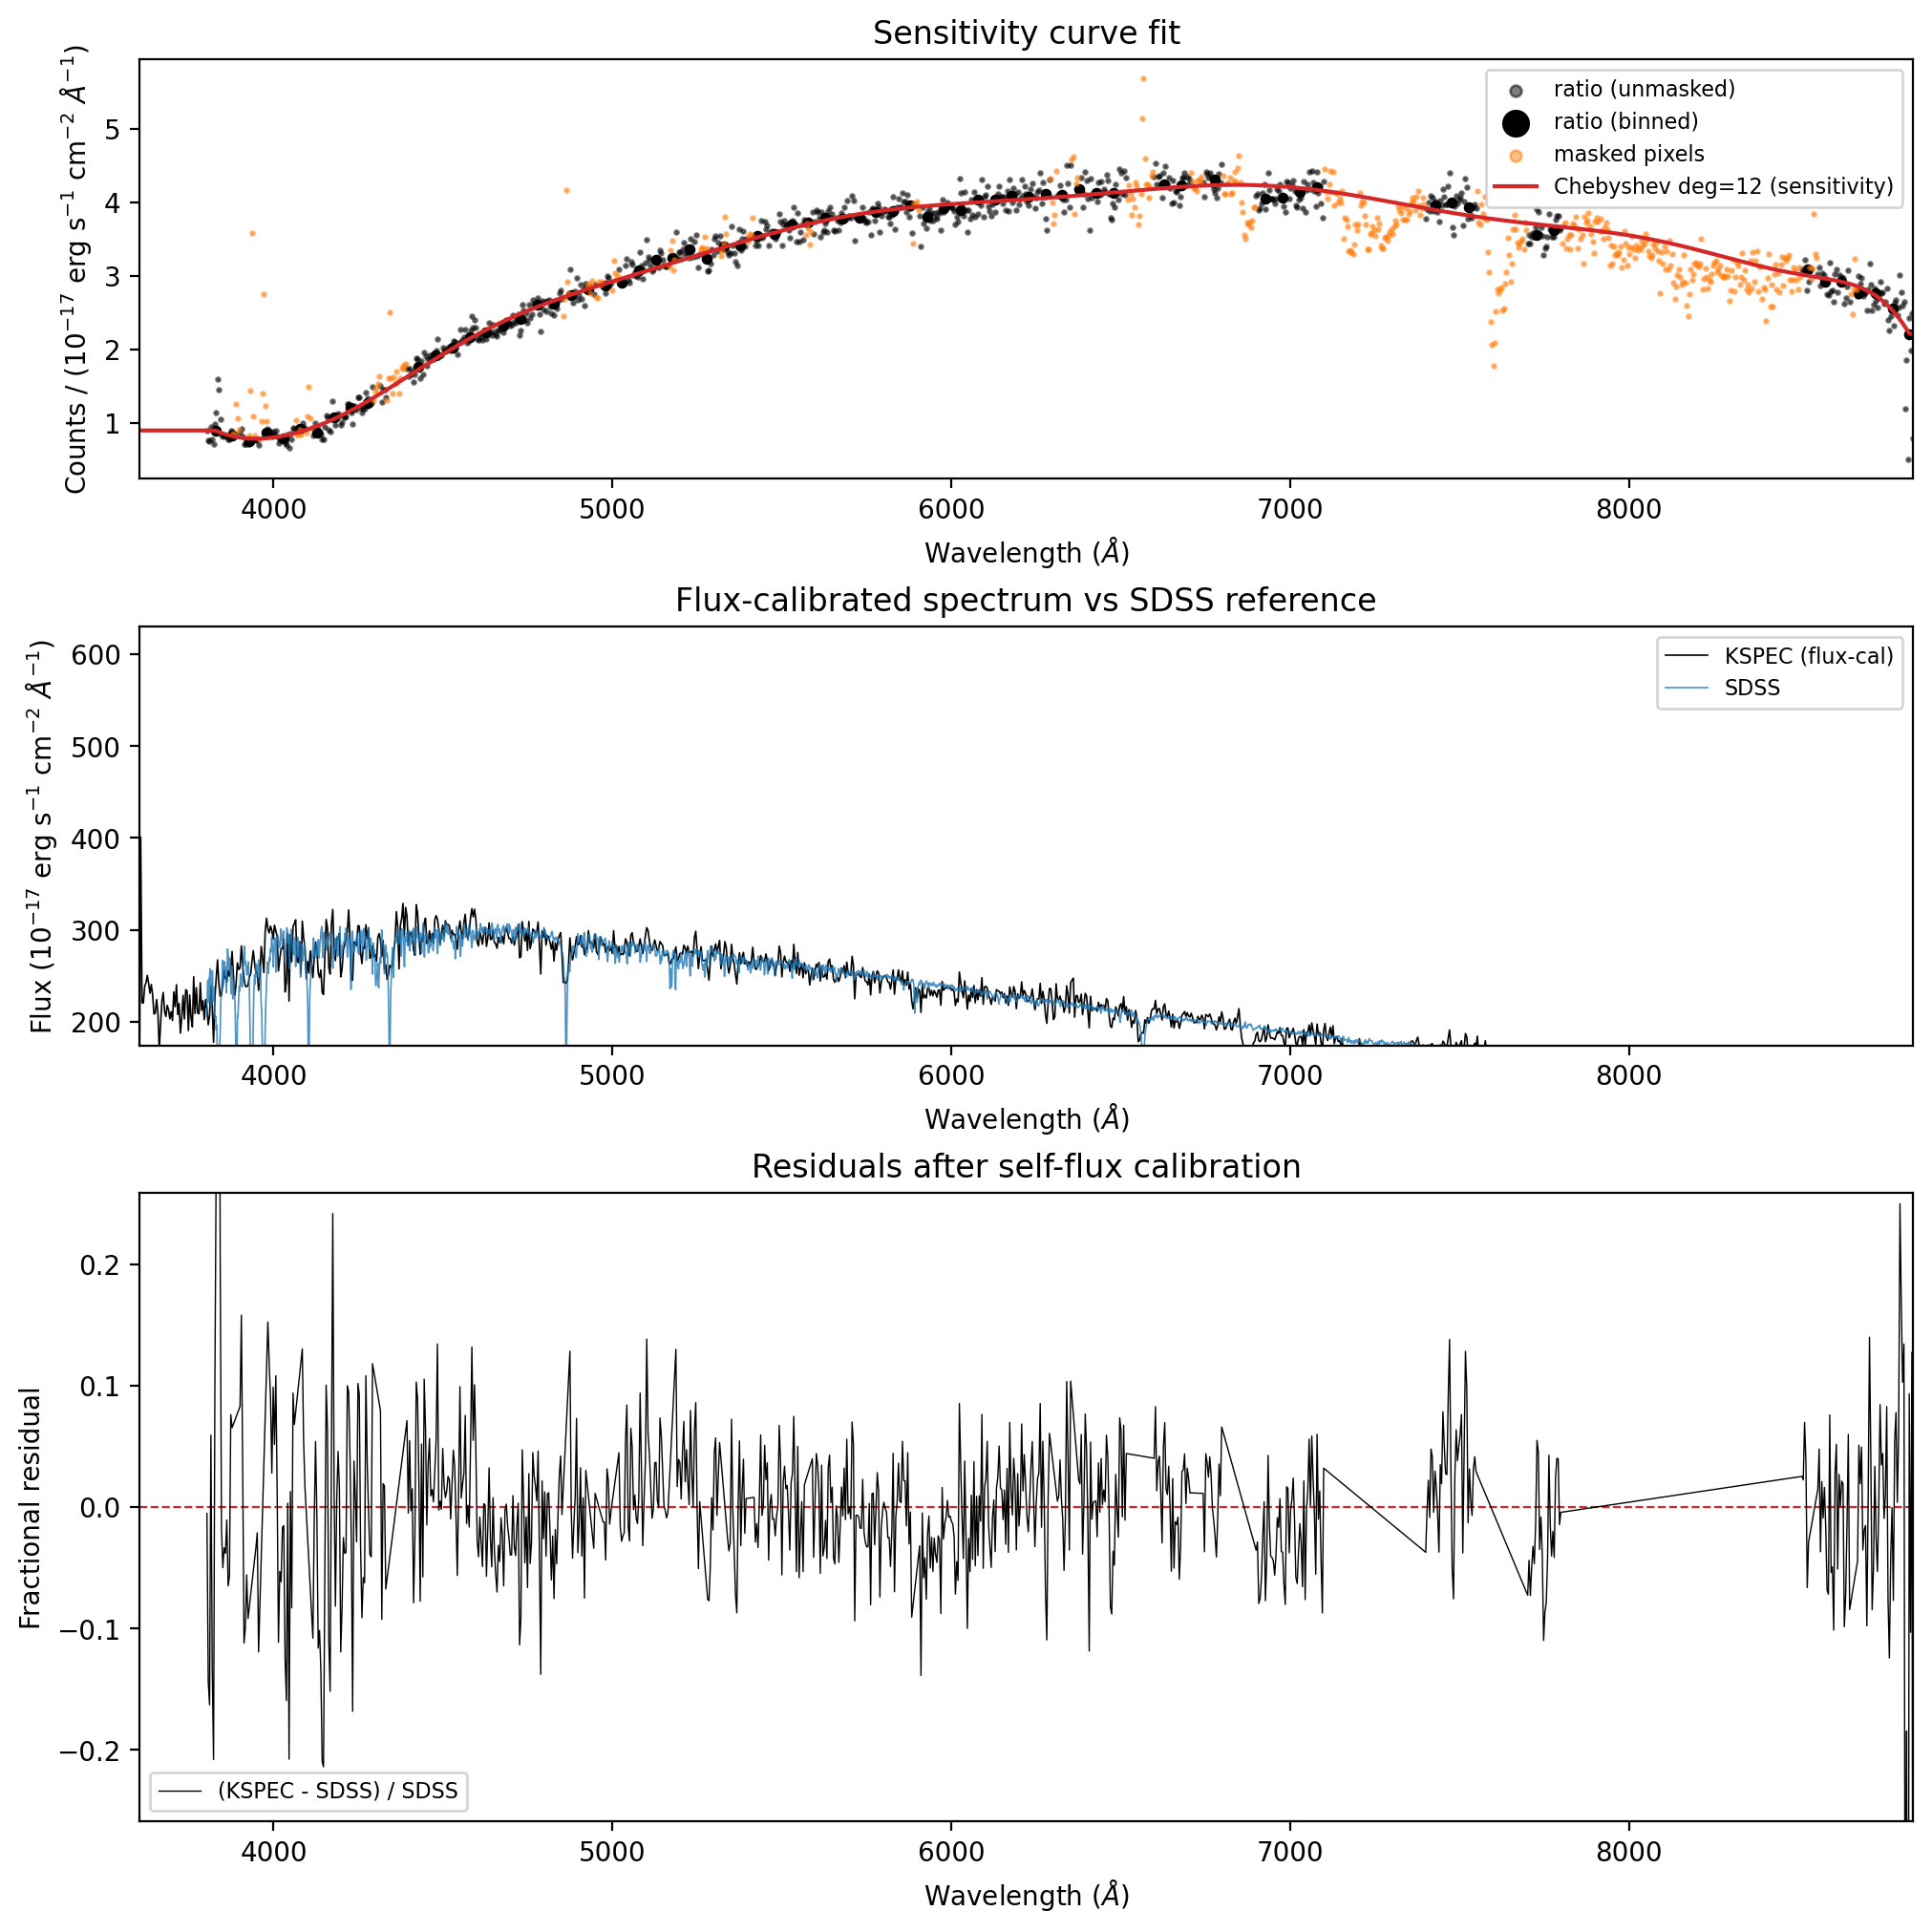

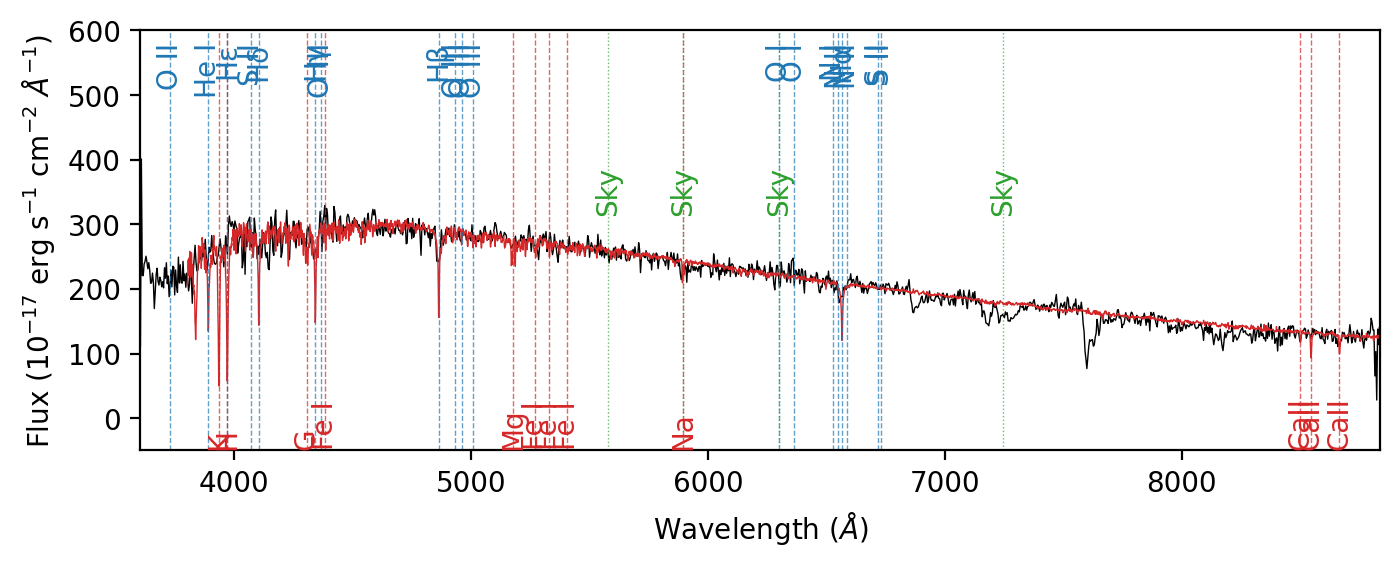

In [170]:
# ── Self-flux calibration using SDSS spectrum ──────────────────────────────
# Strategy:
#   1. Interpolate SDSS flux onto the KSPEC wavelength grid
#   2. Build a line mask (emission + absorption + sky) to exclude from the fit
#   3. Fit a smooth Chebyshev polynomial to ratio = kspec_counts / sdss_flux
#      (Chebyshev avoids the edge-ringing / curl-away of splines)
#   4. Divide KSPEC spectrum by the polynomial → flux-calibrated spectrum

# ── (Re-)load data ──────────────────────────────────────────────────────────
with fits.open(job["red"]) as hdul:
    sky_sub    = hdul["PRIMARY"].data.astype(float)
    sky_sub_sig = np.sqrt(hdul["VARIANCE"].data.astype(float))
    rwss       = hdul["RWSS"].data.astype(float)
    rwss_sig   = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk     = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header

i = 7
target_z = 0.

# Sky-subtracted KSPEC spectrum (same as cell above)
skyline_window = np.where((wave > 5540) & (wave < 5620))[0]
popt_sky,  _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                         p0=[900, 5578, 5, 0, 300])
popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                         p0=[900, 5578, 5, 0, 100])
sky_sub_again     = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0] + 100
sky_sub_again_sig = np.sqrt(rwss_sig[i]**2 + (popt_rwss[0] / popt_sky[0] * sky_sk_sig)**2)

# ── SDSS reference ──────────────────────────────────────────────────────────
sdss_hdul  = fits.open(TESTDIR / "spec-2888-54529-0543.fits")
sdss_spec  = Table(sdss_hdul["COADD"].data)
sdss_wave  = 10**(sdss_spec["loglam"])
sdss_flux  = sdss_spec["flux"]          # units: 10^{-17} erg/s/cm^2/Å

# Interpolate SDSS onto KSPEC grid (only within SDSS coverage)
sdss_interp = np.interp(wave, sdss_wave, sdss_flux, left=np.nan, right=np.nan)

# ── Line mask ───────────────────────────────────────────────────────────────
MASK_WIDTH_EMISSION = 10.   # Å
MASK_WIDTH_ABSORB   = 10.   # Å
MASK_WIDTH_SKY      = 10.   # Å

emission_lines = [
    3729.875, 3889.0, 3970.1, 4072.3, 4102.89, 4341.68, 4364.436,
    4862.68,  4932.603, 4960.295, 5008.240, 6302.046, 6365.536,
    6529.03,  6549.86, 6564.61, 6585.27, 6718.29, 6732.67,
]
absorption_lines = [
    3934.777, 3969.588, 4305.61, 5176.7, 5895.6,
    8500.36, 8544.44, 8664.52, 4383., 5270., 5328., 5406.,
]
sky_lines = [5578.5, 5894.6, 6301.7, 7246.0]

mask = np.zeros(len(wave), dtype=bool)
for wl in emission_lines:
    mask |= np.abs(wave - wl * (1 + target_z)) < MASK_WIDTH_EMISSION
for wl in absorption_lines:
    mask |= np.abs(wave - wl * (1 + target_z)) < MASK_WIDTH_ABSORB
for wl in sky_lines:
    mask |= np.abs(wave - wl) < MASK_WIDTH_SKY
    
mask |= (wave > 7800) & (wave < 8500)
mask |= (wave > 7550) & (wave < 7700)
mask |= (wave > 7100) & (wave < 7400)
mask |= (wave > 6800) & (wave < 6900)

bad = (~np.isfinite(sdss_interp)) | (sdss_interp <= 0) | (~np.isfinite(sky_sub_again))
mask |= bad
fit_mask = ~mask

# ── Compute ratio and fit Chebyshev polynomial sensitivity curve ────────────
ratio = sky_sub_again / sdss_interp          # counts / (1e-17 erg/s/cm^2/Å)

# Weights from KSPEC noise propagated through the ratio
weights = 1.0 / (sky_sub_again_sig[fit_mask] / sdss_interp[fit_mask] + 1e-10)

CHEB_DEG = 12   # polynomial degree – increase for more flexibility

# cheb_fit = np.polynomial.chebyshev.Chebyshev.fit(
#     wave[fit_mask], np.log(ratio[fit_mask]),
#     deg=CHEB_DEG,
#     w=weights,
# )
# sensitivity = np.exp(cheb_fit(wave))
# Additional edge masking
# EDGE_CLIP = 150.0
# EDGE_CLIP = 1.0
# edge_bad = (wave < wave.min() + EDGE_CLIP) | (wave > wave.max() - EDGE_CLIP)
# mask |= edge_bad
# fit_mask = ~mask

ratio = sky_sub_again / sdss_interp

# Bin the ratio to suppress pixel-scale noise
bins = np.arange(wave[fit_mask].min(), wave[fit_mask].max() + 50.0, 50.0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ratio_binned = np.full(len(bin_centers), np.nan)
weight_binned = np.full(len(bin_centers), np.nan)

for j in range(len(bin_centers)):
    inbin = (wave >= bins[j]) & (wave < bins[j+1]) & fit_mask & np.isfinite(ratio)
    if np.sum(inbin) > 5:
        ratio_binned[j] = np.nanmedian(ratio[inbin])
        # robust-ish bin weight
        sig_bin = np.nanmedian(sky_sub_again_sig[inbin] / sdss_interp[inbin])
        weight_binned[j] = 1.0 / max(sig_bin, 1e-10)

good_bin = np.isfinite(ratio_binned) & np.isfinite(weight_binned) & (ratio_binned > 0)

# Fit in log space
cheb_log_fit = np.polynomial.chebyshev.Chebyshev.fit(
    bin_centers[good_bin],
    np.log(ratio_binned[good_bin]),
    deg=CHEB_DEG,
    w=np.clip(weight_binned[good_bin],
              np.nanpercentile(weight_binned[good_bin], 5),
              np.nanpercentile(weight_binned[good_bin], 95))
)

sensitivity = np.empty_like(wave)
xfit = bin_centers[good_bin]
inside = (wave >= xfit.min()) & (wave <= xfit.max())
sensitivity[inside] = np.exp(cheb_log_fit(wave[inside]))
sensitivity[wave < xfit.min()] = np.exp(cheb_log_fit(xfit.min()))
sensitivity[wave > xfit.max()] = np.exp(cheb_log_fit(xfit.max()))
# sensitivity = np.exp(cheb_log_fit(wave))

# ── Apply calibration ───────────────────────────────────────────────────────
flux_cal     = sky_sub_again / sensitivity
flux_cal_sig = sky_sub_again_sig / sensitivity

# ── Diagnostic plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 2, 3]})

# Panel 1: ratio + Chebyshev fit
ax = axes[0]
ax.scatter(wave[fit_mask], ratio[fit_mask], s=2, c="k", alpha=0.5, label="ratio (unmasked)")
ax.scatter(bin_centers[good_bin], ratio_binned[good_bin], s=10, c="k", alpha=1, label="ratio (binned)")
ax.scatter(wave[mask & ~bad], ratio[mask & ~bad], s=2, c="tab:orange", alpha=0.5, label="masked pixels")
ax.plot(wave, sensitivity, color="tab:red", lw=1.5, label=f"Chebyshev deg={CHEB_DEG} (sensitivity)")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Counts / (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_title("Sensitivity curve fit")
ax.legend(fontsize=8, markerscale=3)
ax.set_xlim(wave[0], wave[-1])

# Panel 2: KSPEC flux-cal vs SDSS
ax = axes[1]
ax.plot(wave, flux_cal, lw=0.6, color="k", label="KSPEC (flux-cal)")
ax.plot(sdss_wave, sdss_flux, lw=0.6, color="tab:blue", alpha=0.8, label="SDSS")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_title("Flux-calibrated spectrum vs SDSS reference")
ylo, yhi = np.nanpercentile(flux_cal[fit_mask], [1, 99])
ax.set_ylim(ylo * 1.5, yhi * 2.0)
ax.set_xlim(wave[0], wave[-1])
ax.legend(fontsize=8)

# Panel 3: residuals (KSPEC - SDSS) / SDSS
ax = axes[2]
residual = (flux_cal - sdss_interp) / sdss_interp
ax.axhline(0, color="tab:red", lw=0.8, ls="--")
ax.plot(wave[fit_mask], residual[fit_mask], lw=0.5, color="k", label="(KSPEC - SDSS) / SDSS")
rlo, rhi = np.nanpercentile(residual[fit_mask], [2, 98])
ax.set_ylim(rlo * 2, rhi * 2)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fractional residual")
ax.set_title("Residuals after self-flux calibration")
ax.set_xlim(wave[0], wave[-1])
ax.legend(fontsize=8)

print(f"Median |fractional residual| (unmasked): {np.nanmedian(np.abs(residual[fit_mask])):.3f}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(2, 1, 1)
ax.plot(wave, flux_cal, lw=0.5, color="k")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.set_ylim(-50, 600)


sdss_hdul = fits.open(TESTDIR / "spec-2888-54529-0543.fits")
sdss_spec = Table(sdss_hdul["COADD"].data)
sdss_wave = 10**(sdss_spec["loglam"])
sdss_flux = sdss_spec["flux"]

ax.plot(sdss_wave, sdss_flux, color="tab:red", lw=0.5)


# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])


target_z = 0.

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")


wave_star = wave
flux_cal_star = flux_cal
sdss_wave_star = sdss_wave
sdss_flux_star = sdss_flux


Median |fractional residual| (unmasked): 0.057


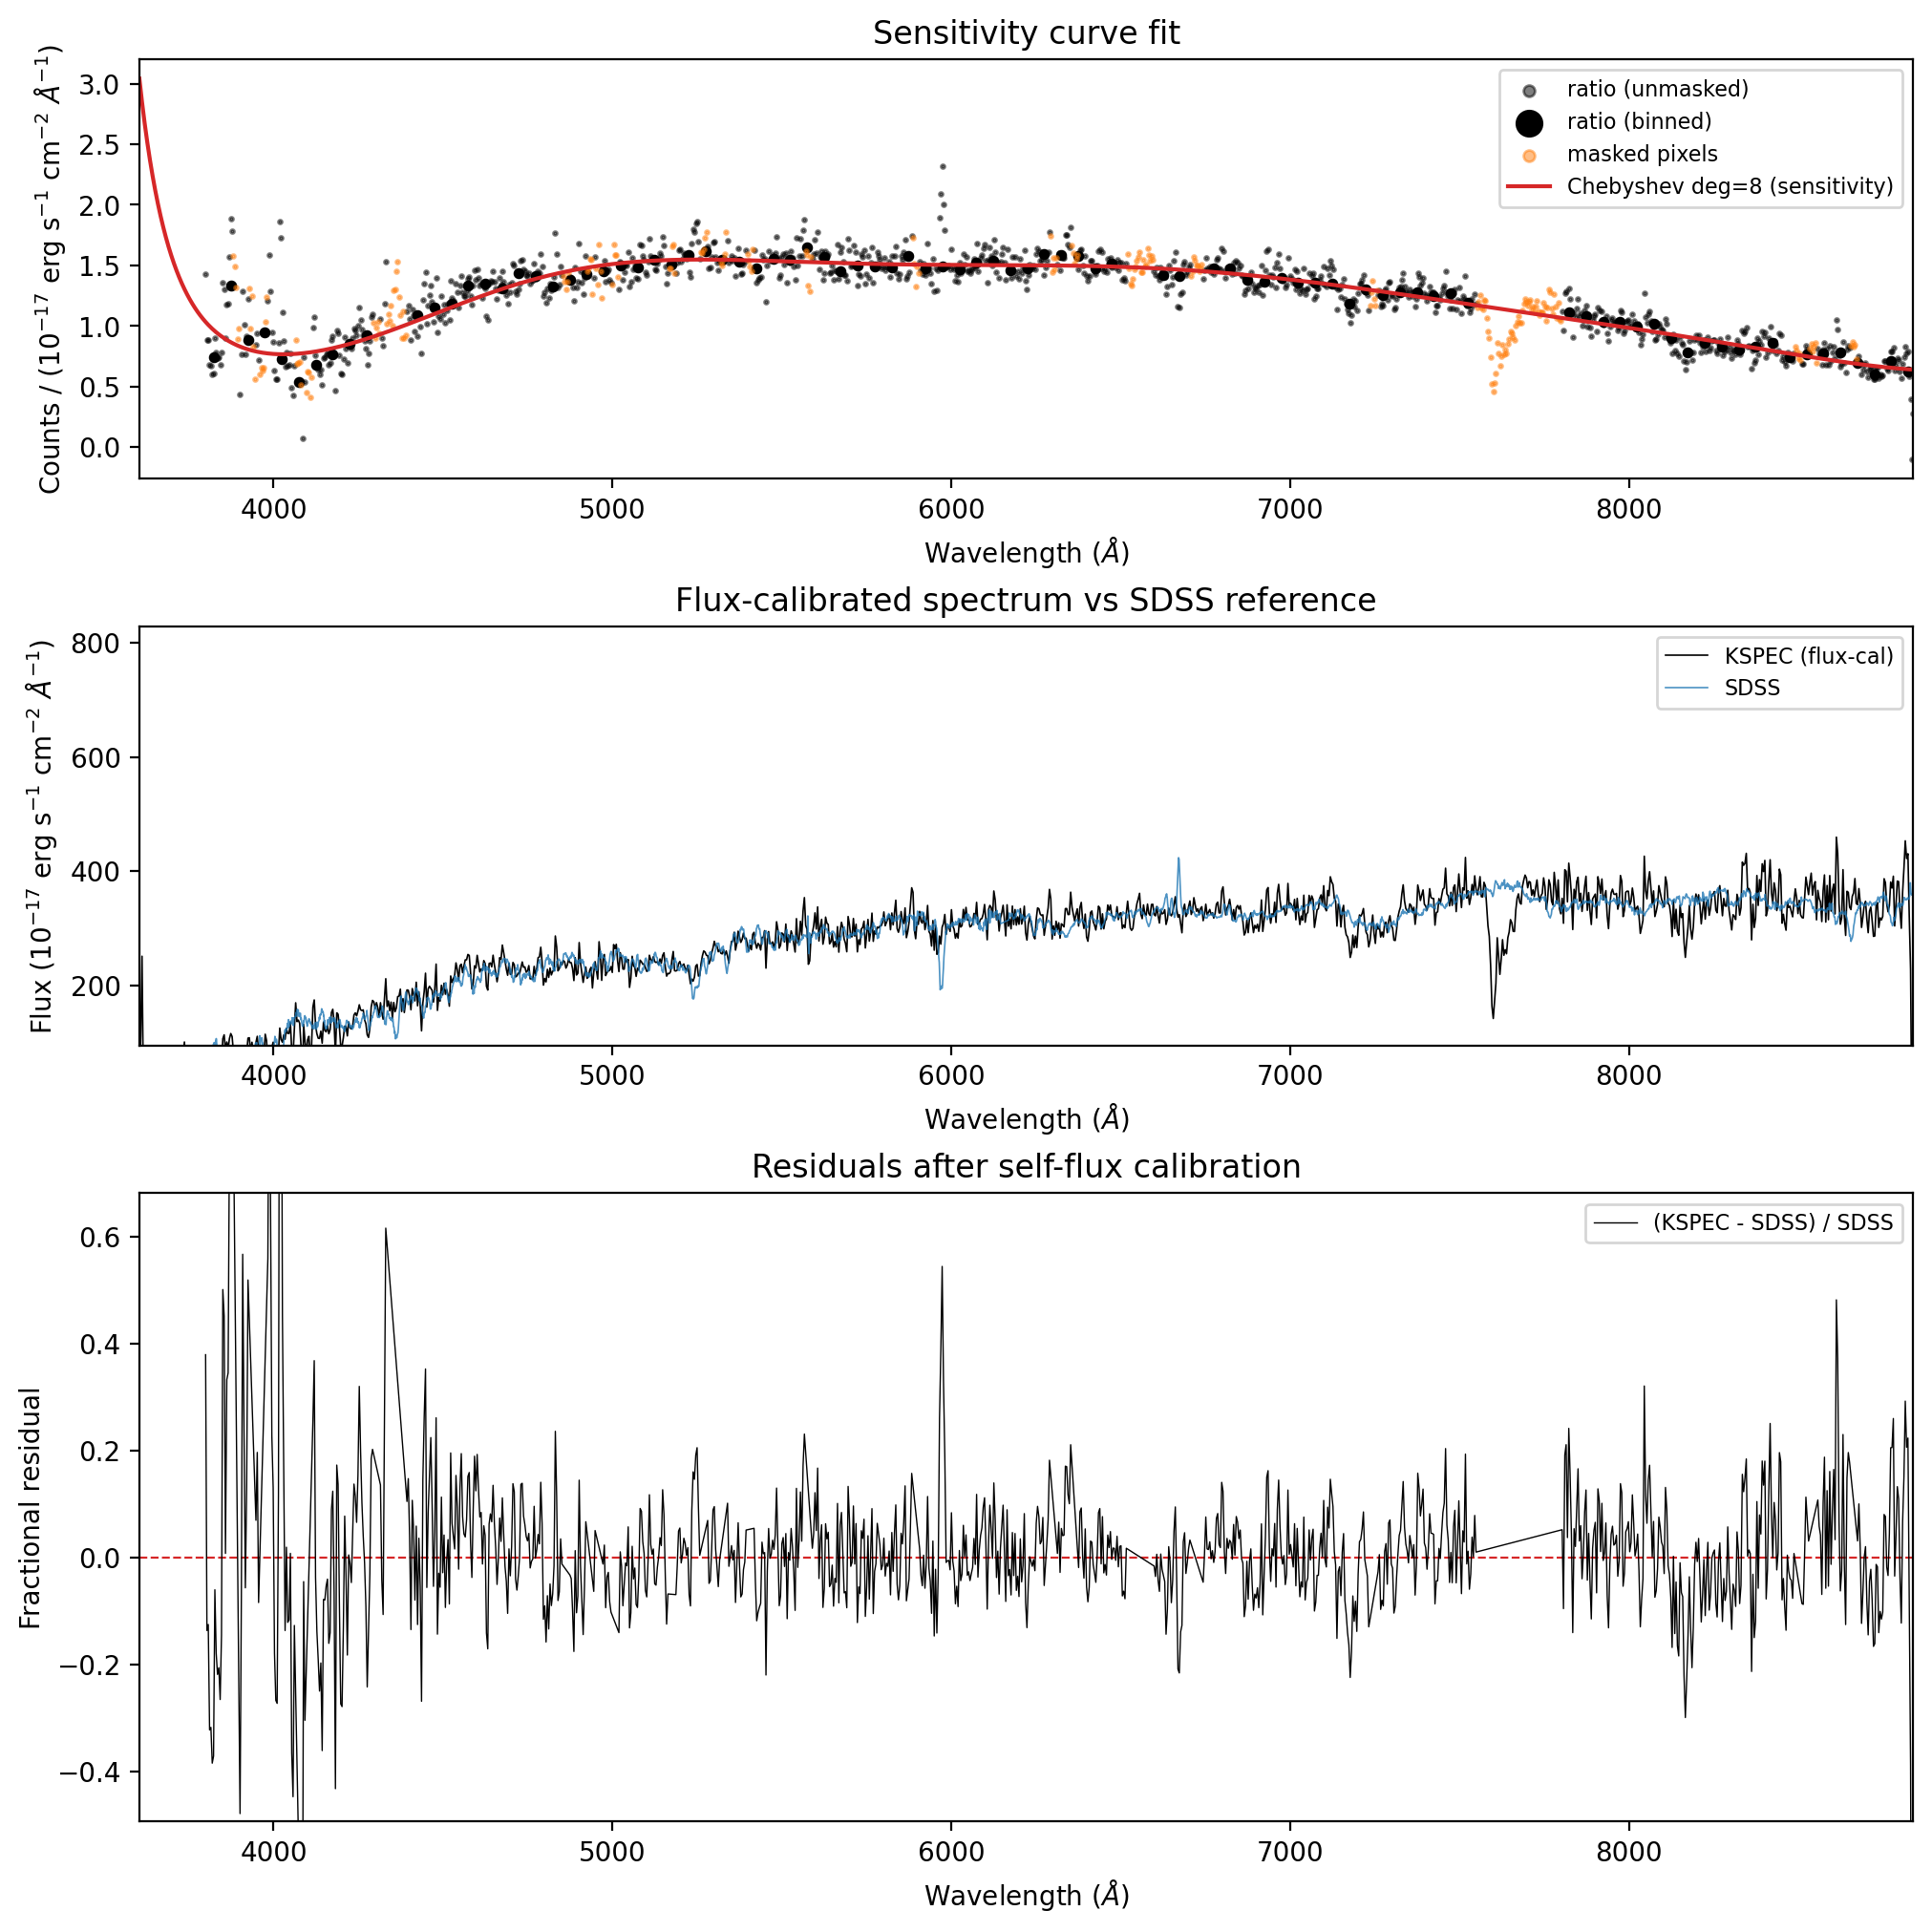

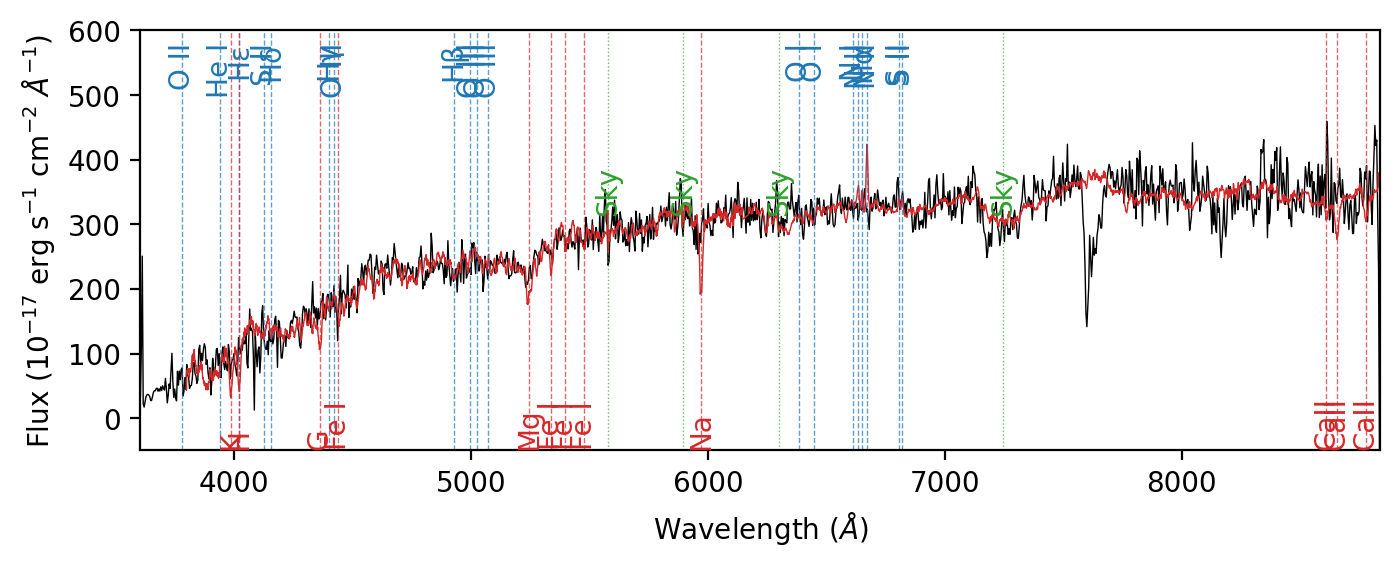

In [171]:
# ── Self-flux calibration using SDSS spectrum ──────────────────────────────
# Strategy:
#   1. Interpolate SDSS flux onto the KSPEC wavelength grid
#   2. Build a line mask (emission + absorption + sky) to exclude from the fit
#   3. Fit a smooth Chebyshev polynomial to ratio = kspec_counts / sdss_flux
#      (Chebyshev avoids the edge-ringing / curl-away of splines)
#   4. Divide KSPEC spectrum by the polynomial → flux-calibrated spectrum

# ── (Re-)load data ──────────────────────────────────────────────────────────
with fits.open(job["red"]) as hdul:
    sky_sub    = hdul["PRIMARY"].data.astype(float)
    sky_sub_sig = np.sqrt(hdul["VARIANCE"].data.astype(float))
    rwss       = hdul["RWSS"].data.astype(float)
    rwss_sig   = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk     = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header

i = 1
target_z = 0.

# Sky-subtracted KSPEC spectrum (same as cell above)
skyline_window = np.where((wave > 5540) & (wave < 5620))[0]
popt_sky,  _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                         p0=[900, 5578, 5, 0, 300])
popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                         p0=[900, 5578, 5, 0, 100])
sky_sub_again     = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0] + 100
sky_sub_again_sig = np.sqrt(rwss_sig[i]**2 + (popt_rwss[0] / popt_sky[0] * sky_sk_sig)**2)

# ── SDSS reference ──────────────────────────────────────────────────────────
sdss_hdul = fits.open(TESTDIR / "spec-0565-52225-0173.fits")
sdss_spec  = Table(sdss_hdul["COADD"].data)
sdss_wave  = 10**(sdss_spec["loglam"])
sdss_flux  = sdss_spec["flux"]          # units: 10^{-17} erg/s/cm^2/Å

# Interpolate SDSS onto KSPEC grid (only within SDSS coverage)
sdss_interp = np.interp(wave, sdss_wave, sdss_flux, left=np.nan, right=np.nan)

# ── Line mask ───────────────────────────────────────────────────────────────
MASK_WIDTH_EMISSION = 10.   # Å
MASK_WIDTH_ABSORB   = 10.   # Å
MASK_WIDTH_SKY      = 10.   # Å

emission_lines = [
    3729.875, 3889.0, 3970.1, 4072.3, 4102.89, 4341.68, 4364.436,
    4862.68,  4932.603, 4960.295, 5008.240, 6302.046, 6365.536,
    6529.03,  6549.86, 6564.61, 6585.27, 6718.29, 6732.67,
]
absorption_lines = [
    3934.777, 3969.588, 4305.61, 5176.7, 5895.6,
    8500.36, 8544.44, 8664.52, 4383., 5270., 5328., 5406.,
]
sky_lines = [5578.5, 5894.6, 6301.7, 7246.0]

mask = np.zeros(len(wave), dtype=bool)
for wl in emission_lines:
    mask |= np.abs(wave - wl * (1 + target_z)) < MASK_WIDTH_EMISSION
for wl in absorption_lines:
    mask |= np.abs(wave - wl * (1 + target_z)) < MASK_WIDTH_ABSORB
for wl in sky_lines:
    mask |= np.abs(wave - wl) < MASK_WIDTH_SKY
        
mask |= (wave > 7550) & (wave < 7800)

bad = (~np.isfinite(sdss_interp)) | (sdss_interp <= 0) | (~np.isfinite(sky_sub_again))
mask |= bad
fit_mask = ~mask

# ── Compute ratio and fit Chebyshev polynomial sensitivity curve ────────────
ratio = sky_sub_again / sdss_interp          # counts / (1e-17 erg/s/cm^2/Å)

# Weights from KSPEC noise propagated through the ratio
weights = 1.0 / (sky_sub_again_sig[fit_mask] / sdss_interp[fit_mask] + 1e-10)

CHEB_DEG = 8   # polynomial degree – increase for more flexibility

# cheb_fit = np.polynomial.chebyshev.Chebyshev.fit(
#     wave[fit_mask], ratio[fit_mask],
#     deg=CHEB_DEG,
#     w=weights,
# )
# sensitivity = cheb_fit(wave)
# Additional edge masking
# EDGE_CLIP = 150.0
# EDGE_CLIP = 1.0
# edge_bad = (wave < wave.min() + EDGE_CLIP) | (wave > wave.max() - EDGE_CLIP)
# mask |= edge_bad
# fit_mask = ~mask

ratio = sky_sub_again / sdss_interp

# Bin the ratio to suppress pixel-scale noise
bins = np.arange(wave[fit_mask].min(), wave[fit_mask].max() + 50.0, 50.0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ratio_binned = np.full(len(bin_centers), np.nan)
weight_binned = np.full(len(bin_centers), np.nan)

for j in range(len(bin_centers)):
    inbin = (wave >= bins[j]) & (wave < bins[j+1]) & fit_mask & np.isfinite(ratio)
    if np.sum(inbin) > 5:
        ratio_binned[j] = np.nanmedian(ratio[inbin])
        # robust-ish bin weight
        sig_bin = np.nanmedian(sky_sub_again_sig[inbin] / sdss_interp[inbin])
        weight_binned[j] = 1.0 / max(sig_bin, 1e-10)

good_bin = np.isfinite(ratio_binned) & np.isfinite(weight_binned) & (ratio_binned > 0)

# Fit in log space
cheb_log_fit = np.polynomial.chebyshev.Chebyshev.fit(
    bin_centers[good_bin],
    np.log(ratio_binned[good_bin]),
    deg=CHEB_DEG,
    w=np.clip(weight_binned[good_bin],
              np.nanpercentile(weight_binned[good_bin], 5),
              np.nanpercentile(weight_binned[good_bin], 95))
)

sensitivity = np.empty_like(wave)
xfit = bin_centers[good_bin]
# inside = (wave >= xfit.min()) & (wave <= xfit.max())
# sensitivity[inside] = np.exp(cheb_log_fit(wave[inside]))
# sensitivity[wave < xfit.min()] = np.exp(cheb_log_fit(xfit.min()))
# sensitivity[wave > xfit.max()] = np.exp(cheb_log_fit(xfit.max()))
sensitivity = np.exp(cheb_log_fit(wave))

# ── Apply calibration ───────────────────────────────────────────────────────
flux_cal     = sky_sub_again / sensitivity
flux_cal_sig = sky_sub_again_sig / sensitivity

# ── Diagnostic plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 2, 3]})

# Panel 1: ratio + Chebyshev fit
ax = axes[0]
ax.scatter(wave[fit_mask], ratio[fit_mask], s=2, c="k", alpha=0.5, label="ratio (unmasked)")
ax.scatter(bin_centers[good_bin], ratio_binned[good_bin], s=10, c="k", alpha=1, label="ratio (binned)")
ax.scatter(wave[mask & ~bad], ratio[mask & ~bad], s=2, c="tab:orange", alpha=0.5, label="masked pixels")
ax.plot(wave, sensitivity, color="tab:red", lw=1.5, label=f"Chebyshev deg={CHEB_DEG} (sensitivity)")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Counts / (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_title("Sensitivity curve fit")
ax.legend(fontsize=8, markerscale=3)
ax.set_xlim(wave[0], wave[-1])

# Panel 2: KSPEC flux-cal vs SDSS
ax = axes[1]
ax.plot(wave, flux_cal, lw=0.6, color="k", label="KSPEC (flux-cal)")
ax.plot(sdss_wave, sdss_flux, lw=0.6, color="tab:blue", alpha=0.8, label="SDSS")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_title("Flux-calibrated spectrum vs SDSS reference")
ylo, yhi = np.nanpercentile(flux_cal[fit_mask], [1, 99])
ax.set_ylim(ylo * 1.5, yhi * 2.0)
ax.set_xlim(wave[0], wave[-1])
ax.legend(fontsize=8)

# Panel 3: residuals (KSPEC - SDSS) / SDSS
ax = axes[2]
residual = (flux_cal - sdss_interp) / sdss_interp
ax.axhline(0, color="tab:red", lw=0.8, ls="--")
ax.plot(wave[fit_mask], residual[fit_mask], lw=0.5, color="k", label="(KSPEC - SDSS) / SDSS")
rlo, rhi = np.nanpercentile(residual[fit_mask], [2, 98])
ax.set_ylim(rlo * 2, rhi * 2)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fractional residual")
ax.set_title("Residuals after self-flux calibration")
ax.set_xlim(wave[0], wave[-1])
ax.legend(fontsize=8)

print(f"Median |fractional residual| (unmasked): {np.nanmedian(np.abs(residual[fit_mask])):.3f}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(2, 1, 1)
ax.plot(wave, flux_cal, lw=0.5, color="k")
ax.plot(sdss_wave, sdss_flux, color="tab:red", lw=0.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.set_ylim(-50, 600)



# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])


target_z = 0.012989

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")
        
wave_gal = wave
flux_gal = flux_cal
sdss_wave_gal = sdss_wave
sdss_flux_gal = sdss_flux

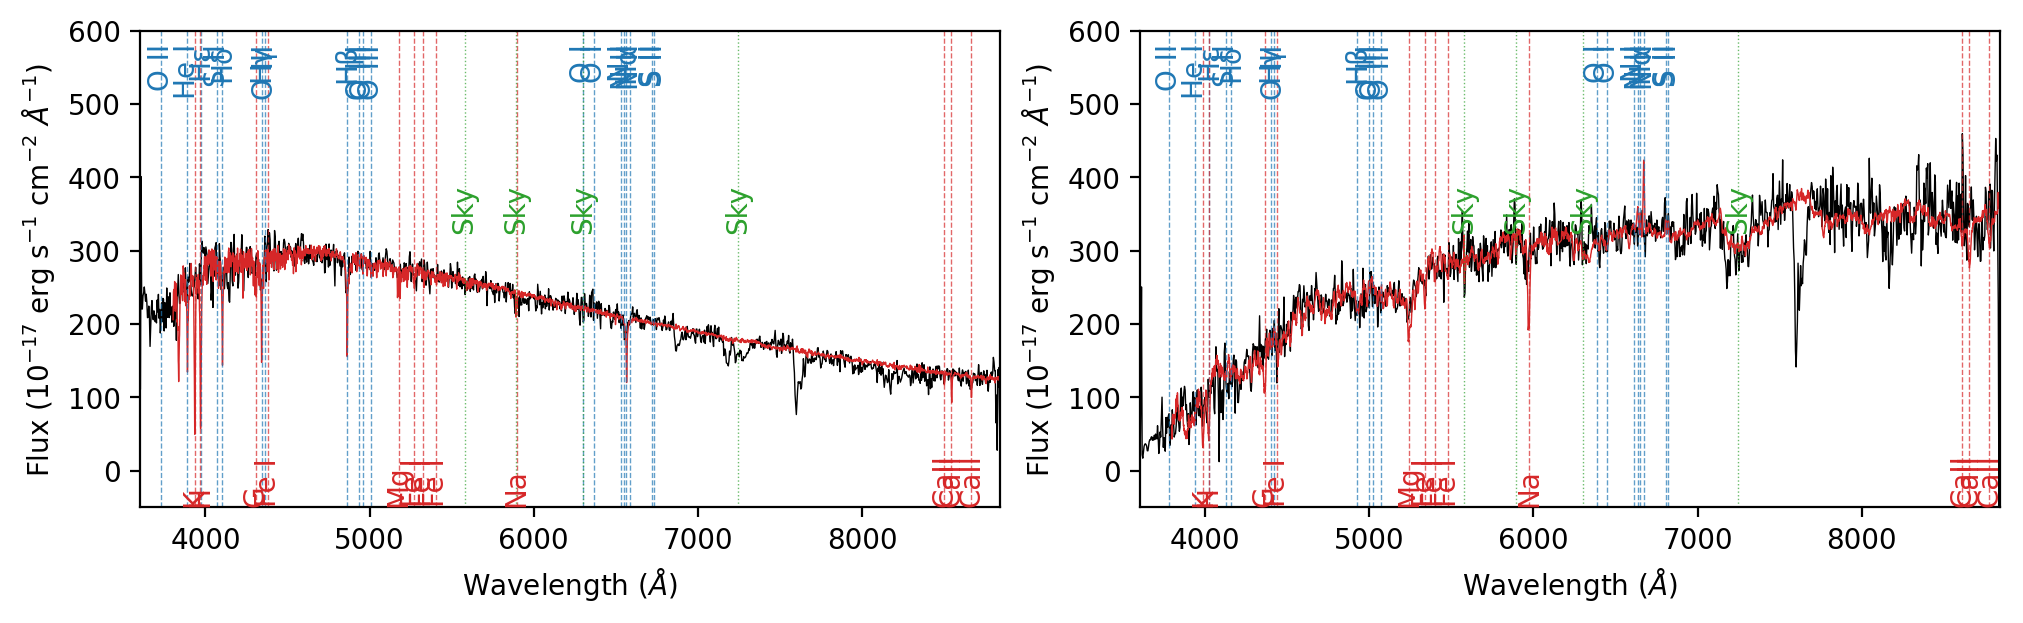

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
ax = axes[0]
wave = wave_star
ax.plot(wave_star, flux_cal_star, lw=0.5, color="k")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.plot(sdss_wave_star, sdss_flux_star, color="tab:red", lw=0.5)
ax.set_ylim(-50, 600)

# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])


target_z = 0.

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")

ax = axes[1]
wave = wave_gal
ax.plot(wave_gal, flux_gal, lw=0.5, color="k")
ax.plot(sdss_wave_gal, sdss_flux_gal, color="tab:red", lw=0.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.set_xlim(wave[0], wave[-1])
ax.set_ylim(-50, 600)
target_z = 0.012989

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")

Median |fractional residual| (unmasked): 0.062


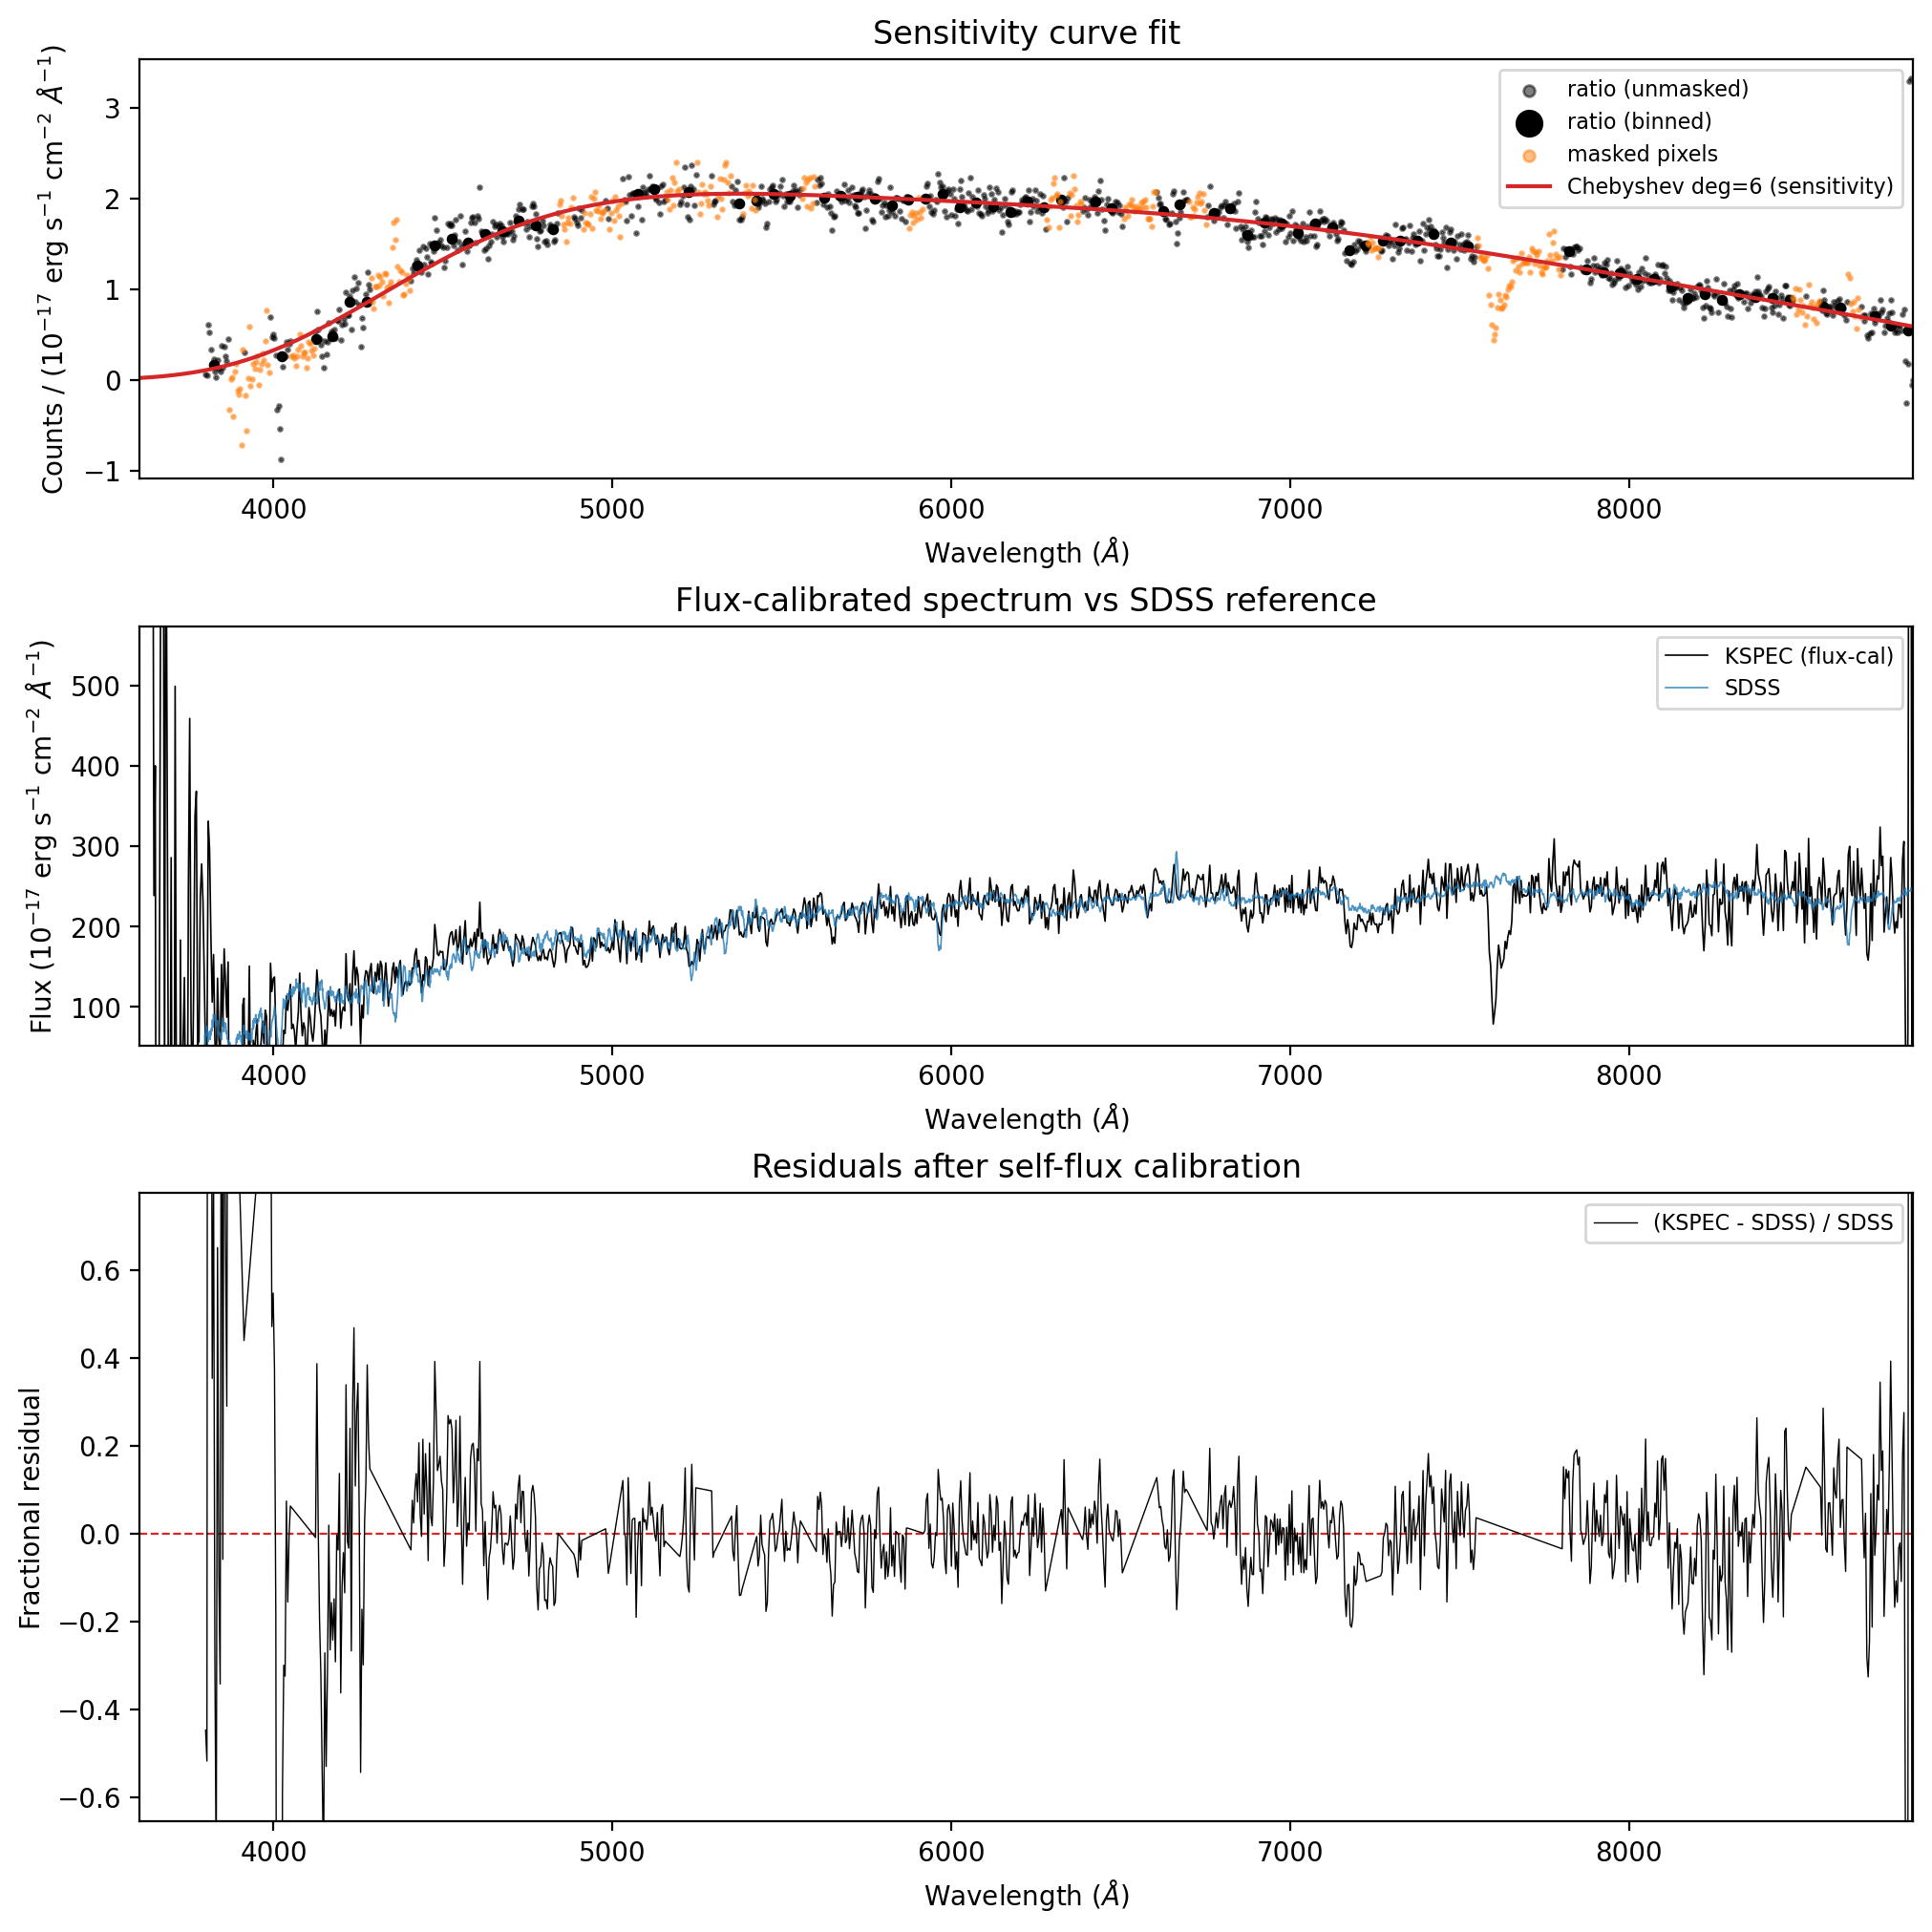

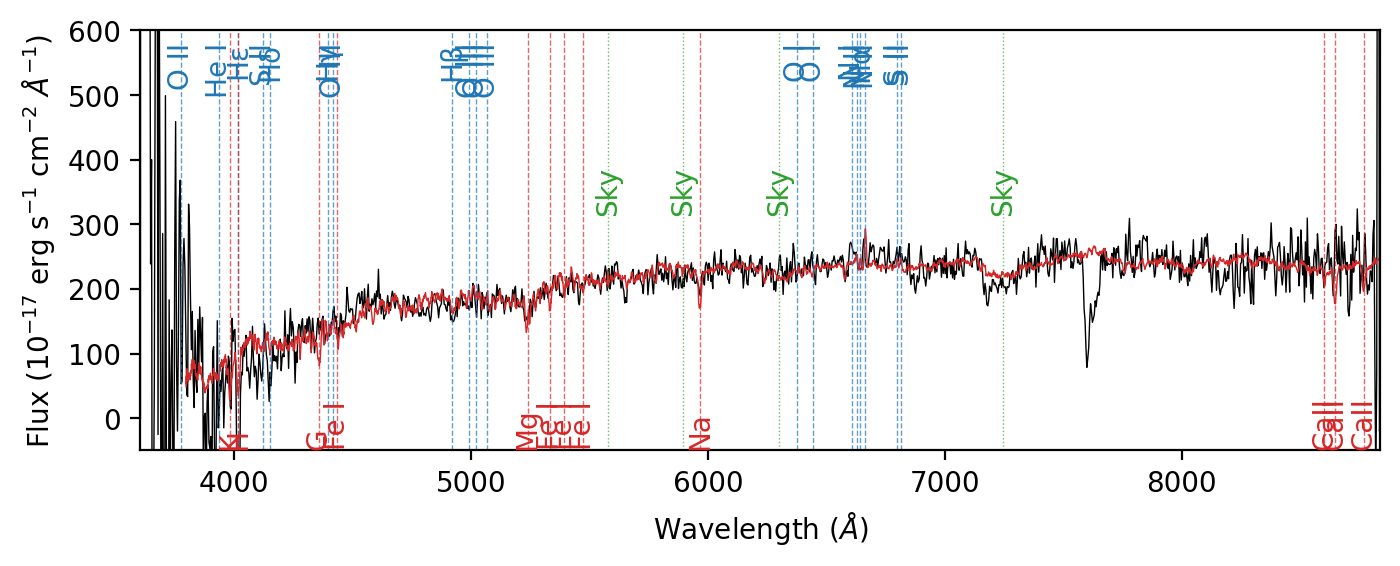

In [142]:
# ── Self-flux calibration using SDSS spectrum ──────────────────────────────
# Strategy:
#   1. Interpolate SDSS flux onto the KSPEC wavelength grid
#   2. Build a line mask (emission + absorption + sky) to exclude from the fit
#   3. Fit a smooth Chebyshev polynomial to ratio = kspec_counts / sdss_flux
#      (Chebyshev avoids the edge-ringing / curl-away of splines)
#   4. Divide KSPEC spectrum by the polynomial → flux-calibrated spectrum

# ── (Re-)load data ──────────────────────────────────────────────────────────
with fits.open(job["red"]) as hdul:
    sky_sub    = hdul["PRIMARY"].data.astype(float)
    sky_sub_sig = np.sqrt(hdul["VARIANCE"].data.astype(float))
    rwss       = hdul["RWSS"].data.astype(float)
    rwss_sig   = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk     = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header

i = 3
target_z = 0.

# Sky-subtracted KSPEC spectrum (same as cell above)
skyline_window = np.where((wave > 5540) & (wave < 5620))[0]
popt_sky,  _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                         p0=[900, 5578, 5, 0, 300])
popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                         p0=[900, 5578, 5, 0, 100])
sky_sub_again     = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]
sky_sub_again_sig = np.sqrt(rwss_sig[i]**2 + (popt_rwss[0] / popt_sky[0] * sky_sk_sig)**2)

# ── SDSS reference ──────────────────────────────────────────────────────────
sdss_hdul = fits.open(TESTDIR / "spec-0565-52225-0152.fits")
sdss_spec  = Table(sdss_hdul["COADD"].data)
sdss_wave  = 10**(sdss_spec["loglam"])
sdss_flux  = sdss_spec["flux"]          # units: 10^{-17} erg/s/cm^2/Å

# Interpolate SDSS onto KSPEC grid (only within SDSS coverage)
sdss_interp = np.interp(wave, sdss_wave, sdss_flux, left=np.nan, right=np.nan)

# ── Line mask ───────────────────────────────────────────────────────────────
MASK_WIDTH_EMISSION = 20.   # Å
MASK_WIDTH_ABSORB   = 20.   # Å
MASK_WIDTH_SKY      = 20.   # Å

emission_lines = [
    3729.875, 3889.0, 3970.1, 4072.3, 4102.89, 4341.68, 4364.436,
    4862.68,  4932.603, 4960.295, 5008.240, 6302.046, 6365.536,
    6529.03,  6549.86, 6564.61, 6585.27, 6718.29, 6732.67,
]
absorption_lines = [
    3934.777, 3969.588, 4305.61, 5176.7, 5895.6,
    8500.36, 8544.44, 8664.52, 4383., 5270., 5328., 5406.,
]
sky_lines = [5578.5, 5894.6, 6301.7, 7246.0]

mask = np.zeros(len(wave), dtype=bool)
for wl in emission_lines:
    mask |= np.abs(wave - wl * (1 + target_z)) < MASK_WIDTH_EMISSION
for wl in absorption_lines:
    mask |= np.abs(wave - wl * (1 + target_z)) < MASK_WIDTH_ABSORB
for wl in sky_lines:
    mask |= np.abs(wave - wl) < MASK_WIDTH_SKY
    
mask |= (wave > 7550) & (wave < 7800)

bad = (~np.isfinite(sdss_interp)) | (sdss_interp <= 0) | (~np.isfinite(sky_sub_again))
mask |= bad
fit_mask = ~mask

# ── Compute ratio and fit Chebyshev polynomial sensitivity curve ────────────
ratio = sky_sub_again / sdss_interp          # counts / (1e-17 erg/s/cm^2/Å)

# Weights from KSPEC noise propagated through the ratio
weights = 1.0 / (sky_sub_again_sig[fit_mask] / sdss_interp[fit_mask] + 1e-10)

CHEB_DEG = 6   # polynomial degree – increase for more flexibility

# cheb_fit = np.polynomial.chebyshev.Chebyshev.fit(
#     wave[fit_mask], ratio[fit_mask],
#     deg=CHEB_DEG,
#     w=weights,
# )
# sensitivity = cheb_fit(wave)
# Additional edge masking
# EDGE_CLIP = 150.0
# EDGE_CLIP = 1.0
# edge_bad = (wave < wave.min() + EDGE_CLIP) | (wave > wave.max() - EDGE_CLIP)
# mask |= edge_bad
# fit_mask = ~mask

ratio = sky_sub_again / sdss_interp

# Bin the ratio to suppress pixel-scale noise
bins = np.arange(wave[fit_mask].min(), wave[fit_mask].max() + 50.0, 50.0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ratio_binned = np.full(len(bin_centers), np.nan)
weight_binned = np.full(len(bin_centers), np.nan)

for j in range(len(bin_centers)):
    inbin = (wave >= bins[j]) & (wave < bins[j+1]) & fit_mask & np.isfinite(ratio)
    if np.sum(inbin) > 5:
        ratio_binned[j] = np.nanmedian(ratio[inbin])
        # robust-ish bin weight
        sig_bin = np.nanmedian(sky_sub_again_sig[inbin] / sdss_interp[inbin])
        weight_binned[j] = 1.0 / max(sig_bin, 1e-10)

good_bin = np.isfinite(ratio_binned) & np.isfinite(weight_binned) & (ratio_binned > 0)

# Fit in log space
cheb_log_fit = np.polynomial.chebyshev.Chebyshev.fit(
    bin_centers[good_bin],
    np.log(ratio_binned[good_bin]),
    deg=CHEB_DEG,
    w=np.clip(weight_binned[good_bin],
              np.nanpercentile(weight_binned[good_bin], 5),
              np.nanpercentile(weight_binned[good_bin], 95))
)

sensitivity = np.empty_like(wave)
xfit = bin_centers[good_bin]
# inside = (wave >= xfit.min()) & (wave <= xfit.max())
# sensitivity[inside] = np.exp(cheb_log_fit(wave[inside]))
# sensitivity[wave < xfit.min()] = np.exp(cheb_log_fit(xfit.min()))
# sensitivity[wave > xfit.max()] = np.exp(cheb_log_fit(xfit.max()))
sensitivity = np.exp(cheb_log_fit(wave))

# ── Apply calibration ───────────────────────────────────────────────────────
flux_cal     = sky_sub_again / sensitivity
flux_cal_sig = sky_sub_again_sig / sensitivity

# ── Diagnostic plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 2, 3]})

# Panel 1: ratio + Chebyshev fit
ax = axes[0]
ax.scatter(wave[fit_mask], ratio[fit_mask], s=2, c="k", alpha=0.5, label="ratio (unmasked)")
ax.scatter(bin_centers[good_bin], ratio_binned[good_bin], s=10, c="k", alpha=1, label="ratio (binned)")
ax.scatter(wave[mask & ~bad], ratio[mask & ~bad], s=2, c="tab:orange", alpha=0.5, label="masked pixels")
ax.plot(wave, sensitivity, color="tab:red", lw=1.5, label=f"Chebyshev deg={CHEB_DEG} (sensitivity)")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Counts / (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_title("Sensitivity curve fit")
ax.legend(fontsize=8, markerscale=3)
ax.set_xlim(wave[0], wave[-1])

# Panel 2: KSPEC flux-cal vs SDSS
ax = axes[1]
ax.plot(wave, flux_cal, lw=0.6, color="k", label="KSPEC (flux-cal)")
ax.plot(sdss_wave, sdss_flux, lw=0.6, color="tab:blue", alpha=0.8, label="SDSS")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ax.set_title("Flux-calibrated spectrum vs SDSS reference")
ylo, yhi = np.nanpercentile(flux_cal[fit_mask], [1, 99])
ax.set_ylim(ylo * 1.5, yhi * 2.0)
ax.set_xlim(wave[0], wave[-1])
ax.legend(fontsize=8)

# Panel 3: residuals (KSPEC - SDSS) / SDSS
ax = axes[2]
residual = (flux_cal - sdss_interp) / sdss_interp
ax.axhline(0, color="tab:red", lw=0.8, ls="--")
ax.plot(wave[fit_mask], residual[fit_mask], lw=0.5, color="k", label="(KSPEC - SDSS) / SDSS")
rlo, rhi = np.nanpercentile(residual[fit_mask], [2, 98])
ax.set_ylim(rlo * 2, rhi * 2)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fractional residual")
ax.set_title("Residuals after self-flux calibration")
ax.set_xlim(wave[0], wave[-1])
ax.legend(fontsize=8)

print(f"Median |fractional residual| (unmasked): {np.nanmedian(np.abs(residual[fit_mask])):.3f}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(2, 1, 1)
ax.plot(wave, flux_cal, lw=0.5, color="k")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 99) * 1.5
ax.plot(sdss_wave, sdss_flux, color="tab:red", lw=0.5)
ax.set_ylim(-50, 600)




# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])


target_z = 0.012055

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    wave_l_obs = wave_l * (1 + target_z)
    if wave_l_obs > wave[0] and wave_l_obs < wave[-1]:
        ax.axvline(wave_l_obs, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l_obs, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")
